# 201 — TCGA RNA-seq Quality Control

## Objective

Perform file-level quality control of the TCGA primary-tumor RNA-seq candidate files retained by notebook 200 and construct a reproducible raw `unstranded` count matrix for downstream paired-cohort selection and multi-omic integration.

This notebook evaluates RNA-seq files independently of methylation measurements. It preserves the cross-modality eligibility context established in notebook 200 but does not select the definitive RNA-seq–methylation pair for each case.

## Authoritative input cohort

The authoritative cohort input is:

`data/interim/metadata/tcga_primary_tumor_rnaseq_methylation_eligible_pair_inventory.csv`

The inventory contains 10,162 eligible candidate pairs representing 10,122 unique RNA-seq files.

Candidate-pair rows are not independent RNA-seq observations. Before molecular data are loaded, the inventory will therefore be reduced to one provenance-preserving record per unique `rna_file_id`.

Only RNA-seq files retained by the metadata-level eligibility policy defined in notebook 200 are evaluated.

## Quality-control unit

The quality-control unit is the individual GDC STAR Counts file.

Project, case, sample, portion, aliquot, and file identifiers are retained throughout the analysis. QC results are assigned at the file level and may subsequently support resolution of RNA-seq file multiplicity within the same biospecimen unit.

This notebook does not choose among distinct samples or portions belonging to the same case. Those decisions require joint consideration of RNA-seq and methylation QC and remain the responsibility of notebook 203.

## Expression representation

The `unstranded` STAR Counts column is the canonical raw expression representation.

The analysis will:

- preserve the original GDC gene identifiers and annotations;
- distinguish gene-level rows from STAR counting-summary rows;
- use counting-summary rows for file-level QC where appropriate;
- exclude non-gene summary rows from the biological count matrix;
- verify feature-order and annotation consistency across all 10,122 candidate files;
- establish a deterministic gene index without silently collapsing ambiguous identifiers; and
- construct a raw integer-count matrix containing one column per unique candidate RNA-seq file.

TPM, FPKM, and FPKM-UQ are not used as the primary expression representation.

The on-disk matrix format will be selected after evaluating the observed feature count, sparsity, and memory requirements. A wide CSV representation will not be used for the complete matrix.

## Filtering and normalization boundary

This notebook will define the gene-identification, abundance-filtering, and normalization policies required for downstream analysis.

However, operations whose estimates depend on cohort composition will not be fitted to the complete candidate-file inventory.

Accordingly:

- structural feature filtering may be applied in this notebook;
- raw counts will be retained for all 10,122 RNA-seq candidates, including the 3 files declared ineligible after QC, for traceability;
- abundance-based gene filtering rules will be defined but not fitted to the candidate cohort;
- cohort-dependent normalization factors will not be estimated from the candidate cohort; and
- the final filtered and normalized expression matrix will be generated only after notebook 203 has selected the definitive paired cohort.

This prevents RNA-seq files that are later discarded during cross-modality selection from influencing the final feature space or normalization parameters.

## Quality-control strategy

File-level assessment will include:

- local file availability and readability;
- expected STAR Counts schema;
- presence and validity of the `unstranded` column;
- completeness and consistency of gene annotations;
- non-negative integer count validation;
- assigned and unassigned read-count summaries;
- library-size and detected-feature metrics;
- zero-count and count-distribution diagnostics;
- project-aware identification of technically unusual files; and
- explicit separation of hard structural failures from statistical outlier flags.

Statistical outliers will not be excluded solely because they differ from the pooled pan-cancer distribution. Tumor lineage and project structure will be considered before any exclusion policy is applied.

Download integrity and MD5 validation were completed during Phase 1 and will not be repeated here.

## Scope

This notebook will:

- validate the eligible-pair inventory required from notebook 200;
- derive the unique RNA-seq file inventory for all 10,122 candidates, with 10,119 files eligible and 3 files ineligible after QC;
- resolve local paths to the corresponding STAR Counts payloads;
- inspect and validate the molecular file structure;
- construct a canonical gene-feature index;
- calculate file-level QC metrics and flags;
- provide RNA-seq QC evidence for resolving file-level multiplicity;
- construct the candidate-scope raw `unstranded` count matrix; and
- write only artifacts required by notebook 203 or later analyses.

This notebook will not:

- re-audit GDC download integrity;
- analyze methylation beta values;
- select a definitive sample or portion for each case;
- select the final RNA-seq–methylation pair;
- fit cohort-dependent normalization parameters;
- apply abundance-based filtering to define the final gene space;
- perform batch correction or confounder adjustment;
- integrate RNA-seq with methylation;
- discover biological programs; or
- infer causal or clinical relationships.

## Expected downstream-consumable outputs

After the molecular structure and storage requirements have been verified, this notebook will write:

- a unique RNA-seq file inventory for all 10,122 candidates with QC metrics, retained provenance, and `rna_qc_eligible_for_downstream_selection` as the downstream gate for the 10,119 eligible and 3 ineligible files;
- a deterministic gene-feature index;
- the raw candidate-scope `unstranded` count matrix with explicit row and column mappings; and
- any file-level resolution fields required for final paired-cohort selection in notebook 203.

Exploratory distributions and QC summaries will remain within the notebook unless they are required by a downstream computational step.

## 1. Inputs, paths, and candidate-file inventory


In [1]:
# =============================================================================
# Imports, repository bootstrap, and project paths
# =============================================================================

import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd


# -----------------------------------------------------------------------------
# Bootstrap repository imports
# -----------------------------------------------------------------------------

bootstrap_root = Path.cwd().resolve()

while not (
    (bootstrap_root / "src").is_dir()
    and (bootstrap_root / "config").is_dir()
):
    if bootstrap_root == bootstrap_root.parent:
        raise RuntimeError(
            "Could not locate the pancancer-epigenetics repository root."
        )
    bootstrap_root = bootstrap_root.parent

if str(bootstrap_root) not in sys.path:
    sys.path.insert(0, str(bootstrap_root))


# -----------------------------------------------------------------------------
# Project utilities
# -----------------------------------------------------------------------------

from src.utils.paths import Paths, project_relative_path
from src.utils.file_checks import calculate_sha256


# -----------------------------------------------------------------------------
# Canonical project root
# -----------------------------------------------------------------------------

PROJECT_ROOT = Paths.root


# -----------------------------------------------------------------------------
# Authoritative cohort input
# -----------------------------------------------------------------------------

ELIGIBLE_PAIR_INVENTORY_PATH = (
    Paths.metadata
    / "tcga_primary_tumor_rnaseq_methylation_eligible_pair_inventory.csv"
)


# -----------------------------------------------------------------------------
# Local TCGA RNA-seq payload directory
# -----------------------------------------------------------------------------

RNA_STAR_COUNTS_DIR = (
    Paths.tcga
    / "star_counts"
)


# -----------------------------------------------------------------------------
# Downstream output locations
# -----------------------------------------------------------------------------

RNA_QC_OUTPUT_DIR = Paths.qc
RNA_EXPRESSION_OUTPUT_DIR = Paths.expression
RNA_METADATA_OUTPUT_DIR = Paths.metadata


# -----------------------------------------------------------------------------
# Path summary
# -----------------------------------------------------------------------------

print("TCGA RNA-seq quality-control paths resolved.")
print(
    f"Project root:                "
    f"{project_relative_path(PROJECT_ROOT)}"
)
print(
    f"Eligible-pair inventory:     "
    f"{project_relative_path(ELIGIBLE_PAIR_INVENTORY_PATH)}"
)
print(
    f"STAR Counts directory:       "
    f"{project_relative_path(RNA_STAR_COUNTS_DIR)}"
)
print(
    f"QC output directory:         "
    f"{project_relative_path(RNA_QC_OUTPUT_DIR)}"
)
print(
    f"Expression output directory: "
    f"{project_relative_path(RNA_EXPRESSION_OUTPUT_DIR)}"
)
print(
    f"Metadata output directory:   "
    f"{project_relative_path(RNA_METADATA_OUTPUT_DIR)}"
)

TCGA RNA-seq quality-control paths resolved.
Project root:                .
Eligible-pair inventory:     data/interim/metadata/tcga_primary_tumor_rnaseq_methylation_eligible_pair_inventory.csv
STAR Counts directory:       data/raw/tcga/star_counts
QC output directory:         data/interim/qc
Expression output directory: data/interim/expression
Metadata output directory:   data/interim/metadata


In [2]:
# =============================================================================
# Validate authoritative inputs and load the eligible-pair inventory
# =============================================================================

# -----------------------------------------------------------------------------
# Validate required input locations
# -----------------------------------------------------------------------------

input_checks = {
    "eligible_pair_inventory_is_file": (
        ELIGIBLE_PAIR_INVENTORY_PATH.is_file()
    ),
    "star_counts_directory_is_dir": (
        RNA_STAR_COUNTS_DIR.is_dir()
    ),
}

print("Required-input checks:")
for check_name, check_passed in input_checks.items():
    print(f"{check_name}: {check_passed}")

if not all(input_checks.values()):
    failed_inputs = [
        check_name
        for check_name, check_passed in input_checks.items()
        if not check_passed
    ]
    raise FileNotFoundError(
        "Required TCGA RNA-seq input locations are unavailable: "
        + ", ".join(failed_inputs)
    )


# -----------------------------------------------------------------------------
# Load the authoritative eligible-pair inventory
# -----------------------------------------------------------------------------

eligible_pair_inventory = pd.read_csv(
    ELIGIBLE_PAIR_INVENTORY_PATH,
    dtype="string",
    low_memory=False,
)


# -----------------------------------------------------------------------------
# Validate the expected inventory schema
# -----------------------------------------------------------------------------

required_columns = {
    "project_id",
    "case_submitter_id",
    "rna_case_uuid",
    "rna_aliquot_uuid",
    "rna_file_id",
    "rna_file_name",
    "methylation_case_uuid",
    "methylation_file_id",
    "methylation_file_name",
    "same_biospecimen_portion",
    "primary_pair_policy_status",
}

missing_required_columns = sorted(
    required_columns.difference(eligible_pair_inventory.columns)
)

if missing_required_columns:
    raise ValueError(
        "The eligible-pair inventory is missing required columns: "
        + ", ".join(missing_required_columns)
    )




Required-input checks:
eligible_pair_inventory_is_file: True
star_counts_directory_is_dir: True


In [3]:
# -----------------------------------------------------------------------------
# Validate the frozen notebook-200 cohort counts
# -----------------------------------------------------------------------------

EXPECTED_PAIR_ROWS = 10_162
EXPECTED_CASES = 9_973
EXPECTED_RNA_FILES = 10_122
EXPECTED_METHYLATION_FILES = 10_038

required_identifier_columns = [
    "project_id",
    "case_submitter_id",
    "rna_case_uuid",
    "rna_file_id",
    "rna_file_name",
    "methylation_case_uuid",
    "methylation_file_id",
    "methylation_file_name",
]

inventory_checks = {
    "inventory_is_not_empty": (
        not eligible_pair_inventory.empty
    ),
    "column_names_are_unique": (
        not eligible_pair_inventory.columns.duplicated().any()
    ),
    "required_identifiers_are_complete": (
        eligible_pair_inventory[
            required_identifier_columns
        ]
        .notna()
        .all()
        .all()
    ),
    "rna_and_methylation_case_uuids_match": (
        eligible_pair_inventory["rna_case_uuid"]
        .eq(eligible_pair_inventory["methylation_case_uuid"])
        .all()
    ),
    "candidate_file_pairs_are_unique": (
        not eligible_pair_inventory.duplicated(
            subset=["rna_file_id", "methylation_file_id"]
        ).any()
    ),
    "pair_count_matches_notebook_200": (
        len(eligible_pair_inventory) == EXPECTED_PAIR_ROWS
    ),
    "case_count_matches_notebook_200": (
        eligible_pair_inventory["case_submitter_id"].nunique()
        == EXPECTED_CASES
    ),
    "rna_case_uuid_count_matches_case_count": (
        eligible_pair_inventory["rna_case_uuid"].nunique()
        == EXPECTED_CASES
    ),
    "methylation_case_uuid_count_matches_case_count": (
        eligible_pair_inventory["methylation_case_uuid"].nunique()
        == EXPECTED_CASES
    ),
    "rna_file_count_matches_notebook_200": (
        eligible_pair_inventory["rna_file_id"].nunique()
        == EXPECTED_RNA_FILES
    ),
    "methylation_file_count_matches_notebook_200": (
        eligible_pair_inventory["methylation_file_id"].nunique()
        == EXPECTED_METHYLATION_FILES
    ),
}

print("\nEligible-pair inventory checks:")
for check_name, check_passed in inventory_checks.items():
    print(f"{check_name}: {check_passed}")

if not all(inventory_checks.values()):
    failed_checks = [
        check_name
        for check_name, check_passed in inventory_checks.items()
        if not check_passed
    ]
    raise ValueError(
        "Eligible-pair inventory validation failed: "
        + ", ".join(failed_checks)
    )


# -----------------------------------------------------------------------------
# Inventory summary
# -----------------------------------------------------------------------------

print("\nEligible-pair inventory loaded.")
print(f"Shape:              {eligible_pair_inventory.shape}")
print(
    f"Cases:              "
    f"{eligible_pair_inventory['case_submitter_id'].nunique():,}"
)
print(f"Candidate pairs:    {len(eligible_pair_inventory):,}")
print(
    f"RNA-seq files:      "
    f"{eligible_pair_inventory['rna_file_id'].nunique():,}"
)
print(
    f"Methylation files:  "
    f"{eligible_pair_inventory['methylation_file_id'].nunique():,}"
)

print("\nPrimary-pair policy status:")
print(
    eligible_pair_inventory["primary_pair_policy_status"]
    .value_counts(dropna=False)
    .rename_axis("primary_pair_policy_status")
    .reset_index(name="candidate_pairs")
    .to_string(index=False)
)

print("\nInventory columns:")
for column_name in eligible_pair_inventory.columns:
    print(f"  - {column_name}")


Eligible-pair inventory checks:
inventory_is_not_empty: True
column_names_are_unique: True
required_identifiers_are_complete: True
rna_and_methylation_case_uuids_match: True
candidate_file_pairs_are_unique: True
pair_count_matches_notebook_200: True
case_count_matches_notebook_200: True
rna_case_uuid_count_matches_case_count: True
methylation_case_uuid_count_matches_case_count: True
rna_file_count_matches_notebook_200: True
methylation_file_count_matches_notebook_200: True

Eligible-pair inventory loaded.
Shape:              (10162, 38)
Cases:              9,973
Candidate pairs:    10,162
RNA-seq files:      10,122
Methylation files:  10,038

Primary-pair policy status:
                    primary_pair_policy_status  candidate_pairs
eligible_after_biospecimen_and_platform_policy            10162

Inventory columns:
  - project_id
  - case_submitter_id
  - sample_submitter_id
  - rna_case_uuid
  - rna_aliquot_uuid
  - rna_aliquot_submitter_id
  - rna_file_id
  - rna_file_name
  - methy

In [4]:
# =============================================================================
# Derive the unique eligible RNA-seq file inventory
# =============================================================================

# -----------------------------------------------------------------------------
# Define RNA-seq provenance fields
# -----------------------------------------------------------------------------

rna_provenance_columns = [
    "project_id",
    "case_submitter_id",
    "sample_submitter_id",
    "rna_case_uuid",
    "rna_aliquot_uuid",
    "rna_aliquot_submitter_id",
    "rna_file_id",
    "rna_file_name",
    "rna_project",
    "rna_tss",
    "rna_participant",
    "rna_sample_type_code",
    "rna_vial",
    "rna_portion_number",
    "rna_analyte_code",
    "rna_plate",
    "rna_center_code",
    "rna_sample_submitter_id_from_aliquot",
]

missing_rna_provenance_columns = sorted(
    set(rna_provenance_columns).difference(
        eligible_pair_inventory.columns
    )
)

if missing_rna_provenance_columns:
    raise ValueError(
        "The eligible-pair inventory is missing RNA-seq provenance columns: "
        + ", ".join(missing_rna_provenance_columns)
    )


# -----------------------------------------------------------------------------
# Verify that repeated RNA-seq files retain identical RNA provenance
# -----------------------------------------------------------------------------

rna_provenance_cardinality = (
    eligible_pair_inventory
    .groupby("rna_file_id", sort=False)[
        [
            column
            for column in rna_provenance_columns
            if column != "rna_file_id"
        ]
    ]
    .nunique(dropna=False)
)

inconsistent_rna_provenance = (
    rna_provenance_cardinality.gt(1).any(axis=1)
)

rna_provenance_is_invariant = (
    not inconsistent_rna_provenance.any()
)

print("RNA-seq provenance consistency:")
print(
    "rna_provenance_is_invariant_within_file: "
    f"{rna_provenance_is_invariant}"
)

if not rna_provenance_is_invariant:
    inconsistent_file_ids = (
        inconsistent_rna_provenance[
            inconsistent_rna_provenance
        ]
        .index
        .tolist()
    )

    raise ValueError(
        "Contradictory RNA-seq provenance was found for "
        f"{len(inconsistent_file_ids):,} rna_file_id values. "
        "Example file IDs: "
        + ", ".join(inconsistent_file_ids[:10])
    )




RNA-seq provenance consistency:
rna_provenance_is_invariant_within_file: True


In [5]:
# -----------------------------------------------------------------------------
# Reduce pair-level rows to one row per unique RNA-seq file
# -----------------------------------------------------------------------------

unique_rna_inventory = (
    eligible_pair_inventory[rna_provenance_columns]
    .drop_duplicates(subset="rna_file_id", keep="first")
    .copy()
)


# -----------------------------------------------------------------------------
# Retain compact cross-modality eligibility context
# -----------------------------------------------------------------------------

rna_pair_context = (
    eligible_pair_inventory
    .groupby("rna_file_id", sort=False)
    .agg(
        eligible_pair_count=(
            "methylation_file_id",
            "size",
        ),
        eligible_methylation_file_count=(
            "methylation_file_id",
            "nunique",
        ),
        eligible_methylation_platform_count=(
            "methylation_platform",
            "nunique",
        ),
    )
    .reset_index()
)

unique_rna_inventory = unique_rna_inventory.merge(
    rna_pair_context,
    on="rna_file_id",
    how="left",
    validate="one_to_one",
)

unique_rna_inventory = (
    unique_rna_inventory
    .sort_values(
        [
            "project_id",
            "case_submitter_id",
            "sample_submitter_id",
            "rna_aliquot_submitter_id",
            "rna_file_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)


# -----------------------------------------------------------------------------
# Resolve expected local payload paths
# -----------------------------------------------------------------------------

rna_file_directories = [
    RNA_STAR_COUNTS_DIR / file_id
    for file_id in unique_rna_inventory["rna_file_id"]
]

rna_payload_paths = [
    directory / file_name
    for directory, file_name in zip(
        rna_file_directories,
        unique_rna_inventory["rna_file_name"],
    )
]

unique_rna_inventory["rna_local_path"] = pd.Series(
    [
        project_relative_path(payload_path)
        for payload_path in rna_payload_paths
    ],
    dtype="string",
)

unique_rna_inventory["rna_directory_exists"] = [
    directory.is_dir()
    for directory in rna_file_directories
]

unique_rna_inventory["rna_payload_exists"] = [
    payload_path.is_file()
    for payload_path in rna_payload_paths
]




In [6]:
# -----------------------------------------------------------------------------
# Validate the unique RNA-seq inventory
# -----------------------------------------------------------------------------

unique_rna_inventory_checks = {
    "unique_rna_inventory_is_not_empty": (
        not unique_rna_inventory.empty
    ),
    "one_row_per_rna_file_id": (
        unique_rna_inventory["rna_file_id"].is_unique
    ),
    "rna_file_count_matches_notebook_200": (
        len(unique_rna_inventory) == EXPECTED_RNA_FILES
    ),
    "case_count_matches_notebook_200": (
        unique_rna_inventory["case_submitter_id"].nunique()
        == EXPECTED_CASES
    ),
    "all_rna_files_have_eligible_pairs": (
        unique_rna_inventory["eligible_pair_count"].ge(1).all()
    ),
    "eligible_pair_count_reconstructs_pair_inventory": (
        unique_rna_inventory["eligible_pair_count"].sum()
        == EXPECTED_PAIR_ROWS
    ),
    "local_payload_paths_are_unique": (
        unique_rna_inventory["rna_local_path"].is_unique
    ),
    "all_expected_file_directories_exist": (
        unique_rna_inventory["rna_directory_exists"].all()
    ),
    "all_expected_payload_files_exist": (
        unique_rna_inventory["rna_payload_exists"].all()
    ),
}

print("\nUnique RNA-seq inventory checks:")
for check_name, check_passed in unique_rna_inventory_checks.items():
    print(f"{check_name}: {check_passed}")

if not all(unique_rna_inventory_checks.values()):
    failed_checks = [
        check_name
        for check_name, check_passed
        in unique_rna_inventory_checks.items()
        if not check_passed
    ]

    missing_payload_examples = (
        unique_rna_inventory.loc[
            ~unique_rna_inventory["rna_payload_exists"],
            "rna_local_path",
        ]
        .head(10)
        .tolist()
    )

    error_message = (
        "Unique RNA-seq inventory validation failed: "
        + ", ".join(failed_checks)
    )

    if missing_payload_examples:
        error_message += (
            ". Missing payload examples: "
            + ", ".join(missing_payload_examples)
        )

    raise ValueError(error_message)


# -----------------------------------------------------------------------------
# Inventory summary
# -----------------------------------------------------------------------------

print("\nUnique eligible RNA-seq inventory derived.")
print(f"Shape:             {unique_rna_inventory.shape}")
print(
    f"Cases:             "
    f"{unique_rna_inventory['case_submitter_id'].nunique():,}"
)
print(f"RNA-seq files:     {len(unique_rna_inventory):,}")
print(
    f"Local payloads:    "
    f"{unique_rna_inventory['rna_payload_exists'].sum():,}"
)

print("\nEligible methylation partners per RNA-seq file:")
print(
    unique_rna_inventory["eligible_methylation_file_count"]
    .value_counts()
    .sort_index()
    .rename_axis("eligible_methylation_files")
    .reset_index(name="rna_files")
    .to_string(index=False)
)

print("\nEligible RNA-seq files per project:")
print(
    unique_rna_inventory
    .groupby("project_id", as_index=False)
    .agg(
        cases=("case_submitter_id", "nunique"),
        rna_files=("rna_file_id", "nunique"),
    )
    .sort_values("project_id")
    .to_string(index=False)
)



Unique RNA-seq inventory checks:
unique_rna_inventory_is_not_empty: True
one_row_per_rna_file_id: True
rna_file_count_matches_notebook_200: True
case_count_matches_notebook_200: True
all_rna_files_have_eligible_pairs: True
eligible_pair_count_reconstructs_pair_inventory: True
local_payload_paths_are_unique: True
all_expected_file_directories_exist: True
all_expected_payload_files_exist: True

Unique eligible RNA-seq inventory derived.
Shape:             (10122, 24)
Cases:             9,973
RNA-seq files:     10,122
Local payloads:    10,122

Eligible methylation partners per RNA-seq file:
 eligible_methylation_files  rna_files
                          1      10082
                          2         40

Eligible RNA-seq files per project:
project_id  cases  rna_files
  TCGA-ACC     79         79
 TCGA-BLCA    406        412
 TCGA-BRCA   1091       1103
 TCGA-CESC    304        304
 TCGA-CHOL     35         35
 TCGA-COAD    453        475
 TCGA-DLBC     48         48
 TCGA-ESCA    184

## 2. STAR Counts schema and matrix storage plan


In [7]:
# =============================================================================
# Inspect the structure of a representative STAR Counts file
# =============================================================================

# -----------------------------------------------------------------------------
# Select a deterministic reference file
# -----------------------------------------------------------------------------

reference_rna_record = unique_rna_inventory.iloc[0]

reference_rna_path = (
    PROJECT_ROOT
    / Path(reference_rna_record["rna_local_path"])
)

if not reference_rna_path.is_file():
    raise FileNotFoundError(
        f"Reference STAR Counts file not found: {reference_rna_path}"
    )


# -----------------------------------------------------------------------------
# Read leading metadata comments
# -----------------------------------------------------------------------------

reference_comment_lines = []

with reference_rna_path.open(
    mode="r",
    encoding="utf-8",
) as file_handle:
    for raw_line in file_handle:
        stripped_line = raw_line.rstrip("\r\n")

        if stripped_line.startswith("#"):
            reference_comment_lines.append(stripped_line)
        elif stripped_line == "":
            continue
        else:
            break


# -----------------------------------------------------------------------------
# Load the complete reference file without coercing identifiers
# -----------------------------------------------------------------------------

reference_star_counts = pd.read_csv(
    reference_rna_path,
    sep="\t",
    comment="#",
    dtype="string",
    low_memory=False,
)


# -----------------------------------------------------------------------------
# Validate the minimum schema required by notebook 201
# -----------------------------------------------------------------------------

required_star_columns = {
    "gene_id",
    "gene_name",
    "gene_type",
    "unstranded",
}

missing_star_columns = sorted(
    required_star_columns.difference(
        reference_star_counts.columns
    )
)

if missing_star_columns:
    raise ValueError(
        "The reference STAR Counts file is missing required columns: "
        + ", ".join(missing_star_columns)
    )




In [8]:
# -----------------------------------------------------------------------------
# Separate STAR summary rows from biological gene rows
# -----------------------------------------------------------------------------

reference_summary_mask = (
    reference_star_counts["gene_id"]
    .str.startswith("N_", na=False)
)

reference_summary_rows = (
    reference_star_counts.loc[reference_summary_mask]
    .copy()
)

reference_gene_rows = (
    reference_star_counts.loc[~reference_summary_mask]
    .copy()
)


# -----------------------------------------------------------------------------
# Validate the canonical unstranded count field
# -----------------------------------------------------------------------------

reference_unstranded_numeric = pd.to_numeric(
    reference_star_counts["unstranded"],
    errors="coerce",
)

reference_gene_counts = (
    reference_unstranded_numeric.loc[
        reference_gene_rows.index
    ]
)

reference_count_checks = {
    "unstranded_is_complete": (
        reference_unstranded_numeric.notna().all()
    ),
    "unstranded_is_non_negative": (
        reference_unstranded_numeric.ge(0).all()
    ),
    "unstranded_is_integer_valued": (
        reference_unstranded_numeric
        .dropna()
        .mod(1)
        .eq(0)
        .all()
    ),
    "gene_ids_are_complete": (
        reference_gene_rows["gene_id"].notna().all()
    ),
    "gene_ids_are_unique": (
        reference_gene_rows["gene_id"].is_unique
    ),
}


# -----------------------------------------------------------------------------
# Characterize gene identifiers and annotations
# -----------------------------------------------------------------------------

versioned_gene_id_mask = (
    reference_gene_rows["gene_id"]
    .str.contains(r"\.\d+$", regex=True, na=False)
)

gene_annotation_summary = {
    "gene_rows": len(reference_gene_rows),
    "unique_gene_ids": (
        reference_gene_rows["gene_id"].nunique()
    ),
    "versioned_gene_ids": (
        int(versioned_gene_id_mask.sum())
    ),
    "missing_gene_names": (
        int(reference_gene_rows["gene_name"].isna().sum())
    ),
    "missing_gene_types": (
        int(reference_gene_rows["gene_type"].isna().sum())
    ),
    "zero_count_genes": (
        int(reference_gene_counts.eq(0).sum())
    ),
    "detected_genes": (
        int(reference_gene_counts.gt(0).sum())
    ),
    "gene_count_sum": (
        int(reference_gene_counts.sum())
    ),
}




In [9]:
# -----------------------------------------------------------------------------
# Report the observed structure
# -----------------------------------------------------------------------------

print("Reference STAR Counts file selected.")
print(
    f"Project:          "
    f"{reference_rna_record['project_id']}"
)
print(
    f"Case:             "
    f"{reference_rna_record['case_submitter_id']}"
)
print(
    f"RNA file ID:      "
    f"{reference_rna_record['rna_file_id']}"
)
print(
    f"RNA file name:    "
    f"{reference_rna_record['rna_file_name']}"
)
print(
    f"Local path:       "
    f"{project_relative_path(reference_rna_path)}"
)
print(
    f"File size:        "
    f"{reference_rna_path.stat().st_size / (1024 ** 2):.3f} MiB"
)

print("\nLeading metadata comments:")
if reference_comment_lines:
    for comment_line in reference_comment_lines:
        print(f"  {comment_line}")
else:
    print("  None")

print("\nObserved table structure:")
print(f"Shape:             {reference_star_counts.shape}")
print(f"Summary rows:      {len(reference_summary_rows):,}")
print(f"Gene rows:         {len(reference_gene_rows):,}")

print("\nObserved columns:")
for column_name in reference_star_counts.columns:
    print(f"  - {column_name}")

print("\nReference-file count checks:")
for check_name, check_passed in reference_count_checks.items():
    print(f"{check_name}: {check_passed}")

if not all(reference_count_checks.values()):
    failed_checks = [
        check_name
        for check_name, check_passed
        in reference_count_checks.items()
        if not check_passed
    ]
    raise ValueError(
        "Reference STAR Counts validation failed: "
        + ", ".join(failed_checks)
    )

print("\nGene-feature summary:")
for metric_name, metric_value in gene_annotation_summary.items():
    print(f"{metric_name}: {metric_value:,}")

print("\nSTAR counting-summary rows:")
summary_display_columns = [
    column_name
    for column_name in [
        "gene_id",
        "unstranded",
        "stranded_first",
        "stranded_second",
    ]
    if column_name in reference_summary_rows.columns
]

print(
    reference_summary_rows[summary_display_columns]
    .to_string(index=False)
)

print("\nMost frequent gene types:")
print(
    reference_gene_rows["gene_type"]
    .value_counts(dropna=False)
    .head(15)
    .rename_axis("gene_type")
    .reset_index(name="genes")
    .to_string(index=False)
)

print("\nFirst biological gene rows:")
print(
    reference_gene_rows
    .head(5)
    .to_string(index=False)
)

Reference STAR Counts file selected.
Project:          TCGA-ACC
Case:             TCGA-OR-A5J1
RNA file ID:      fe16b2d3-17b0-4e24-ab31-62d2e951b3a2
RNA file name:    6bacf042-830f-47dd-bac3-5696aebf2574.rna_seq.augmented_star_gene_counts.tsv
Local path:       data/raw/tcga/star_counts/fe16b2d3-17b0-4e24-ab31-62d2e951b3a2/6bacf042-830f-47dd-bac3-5696aebf2574.rna_seq.augmented_star_gene_counts.tsv
File size:        4.030 MiB

Leading metadata comments:
  # gene-model: GENCODE v36

Observed table structure:
Shape:             (60664, 9)
Summary rows:      4
Gene rows:         60,660

Observed columns:
  - gene_id
  - gene_name
  - gene_type
  - unstranded
  - stranded_first
  - stranded_second
  - tpm_unstranded
  - fpkm_unstranded
  - fpkm_uq_unstranded

Reference-file count checks:
unstranded_is_complete: True
unstranded_is_non_negative: True
unstranded_is_integer_valued: True
gene_ids_are_complete: True
gene_ids_are_unique: True

Gene-feature summary:
gene_rows: 60,660
unique_gene_id

In [10]:
# =============================================================================
# Establish the canonical gene index and raw-matrix storage plan
# =============================================================================

import hashlib
import shutil


# -----------------------------------------------------------------------------
# Define the expected GDC STAR Counts structure
# -----------------------------------------------------------------------------

EXPECTED_GENE_MODEL_COMMENT = "# gene-model: GENCODE v36"

EXPECTED_STAR_COLUMNS = (
    "gene_id",
    "gene_name",
    "gene_type",
    "unstranded",
    "stranded_first",
    "stranded_second",
    "tpm_unstranded",
    "fpkm_unstranded",
    "fpkm_uq_unstranded",
)

EXPECTED_SUMMARY_GENE_IDS = (
    "N_unmapped",
    "N_multimapping",
    "N_noFeature",
    "N_ambiguous",
)

EXPECTED_GENE_FEATURES = 60_660


# -----------------------------------------------------------------------------
# Validate the reference structure against explicit expectations
# -----------------------------------------------------------------------------

observed_star_columns = tuple(reference_star_counts.columns)

observed_summary_gene_ids = tuple(
    reference_summary_rows["gene_id"].tolist()
)

reference_structure_checks = {
    "gene_model_comment_matches_gencode_v36": (
        reference_comment_lines == [EXPECTED_GENE_MODEL_COMMENT]
    ),
    "star_columns_match_expected_schema": (
        observed_star_columns == EXPECTED_STAR_COLUMNS
    ),
    "summary_rows_match_expected_order": (
        observed_summary_gene_ids == EXPECTED_SUMMARY_GENE_IDS
    ),
    "gene_feature_count_matches_expected": (
        len(reference_gene_rows) == EXPECTED_GENE_FEATURES
    ),
    "gene_ids_are_complete": (
        reference_gene_rows["gene_id"].notna().all()
    ),
    "gene_ids_are_unique": (
        reference_gene_rows["gene_id"].is_unique
    ),
    "gene_names_are_complete": (
        reference_gene_rows["gene_name"].notna().all()
    ),
    "gene_types_are_complete": (
        reference_gene_rows["gene_type"].notna().all()
    ),
}

print("Reference structural checks:")
for check_name, check_passed in reference_structure_checks.items():
    print(f"{check_name}: {check_passed}")

if not all(reference_structure_checks.values()):
    failed_checks = [
        check_name
        for check_name, check_passed
        in reference_structure_checks.items()
        if not check_passed
    ]

    raise ValueError(
        "The reference STAR Counts structure does not satisfy the "
        "canonical notebook-201 expectations: "
        + ", ".join(failed_checks)
    )




Reference structural checks:
gene_model_comment_matches_gencode_v36: True
star_columns_match_expected_schema: True
summary_rows_match_expected_order: True
gene_feature_count_matches_expected: True
gene_ids_are_complete: True
gene_ids_are_unique: True
gene_names_are_complete: True
gene_types_are_complete: True


In [11]:
# -----------------------------------------------------------------------------
# Construct the canonical gene-feature index
# -----------------------------------------------------------------------------

canonical_gene_feature_index = (
    reference_gene_rows[
        [
            "gene_id",
            "gene_name",
            "gene_type",
        ]
    ]
    .reset_index(drop=True)
    .copy()
)

canonical_gene_feature_index.insert(
    0,
    "matrix_row_index",
    np.arange(
        len(canonical_gene_feature_index),
        dtype=np.int64,
    ),
)

canonical_gene_feature_index["gene_id_base"] = (
    canonical_gene_feature_index["gene_id"]
    .str.replace(
        r"\.\d+$",
        "",
        regex=True,
    )
)

canonical_gene_feature_index["gene_id_is_versioned"] = (
    canonical_gene_feature_index["gene_id"]
    .str.contains(
        r"\.\d+$",
        regex=True,
        na=False,
    )
)


# -----------------------------------------------------------------------------
# Preserve canonical arrays for efficient file-by-file comparison
# -----------------------------------------------------------------------------

canonical_gene_ids = (
    canonical_gene_feature_index["gene_id"]
    .to_numpy(dtype=object)
)

canonical_gene_names = (
    canonical_gene_feature_index["gene_name"]
    .to_numpy(dtype=object)
)

canonical_gene_types = (
    canonical_gene_feature_index["gene_type"]
    .to_numpy(dtype=object)
)


# -----------------------------------------------------------------------------
# Calculate a deterministic feature-index signature
# -----------------------------------------------------------------------------

canonical_feature_signature_text = (
    canonical_gene_feature_index[
        [
            "gene_id",
            "gene_name",
            "gene_type",
        ]
    ]
    .to_csv(
        index=False,
        lineterminator="\n",
    )
)

CANONICAL_FEATURE_INDEX_SHA256 = hashlib.sha256(
    canonical_feature_signature_text.encode("utf-8")
).hexdigest()




In [12]:
# -----------------------------------------------------------------------------
# Characterize identifier multiplicity without collapsing features
# -----------------------------------------------------------------------------

base_gene_id_duplicate_mask = (
    canonical_gene_feature_index["gene_id_base"]
    .duplicated(keep=False)
)

gene_name_duplicate_mask = (
    canonical_gene_feature_index["gene_name"]
    .duplicated(keep=False)
)

identifier_summary = {
    "canonical_gene_features": (
        len(canonical_gene_feature_index)
    ),
    "versioned_gene_ids": (
        int(
            canonical_gene_feature_index[
                "gene_id_is_versioned"
            ].sum()
        )
    ),
    "unversioned_gene_ids": (
        int(
            (
                ~canonical_gene_feature_index[
                    "gene_id_is_versioned"
                ]
            ).sum()
        )
    ),
    "unique_base_gene_ids": (
        canonical_gene_feature_index["gene_id_base"].nunique()
    ),
    "features_in_base_id_collisions": (
        int(base_gene_id_duplicate_mask.sum())
    ),
    "unique_gene_names": (
        canonical_gene_feature_index["gene_name"].nunique()
    ),
    "features_with_duplicated_gene_names": (
        int(gene_name_duplicate_mask.sum())
    ),
}


# -----------------------------------------------------------------------------
# Define downstream-consumable output paths
# -----------------------------------------------------------------------------

RAW_COUNT_MATRIX_PATH = (
    RNA_EXPRESSION_OUTPUT_DIR
    / "tcga_primary_tumor_rnaseq_candidate_unstranded_raw_counts.npy"
)

RNA_GENE_FEATURE_INDEX_PATH = (
    RNA_EXPRESSION_OUTPUT_DIR
    / "tcga_primary_tumor_rnaseq_gene_feature_index.csv"
)

RNA_FILE_QC_INVENTORY_PATH = (
    RNA_QC_OUTPUT_DIR
    / "tcga_primary_tumor_rnaseq_file_qc_inventory.csv"
)

RNA_RAW_COUNTS_METADATA_PATH = (
    RNA_EXPRESSION_OUTPUT_DIR
    / "tcga_primary_tumor_rnaseq_candidate_unstranded_raw_counts_metadata.json"
)




In [13]:
# -----------------------------------------------------------------------------
# Define and validate the raw matrix representation
# -----------------------------------------------------------------------------

RAW_COUNT_DTYPE = np.dtype("uint32")

RAW_COUNT_MATRIX_SHAPE = (
    len(canonical_gene_feature_index),
    len(unique_rna_inventory),
)

RAW_COUNT_MATRIX_BYTES = (
    RAW_COUNT_MATRIX_SHAPE[0]
    * RAW_COUNT_MATRIX_SHAPE[1]
    * RAW_COUNT_DTYPE.itemsize
)

reference_max_gene_count = int(reference_gene_counts.max())

storage_probe_path = RNA_EXPRESSION_OUTPUT_DIR

while not storage_probe_path.exists():
    storage_probe_path = storage_probe_path.parent

available_storage_bytes = shutil.disk_usage(
    storage_probe_path
).free

storage_checks = {
    "reference_counts_fit_uint32": (
        reference_max_gene_count
        <= np.iinfo(RAW_COUNT_DTYPE).max
    ),
    "matrix_shape_matches_expected_dimensions": (
        RAW_COUNT_MATRIX_SHAPE
        == (EXPECTED_GENE_FEATURES, EXPECTED_RNA_FILES)
    ),
    "available_storage_exceeds_matrix_size": (
        available_storage_bytes
        > RAW_COUNT_MATRIX_BYTES
    ),
    "available_storage_includes_25_percent_margin": (
        available_storage_bytes
        > RAW_COUNT_MATRIX_BYTES * 1.25
    ),
}

print("\nCanonical gene-feature index:")
for metric_name, metric_value in identifier_summary.items():
    print(f"{metric_name}: {metric_value:,}")

print(
    "feature_index_sha256: "
    f"{CANONICAL_FEATURE_INDEX_SHA256}"
)

print("\nRaw count-matrix plan:")
print(
    f"Shape:              "
    f"{RAW_COUNT_MATRIX_SHAPE[0]:,} genes × "
    f"{RAW_COUNT_MATRIX_SHAPE[1]:,} RNA-seq files"
)
print(f"Data type:          {RAW_COUNT_DTYPE.name}")
print(
    f"Estimated size:     "
    f"{RAW_COUNT_MATRIX_BYTES / (1024 ** 3):.3f} GiB"
)
print(
    f"Available storage:  "
    f"{available_storage_bytes / (1024 ** 3):.3f} GiB"
)
print(
    f"Reference maximum:  "
    f"{reference_max_gene_count:,}"
)

print("\nStorage and representation checks:")
for check_name, check_passed in storage_checks.items():
    print(f"{check_name}: {check_passed}")

if not all(storage_checks.values()):
    failed_checks = [
        check_name
        for check_name, check_passed in storage_checks.items()
        if not check_passed
    ]

    raise RuntimeError(
        "Raw count-matrix preflight failed: "
        + ", ".join(failed_checks)
    )

print("\nPlanned downstream-consumable outputs:")
print(
    "Raw count matrix:    "
    f"{project_relative_path(RAW_COUNT_MATRIX_PATH)}"
)
print(
    "Gene-feature index:  "
    f"{project_relative_path(RNA_GENE_FEATURE_INDEX_PATH)}"
)
print(
    "File-QC inventory:   "
    f"{project_relative_path(RNA_FILE_QC_INVENTORY_PATH)}"
)
print(
    "Matrix metadata:     "
    f"{project_relative_path(RNA_RAW_COUNTS_METADATA_PATH)}"
)


Canonical gene-feature index:
canonical_gene_features: 60,660
versioned_gene_ids: 60,616
unversioned_gene_ids: 44
unique_base_gene_ids: 60,660
features_in_base_id_collisions: 0
unique_gene_names: 59,427
features_with_duplicated_gene_names: 1,343
feature_index_sha256: c13179f3155f1613a76927a0da7379ce144b442874f365e399cfa733e0af1066

Raw count-matrix plan:
Shape:              60,660 genes × 10,122 RNA-seq files
Data type:          uint32
Estimated size:     2.287 GiB
Available storage:  420.426 GiB
Reference maximum:  3,217,832

Storage and representation checks:
reference_counts_fit_uint32: True
matrix_shape_matches_expected_dimensions: True
available_storage_exceeds_matrix_size: True
available_storage_includes_25_percent_margin: True

Planned downstream-consumable outputs:
Raw count matrix:    data/interim/expression/tcga_primary_tumor_rnaseq_candidate_unstranded_raw_counts.npy
Gene-feature index:  data/interim/expression/tcga_primary_tumor_rnaseq_gene_feature_index.csv
File-QC invent

## 3. Candidate-file processing and transactional matrix publication


In [14]:
# =============================================================================
# Validate all candidate STAR Counts files and build the raw-count matrix
# =============================================================================

import json
import time
from datetime import datetime, timezone


# -----------------------------------------------------------------------------
# Create output directories
# -----------------------------------------------------------------------------

RNA_EXPRESSION_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

RNA_QC_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# -----------------------------------------------------------------------------
# Define temporary output paths
# -----------------------------------------------------------------------------

def make_inprogress_path(output_path):
    return output_path.with_name(
        f"{output_path.stem}.inprogress{output_path.suffix}"
    )


TEMP_RAW_COUNT_MATRIX_PATH = make_inprogress_path(
    RAW_COUNT_MATRIX_PATH
)

TEMP_GENE_FEATURE_INDEX_PATH = make_inprogress_path(
    RNA_GENE_FEATURE_INDEX_PATH
)

TEMP_FILE_QC_INVENTORY_PATH = make_inprogress_path(
    RNA_FILE_QC_INVENTORY_PATH
)

TEMP_RAW_COUNTS_METADATA_PATH = make_inprogress_path(
    RNA_RAW_COUNTS_METADATA_PATH
)

temporary_output_paths = [
    TEMP_RAW_COUNT_MATRIX_PATH,
    TEMP_GENE_FEATURE_INDEX_PATH,
    TEMP_FILE_QC_INVENTORY_PATH,
    TEMP_RAW_COUNTS_METADATA_PATH,
]

for temporary_path in temporary_output_paths:
    if temporary_path.exists():
        temporary_path.unlink()


# -----------------------------------------------------------------------------
# Define file-reading and hashing helpers
# -----------------------------------------------------------------------------

CORE_STAR_COLUMNS = (
    "gene_id",
    "gene_name",
    "gene_type",
    "unstranded",
)


def read_star_counts_core(file_path):
    """
    Read one STAR Counts file through a single file handle.

    The complete header is inspected, but only the four columns required for
    structural validation and raw-count extraction are materialized.
    """

    comment_lines = []
    header_line = None

    with file_path.open(
        mode="r",
        encoding="utf-8",
        newline="",
    ) as file_handle:

        for raw_line in file_handle:
            stripped_line = raw_line.rstrip("\r\n")

            if stripped_line.startswith("#"):
                comment_lines.append(stripped_line)
            elif stripped_line == "":
                continue
            else:
                header_line = stripped_line
                break

        if header_line is None:
            raise ValueError(
                "No tabular header was found."
            )

        observed_columns = tuple(
            header_line.split("\t")
        )

        if observed_columns != EXPECTED_STAR_COLUMNS:
            return (
                comment_lines,
                observed_columns,
                None,
            )

        core_table = pd.read_csv(
            file_handle,
            sep="\t",
            header=None,
            names=list(observed_columns),
            usecols=list(CORE_STAR_COLUMNS),
            dtype="string",
            keep_default_na=False,
            na_filter=False,
            low_memory=False,
        )

    return (
        comment_lines,
        observed_columns,
        core_table,
    )


# -----------------------------------------------------------------------------
# Initialize the disk-backed raw-count matrix
#
# The biological orientation remains genes × RNA-seq files. Fortran order
# makes each sample column contiguous, allowing efficient incremental writes.
# -----------------------------------------------------------------------------

raw_count_matrix = np.lib.format.open_memmap(
    TEMP_RAW_COUNT_MATRIX_PATH,
    mode="w+",
    dtype=RAW_COUNT_DTYPE,
    shape=RAW_COUNT_MATRIX_SHAPE,
    fortran_order=True,
)




In [15]:
# -----------------------------------------------------------------------------
# Validate every candidate STAR Counts file and populate the matrix
# -----------------------------------------------------------------------------

file_qc_records = []
failure_records = []

processing_started = time.perf_counter()
total_rna_files = len(unique_rna_inventory)

print("Mass STAR Counts processing started.")
print(f"RNA-seq files:      {total_rna_files:,}")
print(f"Gene features:      {EXPECTED_GENE_FEATURES:,}")
print(f"Matrix orientation: genes × RNA-seq files")
print(f"Matrix memory order: Fortran")
print()

for matrix_column_index, record in enumerate(
    unique_rna_inventory.itertuples(index=False)
):
    rna_file_id = str(record.rna_file_id)
    rna_local_path = str(record.rna_local_path)

    payload_path = (
        PROJECT_ROOT
        / Path(rna_local_path)
    )

    validation_issues = []

    try:
        (
            observed_comment_lines,
            observed_columns,
            star_core_table,
        ) = read_star_counts_core(payload_path)

        if observed_comment_lines != [
            EXPECTED_GENE_MODEL_COMMENT
        ]:
            validation_issues.append(
                "gene_model_comment_mismatch"
            )

        if observed_columns != EXPECTED_STAR_COLUMNS:
            validation_issues.append(
                "star_column_schema_mismatch"
            )

        if star_core_table is not None:
            expected_total_rows = (
                len(EXPECTED_SUMMARY_GENE_IDS)
                + EXPECTED_GENE_FEATURES
            )

            if len(star_core_table) != expected_total_rows:
                validation_issues.append(
                    "table_row_count_mismatch"
                )

            if len(star_core_table) == expected_total_rows:
                observed_summary_ids = tuple(
                    star_core_table["gene_id"]
                    .iloc[:len(EXPECTED_SUMMARY_GENE_IDS)]
                    .tolist()
                )

                observed_gene_table = (
                    star_core_table
                    .iloc[len(EXPECTED_SUMMARY_GENE_IDS):]
                )

                if observed_summary_ids != EXPECTED_SUMMARY_GENE_IDS:
                    validation_issues.append(
                        "summary_row_order_mismatch"
                    )

                if not np.array_equal(
                    observed_gene_table["gene_id"].to_numpy(
                        dtype=object
                    ),
                    canonical_gene_ids,
                ):
                    validation_issues.append(
                        "gene_id_or_order_mismatch"
                    )

                if not np.array_equal(
                    observed_gene_table["gene_name"].to_numpy(
                        dtype=object
                    ),
                    canonical_gene_names,
                ):
                    validation_issues.append(
                        "gene_name_or_order_mismatch"
                    )

                if not np.array_equal(
                    observed_gene_table["gene_type"].to_numpy(
                        dtype=object
                    ),
                    canonical_gene_types,
                ):
                    validation_issues.append(
                        "gene_type_or_order_mismatch"
                    )

            numeric_counts = pd.to_numeric(
                star_core_table["unstranded"],
                errors="coerce",
            )

            count_values = numeric_counts.to_numpy(
                dtype=np.float64,
                na_value=np.nan,
            )

            counts_are_finite = (
                np.isfinite(count_values).all()
            )

            if not counts_are_finite:
                validation_issues.append(
                    "unstranded_counts_are_not_complete_numeric"
                )
            else:
                if not np.greater_equal(
                    count_values,
                    0,
                ).all():
                    validation_issues.append(
                        "negative_unstranded_counts"
                    )

                if not np.equal(
                    count_values,
                    np.floor(count_values),
                ).all():
                    validation_issues.append(
                        "non_integer_unstranded_counts"
                    )

                if not np.less_equal(
                    count_values,
                    np.iinfo(RAW_COUNT_DTYPE).max,
                ).all():
                    validation_issues.append(
                        "unstranded_counts_exceed_uint32"
                    )

        if validation_issues:
            failure_records.append(
                {
                    "matrix_column_index": matrix_column_index,
                    "rna_file_id": rna_file_id,
                    "rna_local_path": rna_local_path,
                    "failure_reason": " | ".join(
                        validation_issues
                    ),
                }
            )

        else:
            summary_row_count = len(
                EXPECTED_SUMMARY_GENE_IDS
            )

            summary_counts = {
                summary_gene_id: int(count_value)
                for summary_gene_id, count_value in zip(
                    EXPECTED_SUMMARY_GENE_IDS,
                    count_values[:summary_row_count],
                )
            }

            gene_counts = (
                count_values[summary_row_count:]
                .astype(
                    RAW_COUNT_DTYPE,
                    copy=False,
                )
            )

            raw_count_matrix[
                :,
                matrix_column_index,
            ] = gene_counts

            gene_count_sum = int(
                gene_counts.sum(dtype=np.uint64)
            )

            detected_gene_features = int(
                np.count_nonzero(gene_counts)
            )

            zero_count_gene_features = int(
                gene_counts.size
                - detected_gene_features
            )

            maximum_gene_count = int(
                gene_counts.max()
            )

            star_accounted_count_total = int(
                gene_count_sum
                + sum(summary_counts.values())
            )

            if star_accounted_count_total > 0:
                gene_assigned_fraction = (
                    gene_count_sum
                    / star_accounted_count_total
                )
            else:
                gene_assigned_fraction = np.nan

            file_qc_records.append(
                {
                    "matrix_column_index": matrix_column_index,
                    "rna_file_id": rna_file_id,
                    "structural_qc_passed": True,
                    "gene_model_comment": (
                        EXPECTED_GENE_MODEL_COMMENT
                    ),
                    "star_column_count": len(
                        EXPECTED_STAR_COLUMNS
                    ),
                    "summary_row_count": summary_row_count,
                    "gene_feature_count": gene_counts.size,
                    "gene_count_sum": gene_count_sum,
                    "detected_gene_features": (
                        detected_gene_features
                    ),
                    "zero_count_gene_features": (
                        zero_count_gene_features
                    ),
                    "maximum_gene_count": maximum_gene_count,
                    "star_n_unmapped": (
                        summary_counts["N_unmapped"]
                    ),
                    "star_n_multimapping": (
                        summary_counts["N_multimapping"]
                    ),
                    "star_n_no_feature": (
                        summary_counts["N_noFeature"]
                    ),
                    "star_n_ambiguous": (
                        summary_counts["N_ambiguous"]
                    ),
                    "star_accounted_count_total": (
                        star_accounted_count_total
                    ),
                    "gene_assigned_fraction_of_accounted": (
                        gene_assigned_fraction
                    ),
                    "local_file_size_bytes": (
                        payload_path.stat().st_size
                    ),
                }
            )

    except Exception as error:
        failure_records.append(
            {
                "matrix_column_index": matrix_column_index,
                "rna_file_id": rna_file_id,
                "rna_local_path": rna_local_path,
                "failure_reason": (
                    f"{type(error).__name__}: {error}"
                ),
            }
        )

    processed_file_count = matrix_column_index + 1

    if (
        processed_file_count == 1
        or processed_file_count % 250 == 0
        or processed_file_count == total_rna_files
    ):
        elapsed_seconds = (
            time.perf_counter()
            - processing_started
        )

        processing_rate = (
            processed_file_count / elapsed_seconds
            if elapsed_seconds > 0
            else np.nan
        )

        remaining_file_count = (
            total_rna_files
            - processed_file_count
        )

        estimated_remaining_minutes = (
            remaining_file_count
            / processing_rate
            / 60
            if processing_rate > 0
            else np.nan
        )

        print(
            f"Processed {processed_file_count:>6,}/"
            f"{total_rna_files:,} | "
            f"passed {len(file_qc_records):>6,} | "
            f"failed {len(failure_records):>3,} | "
            f"{processing_rate:6.2f} files/s | "
            f"ETA {estimated_remaining_minutes:7.1f} min"
        )


# -----------------------------------------------------------------------------
# Flush and close the temporary matrix
# -----------------------------------------------------------------------------

raw_count_matrix.flush()
del raw_count_matrix




Mass STAR Counts processing started.
RNA-seq files:      10,122
Gene features:      60,660
Matrix orientation: genes × RNA-seq files
Matrix memory order: Fortran

Processed      1/10,122 | passed      1 | failed   0 |   3.08 files/s | ETA    54.8 min
Processed    250/10,122 | passed    250 | failed   0 |   4.40 files/s | ETA    37.4 min
Processed    500/10,122 | passed    500 | failed   0 |   4.10 files/s | ETA    39.1 min
Processed    750/10,122 | passed    750 | failed   0 |   3.94 files/s | ETA    39.7 min
Processed  1,000/10,122 | passed  1,000 | failed   0 |   3.96 files/s | ETA    38.4 min
Processed  1,250/10,122 | passed  1,250 | failed   0 |   3.95 files/s | ETA    37.5 min
Processed  1,500/10,122 | passed  1,500 | failed   0 |   3.90 files/s | ETA    36.9 min
Processed  1,750/10,122 | passed  1,750 | failed   0 |   3.96 files/s | ETA    35.2 min
Processed  2,000/10,122 | passed  2,000 | failed   0 |   4.09 files/s | ETA    33.1 min
Processed  2,250/10,122 | passed  2,250 | fai

In [16]:
# -----------------------------------------------------------------------------
# Stop without publishing artifacts if any file failed
# -----------------------------------------------------------------------------

failure_inventory = pd.DataFrame(
    failure_records
)

if not failure_inventory.empty:
    if TEMP_RAW_COUNT_MATRIX_PATH.exists():
        TEMP_RAW_COUNT_MATRIX_PATH.unlink()

    print("\nMass STAR Counts validation failed.")
    print(f"Failed files: {len(failure_inventory):,}")

    print("\nFirst failed-file diagnoses:")
    print(
        failure_inventory
        .head(20)
        .to_string(index=False)
    )

    raise ValueError(
        "No downstream artifacts were published because "
        f"{len(failure_inventory):,} candidate RNA-seq files "
        "failed structural or count validation."
    )


# -----------------------------------------------------------------------------
# Construct the one-row-per-file QC inventory in matrix-column order
# -----------------------------------------------------------------------------

file_qc_metrics = pd.DataFrame(
    file_qc_records
)

expected_rna_file_order = (
    unique_rna_inventory["rna_file_id"]
    .astype("string")
    .tolist()
)

observed_rna_file_order = (
    file_qc_metrics["rna_file_id"]
    .astype("string")
    .tolist()
)

prewrite_checks = {
    "all_expected_files_passed_validation": (
        len(file_qc_metrics) == EXPECTED_RNA_FILES
    ),
    "qc_records_follow_matrix_column_order": (
        observed_rna_file_order
        == expected_rna_file_order
    ),
    "matrix_column_indices_are_complete": (
        file_qc_metrics["matrix_column_index"].tolist()
        == list(range(EXPECTED_RNA_FILES))
    ),
    "all_structural_qc_flags_are_true": (
        file_qc_metrics["structural_qc_passed"].all()
    ),
    "all_gene_feature_counts_match_reference": (
        file_qc_metrics["gene_feature_count"]
        .eq(EXPECTED_GENE_FEATURES)
        .all()
    ),
    "all_detected_and_zero_counts_reconstruct_feature_count": (
        (
            file_qc_metrics["detected_gene_features"]
            + file_qc_metrics["zero_count_gene_features"]
        )
        .eq(EXPECTED_GENE_FEATURES)
        .all()
    ),
    "all_observed_counts_fit_uint32": (
        file_qc_metrics["maximum_gene_count"]
        .le(np.iinfo(RAW_COUNT_DTYPE).max)
        .all()
    ),
}

print("\nMass-processing pre-write checks:")
for check_name, check_passed in prewrite_checks.items():
    print(f"{check_name}: {check_passed}")

if not all(prewrite_checks.values()):
    if TEMP_RAW_COUNT_MATRIX_PATH.exists():
        TEMP_RAW_COUNT_MATRIX_PATH.unlink()

    failed_checks = [
        check_name
        for check_name, check_passed in prewrite_checks.items()
        if not check_passed
    ]

    raise ValueError(
        "Mass-processing pre-write validation failed: "
        + ", ".join(failed_checks)
    )


rna_file_qc_inventory = (
    unique_rna_inventory
    .reset_index(drop=True)
    .copy()
)

rna_file_qc_inventory.insert(
    0,
    "matrix_column_index",
    np.arange(
        len(rna_file_qc_inventory),
        dtype=np.int64,
    ),
)

additional_qc_columns = [
    column_name
    for column_name in file_qc_metrics.columns
    if column_name not in {
        "matrix_column_index",
        "rna_file_id",
    }
]

for column_name in additional_qc_columns:
    rna_file_qc_inventory[column_name] = (
        file_qc_metrics[column_name].to_numpy()
    )





Mass-processing pre-write checks:
all_expected_files_passed_validation: True
qc_records_follow_matrix_column_order: True
matrix_column_indices_are_complete: True
all_structural_qc_flags_are_true: True
all_gene_feature_counts_match_reference: True
all_detected_and_zero_counts_reconstruct_feature_count: True
all_observed_counts_fit_uint32: True


In [17]:
# -----------------------------------------------------------------------------
# Verify the temporary matrix header before publication
# -----------------------------------------------------------------------------

temporary_matrix = np.load(
    TEMP_RAW_COUNT_MATRIX_PATH,
    mmap_mode="r",
    allow_pickle=False,
)

temporary_matrix_checks = {
    "temporary_matrix_shape_is_correct": (
        temporary_matrix.shape
        == RAW_COUNT_MATRIX_SHAPE
    ),
    "temporary_matrix_dtype_is_uint32": (
        temporary_matrix.dtype
        == RAW_COUNT_DTYPE
    ),
    "temporary_matrix_is_fortran_contiguous": (
        temporary_matrix.flags.f_contiguous
    ),
}

del temporary_matrix

print("\nTemporary matrix checks:")
for check_name, check_passed in temporary_matrix_checks.items():
    print(f"{check_name}: {check_passed}")

if not all(temporary_matrix_checks.values()):
    if TEMP_RAW_COUNT_MATRIX_PATH.exists():
        TEMP_RAW_COUNT_MATRIX_PATH.unlink()

    failed_checks = [
        check_name
        for check_name, check_passed
        in temporary_matrix_checks.items()
        if not check_passed
    ]

    raise ValueError(
        "Temporary raw-count matrix validation failed: "
        + ", ".join(failed_checks)
    )


# -----------------------------------------------------------------------------
# Write the tabular artifacts to temporary paths
# -----------------------------------------------------------------------------

canonical_gene_feature_index.to_csv(
    TEMP_GENE_FEATURE_INDEX_PATH,
    index=False,
    lineterminator="\n",
)

rna_file_qc_inventory.to_csv(
    TEMP_FILE_QC_INVENTORY_PATH,
    index=False,
    lineterminator="\n",
    float_format="%.10f",
)


# -----------------------------------------------------------------------------
# Calculate artifact and provenance hashes
# -----------------------------------------------------------------------------

print("\nCalculating artifact hashes...")

raw_count_matrix_sha256 = calculate_sha256(
    TEMP_RAW_COUNT_MATRIX_PATH
)

gene_feature_index_file_sha256 = calculate_sha256(
    TEMP_GENE_FEATURE_INDEX_PATH
)

file_qc_inventory_sha256 = calculate_sha256(
    TEMP_FILE_QC_INVENTORY_PATH
)

eligible_pair_inventory_sha256 = calculate_sha256(
    ELIGIBLE_PAIR_INVENTORY_PATH
)





Temporary matrix checks:
temporary_matrix_shape_is_correct: True
temporary_matrix_dtype_is_uint32: True
temporary_matrix_is_fortran_contiguous: True

Calculating artifact hashes...


In [18]:
# -----------------------------------------------------------------------------
# Construct matrix metadata
# -----------------------------------------------------------------------------

processing_finished = time.perf_counter()
processing_elapsed_seconds = (
    processing_finished
    - processing_started
)

raw_counts_metadata = {
    "artifact_name": (
        "TCGA primary-tumor RNA-seq candidate "
        "unstranded raw-count matrix"
    ),
    "created_at_utc": (
        datetime.now(timezone.utc).isoformat()
    ),
    "source_cohort": {
        "eligible_pair_inventory_path": (
            project_relative_path(
                ELIGIBLE_PAIR_INVENTORY_PATH
            )
        ),
        "eligible_pair_inventory_sha256": (
            eligible_pair_inventory_sha256
        ),
        "candidate_pair_rows": int(
            len(eligible_pair_inventory)
        ),
        "unique_cases": int(
            unique_rna_inventory[
                "case_submitter_id"
            ].nunique()
        ),
        "unique_rna_files": int(
            len(unique_rna_inventory)
        ),
        "scope_note": (
            "All 10,122 unique RNA-seq files retained as "
            "candidates after the notebook-200 biospecimen and "
            "methylation-platform eligibility policy. The matrix "
            "retains every candidate file; no final paired-cohort "
            "selection was performed."
        ),
    },
    "matrix": {
        "path": project_relative_path(
            RAW_COUNT_MATRIX_PATH
        ),
        "format": "NumPy NPY",
        "shape": [
            int(RAW_COUNT_MATRIX_SHAPE[0]),
            int(RAW_COUNT_MATRIX_SHAPE[1]),
        ],
        "axis_0": (
            "gene features ordered by matrix_row_index "
            "in the gene-feature index"
        ),
        "axis_1": (
            "RNA-seq files ordered by matrix_column_index "
            "in the file-QC inventory"
        ),
        "dtype": RAW_COUNT_DTYPE.name,
        "numpy_dtype_string": RAW_COUNT_DTYPE.str,
        "memory_order": "F",
        "count_field": "unstranded",
        "normalization": "none",
        "transformation": "none",
        "gene_model": "GENCODE v36",
        "data_payload_size_bytes": int(
            RAW_COUNT_MATRIX_BYTES
        ),
        "npy_file_size_bytes": int(
            TEMP_RAW_COUNT_MATRIX_PATH.stat().st_size
        ),
        "column_retention_policy": (
            "All 10,122 candidate RNA-seq files are retained, "
            "including files subsequently declared ineligible "
            "by file-level RNA-seq QC. Downstream consumers must "
            "apply 'rna_qc_eligible_for_downstream_selection' "
            "from the file-QC inventory."
        ),
    },
    "gene_feature_index": {
        "path": project_relative_path(
            RNA_GENE_FEATURE_INDEX_PATH
        ),
        "feature_count": int(
            len(canonical_gene_feature_index)
        ),
        "canonical_feature_signature_sha256": (
            CANONICAL_FEATURE_INDEX_SHA256
        ),
    },
    "file_qc_inventory": {
        "path": project_relative_path(
            RNA_FILE_QC_INVENTORY_PATH
        ),
        "file_count": int(
            len(rna_file_qc_inventory)
        ),
        "all_structural_qc_passed": True,
        "qc_scope": (
            "Structural validation and descriptive raw-count "
            "metrics only; no sample-level QC exclusion was "
            "performed."
        ),
        "star_accounted_count_total_definition": (
            "Sum of unstranded gene counts plus N_unmapped, "
            "N_multimapping, N_noFeature, and N_ambiguous."
        ),
        "gene_assigned_fraction_definition": (
            "Sum of unstranded gene counts divided by "
            "star_accounted_count_total."
        ),
    },
    "structural_expectations": {
        "leading_comment": (
            EXPECTED_GENE_MODEL_COMMENT
        ),
        "star_columns": list(
            EXPECTED_STAR_COLUMNS
        ),
        "summary_gene_ids": list(
            EXPECTED_SUMMARY_GENE_IDS
        ),
        "gene_feature_count": int(
            EXPECTED_GENE_FEATURES
        ),
        "feature_annotations_required_to_match": [
            "gene_id",
            "gene_name",
            "gene_type",
            "row_order",
        ],
    },
    "processing": {
        "files_read": int(
            len(rna_file_qc_inventory)
        ),
        "files_failed": 0,
        "elapsed_seconds": round(
            processing_elapsed_seconds,
            3,
        ),
        "matrix_construction": (
            "Incremental file-by-file column writes to a "
            "Fortran-ordered disk-backed NumPy array."
        ),
    },
    "publication": {
        "strategy": "marker-based transactional publication",
        "completeness_marker_path": project_relative_path(
            RNA_RAW_COUNTS_METADATA_PATH
        ),
        "validity_rule": (
            "The artifact set is complete only while this JSON "
            "exists at its canonical path and its paths, hashes, "
            "shapes, counts, and ordered identities agree with "
            "the published data artifacts."
        ),
    },
    "integrity": {
        "raw_count_matrix_sha256": (
            raw_count_matrix_sha256
        ),
        "gene_feature_index_file_sha256": (
            gene_feature_index_file_sha256
        ),
        "file_qc_inventory_sha256": (
            file_qc_inventory_sha256
        ),
    },
}

with TEMP_RAW_COUNTS_METADATA_PATH.open(
    mode="w",
    encoding="utf-8",
    newline="\n",
) as file_handle:
    json.dump(
        raw_counts_metadata,
        file_handle,
        indent=2,
        ensure_ascii=False,
    )
    file_handle.write("\n")




In [19]:
# -----------------------------------------------------------------------------
# Validate every temporary artifact before publication
# -----------------------------------------------------------------------------

temporary_matrix = np.load(
    TEMP_RAW_COUNT_MATRIX_PATH,
    mmap_mode="r",
    allow_pickle=False,
)

temporary_matrix_shape = tuple(
    temporary_matrix.shape
)

temporary_matrix_dtype = temporary_matrix.dtype
temporary_matrix_fortran_order = (
    temporary_matrix.flags.f_contiguous
)

del temporary_matrix

temporary_gene_feature_index = pd.read_csv(
    TEMP_GENE_FEATURE_INDEX_PATH,
    dtype={
        "gene_id": "string",
        "gene_name": "string",
        "gene_type": "string",
        "gene_id_base": "string",
    },
    low_memory=False,
)

temporary_file_qc_inventory = pd.read_csv(
    TEMP_FILE_QC_INVENTORY_PATH,
    dtype={
        "rna_file_id": "string",
    },
    low_memory=False,
)

with TEMP_RAW_COUNTS_METADATA_PATH.open(
    mode="r",
    encoding="utf-8",
) as file_handle:
    temporary_raw_counts_metadata = json.load(
        file_handle
    )

temporary_publication_checks = {
    "all_temporary_artifacts_exist": all(
        temporary_path.is_file()
        for temporary_path in temporary_output_paths
    ),
    "temporary_matrix_shape_matches_plan": (
        temporary_matrix_shape
        == RAW_COUNT_MATRIX_SHAPE
    ),
    "temporary_matrix_dtype_matches_plan": (
        temporary_matrix_dtype
        == RAW_COUNT_DTYPE
    ),
    "temporary_matrix_is_fortran_contiguous": (
        temporary_matrix_fortran_order
    ),
    "temporary_gene_index_matches_canonical_identity": (
        temporary_gene_feature_index["gene_id"]
        .astype("string")
        .tolist()
        == canonical_gene_feature_index["gene_id"]
        .astype("string")
        .tolist()
    ),
    "temporary_file_inventory_matches_matrix_order": (
        temporary_file_qc_inventory["rna_file_id"]
        .astype("string")
        .tolist()
        == expected_rna_file_order
    ),
    "temporary_metadata_uses_candidate_artifact_name": (
        temporary_raw_counts_metadata["artifact_name"]
        == (
            "TCGA primary-tumor RNA-seq candidate "
            "unstranded raw-count matrix"
        )
    ),
    "temporary_metadata_records_all_canonical_paths": (
        temporary_raw_counts_metadata["matrix"]["path"]
        == project_relative_path(RAW_COUNT_MATRIX_PATH)
        and temporary_raw_counts_metadata[
            "gene_feature_index"
        ][
            "path"
        ]
        == project_relative_path(
            RNA_GENE_FEATURE_INDEX_PATH
        )
        and temporary_raw_counts_metadata[
            "file_qc_inventory"
        ][
            "path"
        ]
        == project_relative_path(
            RNA_FILE_QC_INVENTORY_PATH
        )
        and temporary_raw_counts_metadata[
            "publication"
        ][
            "completeness_marker_path"
        ]
        == project_relative_path(
            RNA_RAW_COUNTS_METADATA_PATH
        )
    ),
    "temporary_metadata_records_matrix_shape": (
        tuple(
            temporary_raw_counts_metadata[
                "matrix"
            ][
                "shape"
            ]
        )
        == temporary_matrix_shape
    ),
    "temporary_metadata_records_feature_count": (
        temporary_raw_counts_metadata[
            "gene_feature_index"
        ][
            "feature_count"
        ]
        == len(temporary_gene_feature_index)
        == temporary_matrix_shape[0]
    ),
    "temporary_metadata_records_file_count": (
        temporary_raw_counts_metadata[
            "file_qc_inventory"
        ][
            "file_count"
        ]
        == len(temporary_file_qc_inventory)
        == temporary_matrix_shape[1]
        == EXPECTED_RNA_FILES
    ),
    "temporary_metadata_records_artifact_hashes": (
        temporary_raw_counts_metadata[
            "integrity"
        ][
            "raw_count_matrix_sha256"
        ]
        == raw_count_matrix_sha256
        and temporary_raw_counts_metadata[
            "integrity"
        ][
            "gene_feature_index_file_sha256"
        ]
        == gene_feature_index_file_sha256
        and temporary_raw_counts_metadata[
            "integrity"
        ][
            "file_qc_inventory_sha256"
        ]
        == file_qc_inventory_sha256
    ),
    "temporary_metadata_requires_downstream_qc_gate": (
        "rna_qc_eligible_for_downstream_selection"
        in temporary_raw_counts_metadata[
            "matrix"
        ][
            "column_retention_policy"
        ]
    ),
}

print("\nTemporary publication-set checks:")
for check_name, check_passed in (
    temporary_publication_checks.items()
):
    print(f"{check_name}: {check_passed}")

if not all(temporary_publication_checks.values()):
    failed_checks = [
        check_name
        for check_name, check_passed
        in temporary_publication_checks.items()
        if not check_passed
    ]

    raise ValueError(
        "Temporary artifact-set validation failed before "
        "publication: "
        + ", ".join(failed_checks)
    )


# -----------------------------------------------------------------------------
# Marker-based transactional publication
#
# The canonical metadata JSON is the completeness marker. It is removed only
# after every temporary artifact has passed validation. Data artifacts are then
# replaced and verified before the new JSON is published last. This does not
# provide rollback: an interruption before the final
# JSON replacement leaves the canonical marker absent and the set incomplete.
# -----------------------------------------------------------------------------

if RNA_RAW_COUNTS_METADATA_PATH.exists():
    RNA_RAW_COUNTS_METADATA_PATH.unlink()

TEMP_RAW_COUNT_MATRIX_PATH.replace(
    RAW_COUNT_MATRIX_PATH
)

TEMP_GENE_FEATURE_INDEX_PATH.replace(
    RNA_GENE_FEATURE_INDEX_PATH
)

TEMP_FILE_QC_INVENTORY_PATH.replace(
    RNA_FILE_QC_INVENTORY_PATH
)


# -----------------------------------------------------------------------------
# Verify the published data artifacts while the completeness marker is absent
# -----------------------------------------------------------------------------

published_matrix = np.load(
    RAW_COUNT_MATRIX_PATH,
    mmap_mode="r",
    allow_pickle=False,
)

published_matrix_shape = tuple(
    published_matrix.shape
)

published_matrix_dtype = published_matrix.dtype
published_matrix_fortran_order = (
    published_matrix.flags.f_contiguous
)

del published_matrix

published_gene_feature_index = pd.read_csv(
    RNA_GENE_FEATURE_INDEX_PATH,
    dtype={
        "gene_id": "string",
        "gene_name": "string",
        "gene_type": "string",
        "gene_id_base": "string",
    },
    low_memory=False,
)

published_file_qc_inventory = pd.read_csv(
    RNA_FILE_QC_INVENTORY_PATH,
    dtype={
        "rna_file_id": "string",
    },
    low_memory=False,
)

published_raw_count_matrix_sha256 = calculate_sha256(
    RAW_COUNT_MATRIX_PATH
)

published_gene_feature_index_sha256 = calculate_sha256(
    RNA_GENE_FEATURE_INDEX_PATH
)

published_file_qc_inventory_sha256 = calculate_sha256(
    RNA_FILE_QC_INVENTORY_PATH
)

published_data_checks = {
    "canonical_metadata_marker_is_absent": (
        not RNA_RAW_COUNTS_METADATA_PATH.exists()
    ),
    "all_canonical_data_artifacts_exist": all(
        output_path.is_file()
        for output_path in [
            RAW_COUNT_MATRIX_PATH,
            RNA_GENE_FEATURE_INDEX_PATH,
            RNA_FILE_QC_INVENTORY_PATH,
        ]
    ),
    "published_matrix_shape_matches_plan": (
        published_matrix_shape
        == RAW_COUNT_MATRIX_SHAPE
    ),
    "published_matrix_dtype_matches_plan": (
        published_matrix_dtype
        == RAW_COUNT_DTYPE
    ),
    "published_matrix_is_fortran_contiguous": (
        published_matrix_fortran_order
    ),
    "published_matrix_size_matches_metadata": (
        RAW_COUNT_MATRIX_PATH.stat().st_size
        == temporary_raw_counts_metadata[
            "matrix"
        ][
            "npy_file_size_bytes"
        ]
    ),
    "published_gene_index_matches_canonical_identity": (
        published_gene_feature_index["gene_id"]
        .astype("string")
        .tolist()
        == canonical_gene_feature_index["gene_id"]
        .astype("string")
        .tolist()
    ),
    "published_file_inventory_matches_matrix_order": (
        published_file_qc_inventory["rna_file_id"]
        .astype("string")
        .tolist()
        == expected_rna_file_order
    ),
    "published_matrix_hash_matches_temporary_hash": (
        published_raw_count_matrix_sha256
        == raw_count_matrix_sha256
    ),
    "published_gene_index_hash_matches_temporary_hash": (
        published_gene_feature_index_sha256
        == gene_feature_index_file_sha256
    ),
    "published_file_inventory_hash_matches_temporary_hash": (
        published_file_qc_inventory_sha256
        == file_qc_inventory_sha256
    ),
}

print("\nPublished data checks before metadata marker:")
for check_name, check_passed in published_data_checks.items():
    print(f"{check_name}: {check_passed}")

if not all(published_data_checks.values()):
    failed_checks = [
        check_name
        for check_name, check_passed
        in published_data_checks.items()
        if not check_passed
    ]

    raise ValueError(
        "Published data validation failed while the metadata "
        "marker remained absent: "
        + ", ".join(failed_checks)
    )


# -----------------------------------------------------------------------------
# Publish the metadata JSON last, then verify the complete published set
# -----------------------------------------------------------------------------

TEMP_RAW_COUNTS_METADATA_PATH.replace(
    RNA_RAW_COUNTS_METADATA_PATH
)

try:
    with RNA_RAW_COUNTS_METADATA_PATH.open(
        mode="r",
        encoding="utf-8",
    ) as file_handle:
        written_metadata = json.load(
            file_handle
        )

    written_artifact_checks = {
        "metadata_completeness_marker_exists": (
            RNA_RAW_COUNTS_METADATA_PATH.is_file()
        ),
        "published_data_checks_remain_satisfied": (
            all(published_data_checks.values())
        ),
        "published_metadata_matches_validated_temporary_metadata": (
            written_metadata
            == temporary_raw_counts_metadata
        ),
        "published_metadata_uses_candidate_artifact_name": (
            written_metadata["artifact_name"]
            == (
                "TCGA primary-tumor RNA-seq candidate "
                "unstranded raw-count matrix"
            )
        ),
        "published_paths_match_metadata": (
            written_metadata["matrix"]["path"]
            == project_relative_path(RAW_COUNT_MATRIX_PATH)
            and written_metadata[
                "gene_feature_index"
            ][
                "path"
            ]
            == project_relative_path(
                RNA_GENE_FEATURE_INDEX_PATH
            )
            and written_metadata[
                "file_qc_inventory"
            ][
                "path"
            ]
            == project_relative_path(
                RNA_FILE_QC_INVENTORY_PATH
            )
            and written_metadata[
                "publication"
            ][
                "completeness_marker_path"
            ]
            == project_relative_path(
                RNA_RAW_COUNTS_METADATA_PATH
            )
        ),
        "published_hashes_match_metadata": (
            written_metadata[
                "integrity"
            ][
                "raw_count_matrix_sha256"
            ]
            == published_raw_count_matrix_sha256
            and written_metadata[
                "integrity"
            ][
                "gene_feature_index_file_sha256"
            ]
            == published_gene_feature_index_sha256
            and written_metadata[
                "integrity"
            ][
                "file_qc_inventory_sha256"
            ]
            == published_file_qc_inventory_sha256
        ),
        "published_shapes_and_counts_match_metadata": (
            tuple(written_metadata["matrix"]["shape"])
            == published_matrix_shape
            and written_metadata[
                "gene_feature_index"
            ][
                "feature_count"
            ]
            == len(published_gene_feature_index)
            == published_matrix_shape[0]
            and written_metadata[
                "file_qc_inventory"
            ][
                "file_count"
            ]
            == len(published_file_qc_inventory)
            == published_matrix_shape[1]
            == EXPECTED_RNA_FILES
        ),
        "published_ordered_identities_match_metadata_contract": (
            published_gene_feature_index["gene_id"]
            .astype("string")
            .tolist()
            == canonical_gene_feature_index["gene_id"]
            .astype("string")
            .tolist()
            and published_file_qc_inventory["rna_file_id"]
            .astype("string")
            .tolist()
            == expected_rna_file_order
        ),
    }

    print("\nComplete published-set checks:")
    for check_name, check_passed in (
        written_artifact_checks.items()
    ):
        print(f"{check_name}: {check_passed}")

    if not all(written_artifact_checks.values()):
        failed_checks = [
            check_name
            for check_name, check_passed
            in written_artifact_checks.items()
            if not check_passed
        ]

        raise ValueError(
            "The metadata marker was withdrawn because the "
            "published artifact set failed validation: "
            + ", ".join(failed_checks)
        )

except Exception:
    if RNA_RAW_COUNTS_METADATA_PATH.exists():
        RNA_RAW_COUNTS_METADATA_PATH.unlink()
    raise





Temporary publication-set checks:
all_temporary_artifacts_exist: True
temporary_matrix_shape_matches_plan: True
temporary_matrix_dtype_matches_plan: True
temporary_matrix_is_fortran_contiguous: True
temporary_gene_index_matches_canonical_identity: True
temporary_file_inventory_matches_matrix_order: True
temporary_metadata_uses_candidate_artifact_name: True
temporary_metadata_records_all_canonical_paths: True
temporary_metadata_records_matrix_shape: True
temporary_metadata_records_feature_count: True
temporary_metadata_records_file_count: True
temporary_metadata_records_artifact_hashes: True
temporary_metadata_requires_downstream_qc_gate: True

Published data checks before metadata marker:
canonical_metadata_marker_is_absent: True
all_canonical_data_artifacts_exist: True
published_matrix_shape_matches_plan: True
published_matrix_dtype_matches_plan: True
published_matrix_is_fortran_contiguous: True
published_matrix_size_matches_metadata: True
published_gene_index_matches_canonical_ident

In [20]:
# -----------------------------------------------------------------------------
# Keep published in-memory objects synchronized
# -----------------------------------------------------------------------------

written_gene_feature_index = published_gene_feature_index
written_file_qc_inventory = published_file_qc_inventory
file_qc_inventory_sha256 = (
    published_file_qc_inventory_sha256
)


# -----------------------------------------------------------------------------
# Final processing summary
# -----------------------------------------------------------------------------

print("\nTCGA RNA-seq mass processing completed.")
print(f"Files processed:      {EXPECTED_RNA_FILES:,}")
print(f"Files passed:         {len(rna_file_qc_inventory):,}")
print("Files failed:         0")
print(f"Gene features:        {EXPECTED_GENE_FEATURES:,}")
print(
    f"Matrix shape:         "
    f"{RAW_COUNT_MATRIX_SHAPE[0]:,} × "
    f"{RAW_COUNT_MATRIX_SHAPE[1]:,}"
)
print(f"Matrix dtype:         {RAW_COUNT_DTYPE.name}")
print("Matrix memory order:  Fortran")
print(
    f"Elapsed time:         "
    f"{processing_elapsed_seconds / 60:.2f} minutes"
)

print("\nObserved file-level metric ranges:")
print(
    "Gene-count sum:      "
    f"{rna_file_qc_inventory['gene_count_sum'].min():,} — "
    f"{rna_file_qc_inventory['gene_count_sum'].max():,}"
)
print(
    "Detected features:   "
    f"{rna_file_qc_inventory['detected_gene_features'].min():,} — "
    f"{rna_file_qc_inventory['detected_gene_features'].max():,}"
)
print(
    "Maximum gene count:  "
    f"{rna_file_qc_inventory['maximum_gene_count'].max():,}"
)
print(
    "Assigned fraction:   "
    f"{rna_file_qc_inventory['gene_assigned_fraction_of_accounted'].min():.4f}"
    " — "
    f"{rna_file_qc_inventory['gene_assigned_fraction_of_accounted'].max():.4f}"
)

print("\nPublished downstream-consumable artifacts:")
print(
    "Raw count matrix:    "
    f"{project_relative_path(RAW_COUNT_MATRIX_PATH)}"
)
print(
    "Gene-feature index:  "
    f"{project_relative_path(RNA_GENE_FEATURE_INDEX_PATH)}"
)
print(
    "File-QC inventory:   "
    f"{project_relative_path(RNA_FILE_QC_INVENTORY_PATH)}"
)
print(
    "Matrix metadata:     "
    f"{project_relative_path(RNA_RAW_COUNTS_METADATA_PATH)}"
)

print("\nRaw count-matrix SHA-256:")
print(raw_count_matrix_sha256)


TCGA RNA-seq mass processing completed.
Files processed:      10,122
Files passed:         10,122
Files failed:         0
Gene features:        60,660
Matrix shape:         60,660 × 10,122
Matrix dtype:         uint32
Matrix memory order:  Fortran
Elapsed time:         34.50 minutes

Observed file-level metric ranges:
Gene-count sum:      1,456,498 — 160,834,696
Detected features:   19,753 — 55,681
Maximum gene count:  16,120,524
Assigned fraction:   0.0774 — 0.8563

Published downstream-consumable artifacts:
Raw count matrix:    data/interim/expression/tcga_primary_tumor_rnaseq_candidate_unstranded_raw_counts.npy
Gene-feature index:  data/interim/expression/tcga_primary_tumor_rnaseq_gene_feature_index.csv
File-QC inventory:   data/interim/qc/tcga_primary_tumor_rnaseq_file_qc_inventory.csv
Matrix metadata:     data/interim/expression/tcga_primary_tumor_rnaseq_candidate_unstranded_raw_counts_metadata.json

Raw count-matrix SHA-256:
7b0869367ecb81d5118a5736884c6924927e220d0c045a2e3f9a25

## 4. Global and project-level QC characterization


In [21]:
# =============================================================================
# Characterize file-level QC distributions globally and by TCGA project
# =============================================================================


# -----------------------------------------------------------------------------
# Reload the published file-QC inventory
# -----------------------------------------------------------------------------

rna_qc_distribution_table = pd.read_csv(
    RNA_FILE_QC_INVENTORY_PATH,
    dtype={
        "project_id": "string",
        "case_submitter_id": "string",
        "rna_file_id": "string",
    },
    low_memory=False,
)


# -----------------------------------------------------------------------------
# Define required columns
# -----------------------------------------------------------------------------

qc_count_columns = [
    "gene_count_sum",
    "detected_gene_features",
    "zero_count_gene_features",
    "maximum_gene_count",
    "star_n_unmapped",
    "star_n_multimapping",
    "star_n_no_feature",
    "star_n_ambiguous",
    "star_accounted_count_total",
]

required_qc_columns = [
    "matrix_column_index",
    "project_id",
    "case_submitter_id",
    "rna_file_id",
    *qc_count_columns,
    "gene_assigned_fraction_of_accounted",
]

missing_qc_columns = sorted(
    set(required_qc_columns)
    - set(rna_qc_distribution_table.columns)
)

if missing_qc_columns:
    raise KeyError(
        "The file-QC inventory is missing required columns: "
        + ", ".join(missing_qc_columns)
    )


# -----------------------------------------------------------------------------
# Normalize numeric representations
# -----------------------------------------------------------------------------

numeric_qc_columns = [
    "matrix_column_index",
    *qc_count_columns,
    "gene_assigned_fraction_of_accounted",
]

for column_name in numeric_qc_columns:
    rna_qc_distribution_table[column_name] = pd.to_numeric(
        rna_qc_distribution_table[column_name],
        errors="coerce",
    )


# -----------------------------------------------------------------------------
# Reconstruct the accounted-count denominator and assigned fraction
# -----------------------------------------------------------------------------

reconstructed_accounted_total = (
    rna_qc_distribution_table["gene_count_sum"]
    + rna_qc_distribution_table["star_n_unmapped"]
    + rna_qc_distribution_table["star_n_multimapping"]
    + rna_qc_distribution_table["star_n_no_feature"]
    + rna_qc_distribution_table["star_n_ambiguous"]
)

recalculated_assigned_fraction = (
    rna_qc_distribution_table["gene_count_sum"]
    / rna_qc_distribution_table["star_accounted_count_total"]
)




In [22]:
# -----------------------------------------------------------------------------
# Validate the analytical QC inventory
# -----------------------------------------------------------------------------

numeric_qc_array = (
    rna_qc_distribution_table[numeric_qc_columns]
    .to_numpy(dtype=np.float64)
)

qc_count_array = (
    rna_qc_distribution_table[qc_count_columns]
    .to_numpy(dtype=np.float64)
)

source_project_ids = set(
    unique_rna_inventory["project_id"]
    .astype("string")
    .tolist()
)

observed_project_ids = set(
    rna_qc_distribution_table["project_id"]
    .astype("string")
    .tolist()
)

distribution_preflight_checks = {
    "row_count_matches_expected_rna_files": (
        len(rna_qc_distribution_table)
        == EXPECTED_RNA_FILES
    ),
    "matrix_column_indices_are_complete_and_ordered": (
        rna_qc_distribution_table[
            "matrix_column_index"
        ].tolist()
        == list(range(EXPECTED_RNA_FILES))
    ),
    "rna_file_ids_are_complete": (
        rna_qc_distribution_table[
            "rna_file_id"
        ].notna().all()
    ),
    "rna_file_ids_are_unique": (
        rna_qc_distribution_table[
            "rna_file_id"
        ].is_unique
    ),
    "project_ids_are_complete": (
        rna_qc_distribution_table[
            "project_id"
        ].notna().all()
    ),
    "case_submitter_ids_are_complete": (
        rna_qc_distribution_table[
            "case_submitter_id"
        ].notna().all()
    ),
    "project_ids_match_source_inventory": (
        observed_project_ids
        == source_project_ids
    ),
    "numeric_qc_values_are_complete": (
        not np.isnan(numeric_qc_array).any()
    ),
    "numeric_qc_values_are_finite": (
        np.isfinite(numeric_qc_array).all()
    ),
    "qc_counts_are_nonnegative": (
        np.greater_equal(
            qc_count_array,
            0,
        ).all()
    ),
    "qc_counts_are_integer_valued": (
        np.equal(
            qc_count_array,
            np.floor(qc_count_array),
        ).all()
    ),
    "accounted_totals_are_positive": (
        rna_qc_distribution_table[
            "star_accounted_count_total"
        ]
        .gt(0)
        .all()
    ),
    "accounted_totals_reconstruct_from_components": (
        reconstructed_accounted_total
        .eq(
            rna_qc_distribution_table[
                "star_accounted_count_total"
            ]
        )
        .all()
    ),
    "recorded_assigned_fraction_matches_recalculation": (
        np.allclose(
            rna_qc_distribution_table[
                "gene_assigned_fraction_of_accounted"
            ].to_numpy(dtype=np.float64),
            recalculated_assigned_fraction.to_numpy(
                dtype=np.float64
            ),
            rtol=0.0,
            atol=1e-9,
        )
    ),
    "detected_and_zero_features_reconstruct_total": (
        (
            rna_qc_distribution_table[
                "detected_gene_features"
            ]
            + rna_qc_distribution_table[
                "zero_count_gene_features"
            ]
        )
        .eq(EXPECTED_GENE_FEATURES)
        .all()
    ),
}

print("QC-distribution preflight checks:")
for check_name, check_passed in distribution_preflight_checks.items():
    print(f"{check_name}: {check_passed}")

if not all(distribution_preflight_checks.values()):
    failed_checks = [
        check_name
        for check_name, check_passed
        in distribution_preflight_checks.items()
        if not check_passed
    ]

    raise ValueError(
        "QC-distribution preflight failed: "
        + ", ".join(failed_checks)
    )




QC-distribution preflight checks:
row_count_matches_expected_rna_files: True
matrix_column_indices_are_complete_and_ordered: True
rna_file_ids_are_complete: True
rna_file_ids_are_unique: True
project_ids_are_complete: True
case_submitter_ids_are_complete: True
project_ids_match_source_inventory: True
numeric_qc_values_are_complete: True
numeric_qc_values_are_finite: True
qc_counts_are_nonnegative: True
qc_counts_are_integer_valued: True
accounted_totals_are_positive: True
accounted_totals_reconstruct_from_components: True
recorded_assigned_fraction_matches_recalculation: True
detected_and_zero_features_reconstruct_total: True


In [23]:
# -----------------------------------------------------------------------------
# Use fractions reconstructed directly from integer count components
# -----------------------------------------------------------------------------

rna_qc_distribution_table[
    "gene_assigned_fraction_of_accounted"
] = recalculated_assigned_fraction

star_component_count_columns = {
    "star_n_unmapped_fraction_of_accounted": (
        "star_n_unmapped"
    ),
    "star_n_multimapping_fraction_of_accounted": (
        "star_n_multimapping"
    ),
    "star_n_no_feature_fraction_of_accounted": (
        "star_n_no_feature"
    ),
    "star_n_ambiguous_fraction_of_accounted": (
        "star_n_ambiguous"
    ),
}

for fraction_column, count_column in (
    star_component_count_columns.items()
):
    rna_qc_distribution_table[fraction_column] = (
        rna_qc_distribution_table[count_column]
        / rna_qc_distribution_table[
            "star_accounted_count_total"
        ]
    )

fraction_columns = [
    "gene_assigned_fraction_of_accounted",
    *star_component_count_columns.keys(),
]

rna_qc_distribution_table[
    "accounted_component_fraction_sum"
] = (
    rna_qc_distribution_table[fraction_columns]
    .sum(axis=1)
)

fraction_value_array = (
    rna_qc_distribution_table[fraction_columns]
    .to_numpy(dtype=np.float64)
)

fraction_checks = {
    "all_component_fractions_are_bounded": bool(
        (
            (fraction_value_array >= 0)
            & (fraction_value_array <= 1)
        ).all()
    ),
    "component_fractions_sum_to_one": bool(
        np.allclose(
            rna_qc_distribution_table[
                "accounted_component_fraction_sum"
            ].to_numpy(dtype=np.float64),
            1.0,
            rtol=0.0,
            atol=1e-12,
        )
    ),
}

print("\nDerived-fraction checks:")
for check_name, check_passed in fraction_checks.items():
    print(f"{check_name}: {check_passed}")

if not all(fraction_checks.values()):
    failed_checks = [
        check_name
        for check_name, check_passed in fraction_checks.items()
        if not check_passed
    ]

    raise ValueError(
        "Derived QC-fraction validation failed: "
        + ", ".join(failed_checks)
    )


# -----------------------------------------------------------------------------
# Define the QC metrics to characterize
# -----------------------------------------------------------------------------

qc_metric_labels = {
    "gene_count_sum": (
        "Gene-assigned unstranded count sum"
    ),
    "detected_gene_features": (
        "Detected gene features"
    ),
    "gene_assigned_fraction_of_accounted": (
        "Gene-assigned fraction"
    ),
    "star_n_unmapped_fraction_of_accounted": (
        "Unmapped fraction"
    ),
    "star_n_multimapping_fraction_of_accounted": (
        "Multimapping fraction"
    ),
    "star_n_no_feature_fraction_of_accounted": (
        "No-feature fraction"
    ),
    "star_n_ambiguous_fraction_of_accounted": (
        "Ambiguous fraction"
    ),
}

count_distribution_metrics = [
    "gene_count_sum",
    "detected_gene_features",
]

fraction_distribution_metrics = [
    metric_name
    for metric_name in qc_metric_labels
    if metric_name not in count_distribution_metrics
]





Derived-fraction checks:
all_component_fractions_are_bounded: True
component_fractions_sum_to_one: True


In [24]:
# -----------------------------------------------------------------------------
# Distribution-summary helper
# -----------------------------------------------------------------------------

def summarize_qc_distribution(values):
    values = pd.Series(
        values,
        dtype="float64",
    ).dropna()

    quantiles = values.quantile(
        [
            0.00,
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99,
            1.00,
        ]
    )

    return {
        "n": int(len(values)),
        "mean": float(values.mean()),
        "standard_deviation": float(values.std(ddof=1)),
        "minimum": float(quantiles.loc[0.00]),
        "p01": float(quantiles.loc[0.01]),
        "p05": float(quantiles.loc[0.05]),
        "p25": float(quantiles.loc[0.25]),
        "median": float(quantiles.loc[0.50]),
        "p75": float(quantiles.loc[0.75]),
        "p95": float(quantiles.loc[0.95]),
        "p99": float(quantiles.loc[0.99]),
        "maximum": float(quantiles.loc[1.00]),
        "iqr": float(
            quantiles.loc[0.75]
            - quantiles.loc[0.25]
        ),
    }


# -----------------------------------------------------------------------------
# Global QC-distribution summary
# -----------------------------------------------------------------------------

global_qc_distribution_summary = pd.DataFrame(
    [
        {
            "metric": metric_name,
            "metric_label": metric_label,
            **summarize_qc_distribution(
                rna_qc_distribution_table[
                    metric_name
                ]
            ),
        }
        for metric_name, metric_label
        in qc_metric_labels.items()
    ]
)


# -----------------------------------------------------------------------------
# Project-level QC-distribution summary
#
# This is kept in tidy form: one row per project and QC metric.
# -----------------------------------------------------------------------------

project_qc_distribution_records = []

for project_id, project_table in (
    rna_qc_distribution_table
    .groupby(
        "project_id",
        observed=True,
        sort=True,
    )
):
    for metric_name, metric_label in qc_metric_labels.items():
        project_qc_distribution_records.append(
            {
                "project_id": str(project_id),
                "metric": metric_name,
                "metric_label": metric_label,
                **summarize_qc_distribution(
                    project_table[metric_name]
                ),
            }
        )

project_qc_distribution_summary = pd.DataFrame(
    project_qc_distribution_records
)




In [25]:
# -----------------------------------------------------------------------------
# Construct a compact one-row-per-project overview
# -----------------------------------------------------------------------------

project_qc_overview_records = []

for project_id, project_table in (
    rna_qc_distribution_table
    .groupby(
        "project_id",
        observed=True,
        sort=True,
    )
):
    assigned_fraction = project_table[
        "gene_assigned_fraction_of_accounted"
    ]

    project_qc_overview_records.append(
        {
            "project_id": str(project_id),
            "n_files": int(len(project_table)),
            "n_cases": int(
                project_table[
                    "case_submitter_id"
                ].nunique()
            ),
            "median_gene_count_sum": float(
                project_table[
                    "gene_count_sum"
                ].median()
            ),
            "median_detected_features": float(
                project_table[
                    "detected_gene_features"
                ].median()
            ),
            "assigned_fraction_p05": float(
                assigned_fraction.quantile(0.05)
            ),
            "assigned_fraction_median": float(
                assigned_fraction.median()
            ),
            "assigned_fraction_p95": float(
                assigned_fraction.quantile(0.95)
            ),
            "median_no_feature_fraction": float(
                project_table[
                    "star_n_no_feature_fraction_of_accounted"
                ].median()
            ),
            "median_unmapped_fraction": float(
                project_table[
                    "star_n_unmapped_fraction_of_accounted"
                ].median()
            ),
        }
    )

project_qc_overview = (
    pd.DataFrame(project_qc_overview_records)
    .sort_values(
        [
            "assigned_fraction_median",
            "project_id",
        ],
        ascending=[True, True],
        kind="stable",
    )
    .reset_index(drop=True)
)


# -----------------------------------------------------------------------------
# Validate the completed summaries
# -----------------------------------------------------------------------------

summary_checks = {
    "global_summary_has_one_row_per_metric": (
        len(global_qc_distribution_summary)
        == len(qc_metric_labels)
    ),
    "global_metric_keys_are_unique": (
        global_qc_distribution_summary[
            "metric"
        ].is_unique
    ),
    "all_global_metric_counts_match_expected_files": (
        global_qc_distribution_summary[
            "n"
        ]
        .eq(EXPECTED_RNA_FILES)
        .all()
    ),
    "project_overview_has_one_row_per_project": (
        len(project_qc_overview)
        == rna_qc_distribution_table[
            "project_id"
        ].nunique()
    ),
    "project_file_counts_sum_to_expected_files": (
        project_qc_overview[
            "n_files"
        ].sum()
        == EXPECTED_RNA_FILES
    ),
    "project_metric_keys_are_unique": (
        not project_qc_distribution_summary[
            [
                "project_id",
                "metric",
            ]
        ].duplicated().any()
    ),
    "project_summary_has_expected_number_of_rows": (
        len(project_qc_distribution_summary)
        == (
            rna_qc_distribution_table[
                "project_id"
            ].nunique()
            * len(qc_metric_labels)
        )
    ),
}

print("\nDistribution-summary checks:")
for check_name, check_passed in summary_checks.items():
    print(f"{check_name}: {check_passed}")

if not all(summary_checks.values()):
    failed_checks = [
        check_name
        for check_name, check_passed in summary_checks.items()
        if not check_passed
    ]

    raise ValueError(
        "QC-distribution summary validation failed: "
        + ", ".join(failed_checks)
    )





Distribution-summary checks:
global_summary_has_one_row_per_metric: True
global_metric_keys_are_unique: True
all_global_metric_counts_match_expected_files: True
project_overview_has_one_row_per_project: True
project_file_counts_sum_to_expected_files: True
project_metric_keys_are_unique: True
project_summary_has_expected_number_of_rows: True


In [26]:
# -----------------------------------------------------------------------------
# Print global count-metric distributions
# -----------------------------------------------------------------------------

global_count_summary_view = (
    global_qc_distribution_summary[
        global_qc_distribution_summary[
            "metric"
        ].isin(count_distribution_metrics)
    ]
    [
        [
            "metric_label",
            "n",
            "minimum",
            "p01",
            "p05",
            "p25",
            "median",
            "p75",
            "p95",
            "p99",
            "maximum",
        ]
    ]
)

count_value_columns = [
    column_name
    for column_name in global_count_summary_view.columns
    if column_name != "metric_label"
]

count_formatters = {
    column_name: (
        lambda value: f"{value:,.0f}"
    )
    for column_name in count_value_columns
}

print("\nGlobal count-metric distributions:")
print(
    global_count_summary_view.to_string(
        index=False,
        formatters=count_formatters,
    )
)


# -----------------------------------------------------------------------------
# Print global fraction distributions
# -----------------------------------------------------------------------------

global_fraction_summary_view = (
    global_qc_distribution_summary[
        global_qc_distribution_summary[
            "metric"
        ].isin(fraction_distribution_metrics)
    ]
    [
        [
            "metric_label",
            "n",
            "minimum",
            "p01",
            "p05",
            "p25",
            "median",
            "p75",
            "p95",
            "p99",
            "maximum",
        ]
    ]
)

fraction_value_columns = [
    column_name
    for column_name in global_fraction_summary_view.columns
    if column_name not in {
        "metric_label",
        "n",
    }
]

fraction_formatters = {
    "n": lambda value: f"{value:,.0f}",
    **{
        column_name: (
            lambda value: f"{value:.4f}"
        )
        for column_name in fraction_value_columns
    },
}

print("\nGlobal accounted-fraction distributions:")
print(
    global_fraction_summary_view.to_string(
        index=False,
        formatters=fraction_formatters,
    )
)





Global count-metric distributions:
                      metric_label      n   minimum        p01        p05        p25     median        p75        p95        p99     maximum
Gene-assigned unstranded count sum 10,122 1,456,498 17,275,735 23,194,559 41,027,846 50,973,318 62,687,760 81,766,685 99,385,729 160,834,696
            Detected gene features 10,122    19,753     24,766     27,312     30,392     32,351     34,492     39,650     44,272      55,681

Global accounted-fraction distributions:
          metric_label      n minimum    p01    p05    p25 median    p75    p95    p99 maximum
Gene-assigned fraction 10,122  0.0774 0.3270 0.5226 0.7182 0.7559 0.7769 0.7982 0.8107  0.8563
     Unmapped fraction 10,122  0.0021 0.0078 0.0150 0.0227 0.0314 0.0554 0.1632 0.3280  0.7902
 Multimapping fraction 10,122  0.0195 0.0508 0.0579 0.0689 0.0795 0.0945 0.1314 0.1869  0.4449
   No-feature fraction 10,122  0.0075 0.0130 0.0183 0.0286 0.0385 0.0528 0.1112 0.3394  0.6862
    Ambiguous fraction 1

In [27]:
# -----------------------------------------------------------------------------
# Print the compact project-level overview
# -----------------------------------------------------------------------------

project_overview_formatters = {
    "n_files": lambda value: f"{value:,.0f}",
    "n_cases": lambda value: f"{value:,.0f}",
    "median_gene_count_sum": (
        lambda value: f"{value:,.0f}"
    ),
    "median_detected_features": (
        lambda value: f"{value:,.0f}"
    ),
    "assigned_fraction_p05": (
        lambda value: f"{value:.4f}"
    ),
    "assigned_fraction_median": (
        lambda value: f"{value:.4f}"
    ),
    "assigned_fraction_p95": (
        lambda value: f"{value:.4f}"
    ),
    "median_no_feature_fraction": (
        lambda value: f"{value:.4f}"
    ),
    "median_unmapped_fraction": (
        lambda value: f"{value:.4f}"
    ),
}

print(
    "\nProject-level QC overview "
    "(ordered by median assigned fraction):"
)
print(
    project_qc_overview.to_string(
        index=False,
        formatters=project_overview_formatters,
    )
)


# -----------------------------------------------------------------------------
# Final scope statement
# -----------------------------------------------------------------------------

print("\nQC-distribution characterization completed.")
print(
    f"Files characterized:  "
    f"{len(rna_qc_distribution_table):,}"
)
print(
    f"Cases represented:    "
    f"{rna_qc_distribution_table['case_submitter_id'].nunique():,}"
)
print(
    f"TCGA projects:        "
    f"{rna_qc_distribution_table['project_id'].nunique():,}"
)
print(
    f"QC metrics:           "
    f"{len(qc_metric_labels):,}"
)
print(
    "Analytical unit:      one RNA-seq file / matrix column"
)
print(
    "Multiplicity policy:  repeated files from the same case retained"
)
print(
    "Exclusion policy:     descriptive characterization only; "
    "no outlier flagging or exclusion performed"
)


Project-level QC overview (ordered by median assigned fraction):
project_id n_files n_cases median_gene_count_sum median_detected_features assigned_fraction_p05 assigned_fraction_median assigned_fraction_p95 median_no_feature_fraction median_unmapped_fraction
 TCGA-LAML     134     134            31,741,216                   37,802                0.2954                   0.3985                0.5001                     0.3206                   0.1622
  TCGA-GBM     289     230            48,497,242                   37,896                0.3219                   0.5101                0.7523                     0.0866                   0.0739
 TCGA-STAD     412     412            67,308,586                   38,210                0.4164                   0.6213                0.7170                     0.0712                   0.1341
 TCGA-ESCA     184     184            78,234,469                   39,232                0.5242                   0.6448                0.7124            

In [28]:
# =============================================================================
# Visualize global and project-level file-QC distributions
# =============================================================================

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter


# -----------------------------------------------------------------------------
# Define plotting variables
# -----------------------------------------------------------------------------

assigned_fraction_column = (
    "gene_assigned_fraction_of_accounted"
)

qc_fraction_component_labels = {
    "gene_assigned_fraction_of_accounted": "Gene-assigned",
    "star_n_unmapped_fraction_of_accounted": "Unmapped",
    "star_n_multimapping_fraction_of_accounted": "Multimapping",
    "star_n_no_feature_fraction_of_accounted": "No feature",
    "star_n_ambiguous_fraction_of_accounted": "Ambiguous",
}

qc_fraction_component_colors = {
    "gene_assigned_fraction_of_accounted": "#287271",
    "star_n_unmapped_fraction_of_accounted": "#D1495B",
    "star_n_multimapping_fraction_of_accounted": "#EDAE49",
    "star_n_no_feature_fraction_of_accounted": "#7E57C2",
    "star_n_ambiguous_fraction_of_accounted": "#4C78A8",
}

project_order = (
    project_qc_overview["project_id"]
    .astype("string")
    .tolist()
)

global_assigned_p01 = float(
    rna_qc_distribution_table[
        assigned_fraction_column
    ].quantile(0.01)
)

global_assigned_p05 = float(
    rna_qc_distribution_table[
        assigned_fraction_column
    ].quantile(0.05)
)

global_assigned_median = float(
    rna_qc_distribution_table[
        assigned_fraction_column
    ].median()
)


# -----------------------------------------------------------------------------
# Construct project-level quantile intervals
# -----------------------------------------------------------------------------

project_assigned_quantiles = (
    rna_qc_distribution_table
    .groupby(
        "project_id",
        observed=True,
        sort=False,
    )[assigned_fraction_column]
    .quantile(
        [
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99,
        ]
    )
    .unstack()
    .rename(
        columns={
            0.01: "p01",
            0.05: "p05",
            0.25: "p25",
            0.50: "median",
            0.75: "p75",
            0.95: "p95",
            0.99: "p99",
        }
    )
    .reindex(project_order)
)


# -----------------------------------------------------------------------------
# Quantify project representation in the global lower tail
#
# These global percentiles are descriptive references only.
# They are not exclusion thresholds.
# -----------------------------------------------------------------------------

project_global_tail_reference = (
    rna_qc_distribution_table
    .groupby(
        "project_id",
        observed=True,
        sort=False,
    )
    .agg(
        n_files=("rna_file_id", "size"),
        n_cases=("case_submitter_id", "nunique"),
        assigned_fraction_p05=(
            assigned_fraction_column,
            lambda values: values.quantile(0.05),
        ),
        assigned_fraction_median=(
            assigned_fraction_column,
            "median",
        ),
        assigned_fraction_p95=(
            assigned_fraction_column,
            lambda values: values.quantile(0.95),
        ),
        fraction_below_global_p05=(
            assigned_fraction_column,
            lambda values: (
                values < global_assigned_p05
            ).mean(),
        ),
        fraction_below_global_p01=(
            assigned_fraction_column,
            lambda values: (
                values < global_assigned_p01
            ).mean(),
        ),
    )
    .reset_index()
    .sort_values(
        [
            "fraction_below_global_p05",
            "assigned_fraction_median",
            "project_id",
        ],
        ascending=[False, True, True],
        kind="stable",
    )
    .reset_index(drop=True)
)


# -----------------------------------------------------------------------------
# Calculate project-level mean per-file component fractions
#
# Means are used here because the five per-file fractions sum to one;
# therefore their project means also retain an exact composition.
# -----------------------------------------------------------------------------

component_columns = list(
    qc_fraction_component_labels
)

project_mean_component_fractions = (
    rna_qc_distribution_table
    .groupby(
        "project_id",
        observed=True,
        sort=False,
    )[component_columns]
    .mean()
    .reindex(project_order)
)




In [29]:
# -----------------------------------------------------------------------------
# Validate the visualization inputs
# -----------------------------------------------------------------------------

ordered_quantile_columns = [
    "p01",
    "p05",
    "p25",
    "median",
    "p75",
    "p95",
    "p99",
]

quantile_array = (
    project_assigned_quantiles[
        ordered_quantile_columns
    ]
    .to_numpy(dtype=np.float64)
)

component_mean_array = (
    project_mean_component_fractions
    .to_numpy(dtype=np.float64)
)

visualization_checks = {
    "project_order_is_complete": (
        len(project_order)
        == rna_qc_distribution_table[
            "project_id"
        ].nunique()
    ),
    "project_quantiles_are_complete": (
        np.isfinite(quantile_array).all()
    ),
    "project_quantiles_are_monotonic": (
        (
            np.diff(
                quantile_array,
                axis=1,
            )
            >= -1e-12
        )
        .all()
    ),
    "project_component_means_are_complete": (
        np.isfinite(component_mean_array).all()
    ),
    "project_component_means_sum_to_one": (
        np.allclose(
            component_mean_array.sum(axis=1),
            1.0,
            rtol=0.0,
            atol=1e-12,
        )
    ),
}

print("QC-visualization checks:")
for check_name, check_passed in visualization_checks.items():
    print(f"{check_name}: {check_passed}")

if not all(visualization_checks.values()):
    failed_checks = [
        check_name
        for check_name, check_passed
        in visualization_checks.items()
        if not check_passed
    ]

    raise ValueError(
        "QC-visualization validation failed: "
        + ", ".join(failed_checks)
    )




QC-visualization checks:
project_order_is_complete: True
project_quantiles_are_complete: True
project_quantiles_are_monotonic: True
project_component_means_are_complete: True
project_component_means_sum_to_one: True


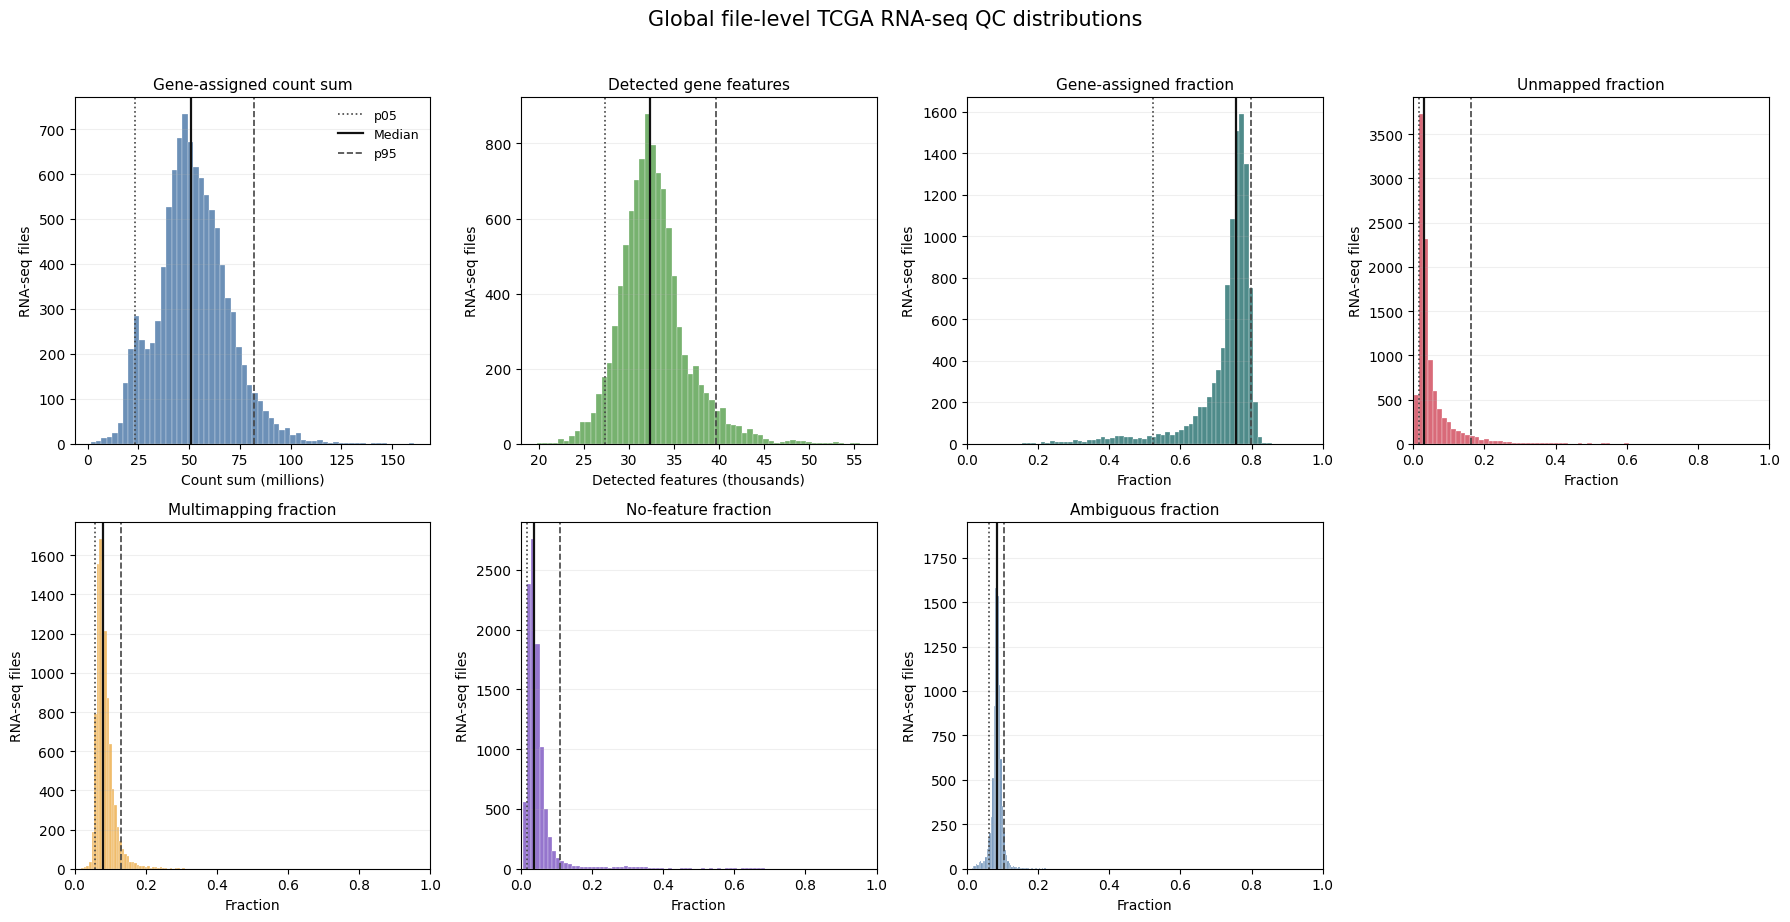

In [30]:
# -----------------------------------------------------------------------------
# Figure 1: global QC distributions
# -----------------------------------------------------------------------------

global_plot_specs = [
    (
        "gene_count_sum",
        "Gene-assigned count sum",
        "Count sum (millions)",
        lambda values: values / 1_000_000,
        "#4C78A8",
    ),
    (
        "detected_gene_features",
        "Detected gene features",
        "Detected features (thousands)",
        lambda values: values / 1_000,
        "#59A14F",
    ),
    (
        "gene_assigned_fraction_of_accounted",
        "Gene-assigned fraction",
        "Fraction",
        lambda values: values,
        "#287271",
    ),
    (
        "star_n_unmapped_fraction_of_accounted",
        "Unmapped fraction",
        "Fraction",
        lambda values: values,
        "#D1495B",
    ),
    (
        "star_n_multimapping_fraction_of_accounted",
        "Multimapping fraction",
        "Fraction",
        lambda values: values,
        "#EDAE49",
    ),
    (
        "star_n_no_feature_fraction_of_accounted",
        "No-feature fraction",
        "Fraction",
        lambda values: values,
        "#7E57C2",
    ),
    (
        "star_n_ambiguous_fraction_of_accounted",
        "Ambiguous fraction",
        "Fraction",
        lambda values: values,
        "#4C78A8",
    ),
]

fig, axes = plt.subplots(
    nrows=2,
    ncols=4,
    figsize=(18, 9),
)

axes = axes.ravel()

for axis_index, (
    metric_name,
    metric_title,
    x_axis_label,
    transform_values,
    metric_color,
) in enumerate(global_plot_specs):
    axis = axes[axis_index]

    plotted_values = transform_values(
        rna_qc_distribution_table[
            metric_name
        ].to_numpy(dtype=np.float64)
    )

    metric_p05, metric_median, metric_p95 = np.quantile(
        plotted_values,
        [0.05, 0.50, 0.95],
    )

    axis.hist(
        plotted_values,
        bins=60,
        color=metric_color,
        alpha=0.82,
        edgecolor="white",
        linewidth=0.25,
    )

    axis.axvline(
        metric_p05,
        color="#444444",
        linestyle=":",
        linewidth=1.2,
        label="p05",
    )

    axis.axvline(
        metric_median,
        color="#111111",
        linestyle="-",
        linewidth=1.6,
        label="Median",
    )

    axis.axvline(
        metric_p95,
        color="#444444",
        linestyle="--",
        linewidth=1.2,
        label="p95",
    )

    axis.set_title(
        metric_title,
        fontsize=11,
    )
    axis.set_xlabel(x_axis_label)
    axis.set_ylabel("RNA-seq files")
    axis.grid(
        axis="y",
        alpha=0.20,
    )

    if "fraction" in metric_name:
        axis.set_xlim(0, 1)

    if axis_index == 0:
        axis.legend(
            frameon=False,
            fontsize=9,
        )

axes[-1].axis("off")

fig.suptitle(
    "Global file-level TCGA RNA-seq QC distributions",
    fontsize=15,
    y=1.02,
)

fig.tight_layout()
plt.show()




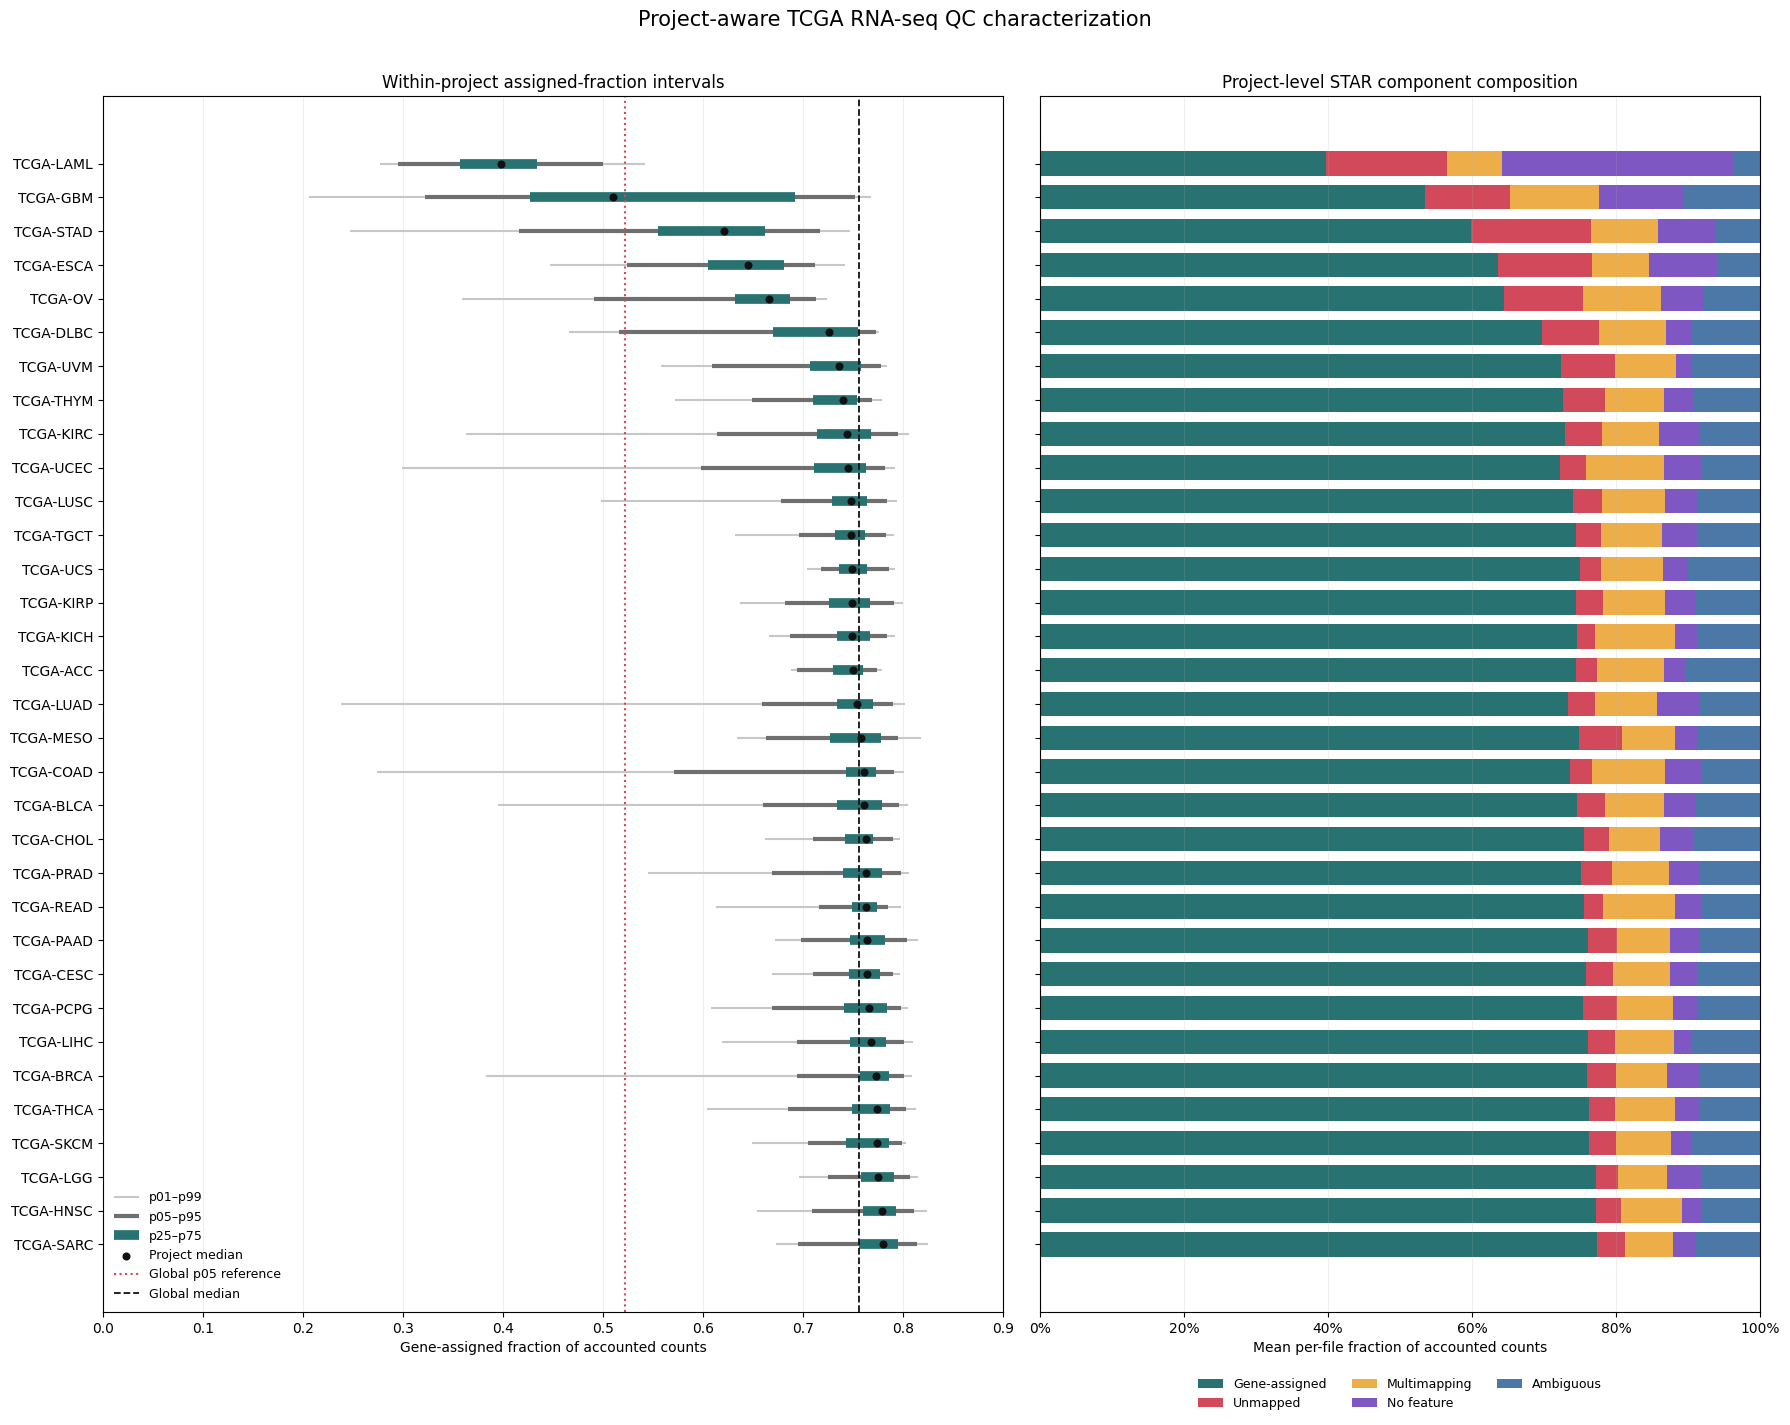

In [31]:
# -----------------------------------------------------------------------------
# Figure 2: project-level assigned fractions and component composition
# -----------------------------------------------------------------------------

project_positions = np.arange(
    len(project_order)
)

fig, (
    assigned_axis,
    composition_axis,
) = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(18, 14),
    sharey=True,
    gridspec_kw={
        "width_ratios": [1.25, 1.0],
    },
)

# p01–p99 interval
assigned_axis.hlines(
    y=project_positions,
    xmin=project_assigned_quantiles["p01"],
    xmax=project_assigned_quantiles["p99"],
    color="#C7C7C7",
    linewidth=1.5,
    label="p01–p99",
)

# p05–p95 interval
assigned_axis.hlines(
    y=project_positions,
    xmin=project_assigned_quantiles["p05"],
    xmax=project_assigned_quantiles["p95"],
    color="#6F6F6F",
    linewidth=3.0,
    label="p05–p95",
)

# Interquartile interval
assigned_axis.hlines(
    y=project_positions,
    xmin=project_assigned_quantiles["p25"],
    xmax=project_assigned_quantiles["p75"],
    color="#287271",
    linewidth=7.0,
    label="p25–p75",
)

# Project median
assigned_axis.scatter(
    project_assigned_quantiles["median"],
    project_positions,
    color="#111111",
    s=23,
    zorder=3,
    label="Project median",
)

assigned_axis.axvline(
    global_assigned_p05,
    color="#D1495B",
    linestyle=":",
    linewidth=1.5,
    label="Global p05 reference",
)

assigned_axis.axvline(
    global_assigned_median,
    color="#111111",
    linestyle="--",
    linewidth=1.3,
    label="Global median",
)

assigned_axis.set_xlim(0, 0.90)
assigned_axis.set_yticks(
    project_positions,
    labels=project_order,
)
assigned_axis.invert_yaxis()
assigned_axis.set_xlabel(
    "Gene-assigned fraction of accounted counts"
)
assigned_axis.set_title(
    "Within-project assigned-fraction intervals"
)
assigned_axis.grid(
    axis="x",
    alpha=0.20,
)

assigned_axis.legend(
    loc="lower left",
    frameon=False,
    fontsize=9,
)


# Mean per-file STAR component composition
stacked_left = np.zeros(
    len(project_order),
    dtype=np.float64,
)

for component_column in component_columns:
    component_values = (
        project_mean_component_fractions[
            component_column
        ].to_numpy(dtype=np.float64)
    )

    composition_axis.barh(
        project_positions,
        component_values,
        left=stacked_left,
        height=0.72,
        color=qc_fraction_component_colors[
            component_column
        ],
        label=qc_fraction_component_labels[
            component_column
        ],
    )

    stacked_left += component_values

composition_axis.set_xlim(0, 1)
composition_axis.xaxis.set_major_formatter(
    PercentFormatter(xmax=1.0)
)
composition_axis.set_xlabel(
    "Mean per-file fraction of accounted counts"
)
composition_axis.set_title(
    "Project-level STAR component composition"
)
composition_axis.grid(
    axis="x",
    alpha=0.20,
)

composition_axis.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.045),
    ncol=3,
    frameon=False,
    fontsize=9,
)

fig.suptitle(
    "Project-aware TCGA RNA-seq QC characterization",
    fontsize=15,
    y=1.01,
)

fig.tight_layout()
plt.show()




In [32]:
# -----------------------------------------------------------------------------
# Print the projects most represented below the global p05 reference
# -----------------------------------------------------------------------------

global_tail_display = (
    project_global_tail_reference
    .head(12)
    .copy()
)

global_tail_formatters = {
    "n_files": lambda value: f"{value:,.0f}",
    "n_cases": lambda value: f"{value:,.0f}",
    "assigned_fraction_p05": (
        lambda value: f"{value:.4f}"
    ),
    "assigned_fraction_median": (
        lambda value: f"{value:.4f}"
    ),
    "assigned_fraction_p95": (
        lambda value: f"{value:.4f}"
    ),
    "fraction_below_global_p05": (
        lambda value: f"{100 * value:.1f}%"
    ),
    "fraction_below_global_p01": (
        lambda value: f"{100 * value:.1f}%"
    ),
}

print(
    "\nProjects most represented below the global "
    "assigned-fraction p05 reference:"
)
print(
    global_tail_display.to_string(
        index=False,
        formatters=global_tail_formatters,
    )
)

print(
    "\nReference only: the global p01 and p05 are not "
    "sample-exclusion thresholds."
)


Projects most represented below the global assigned-fraction p05 reference:
project_id n_files n_cases assigned_fraction_p05 assigned_fraction_median assigned_fraction_p95 fraction_below_global_p05 fraction_below_global_p01
 TCGA-LAML     134     134                0.2954                   0.3985                0.5001                     97.8%                     13.4%
  TCGA-GBM     289     230                0.3219                   0.5101                0.7523                     54.0%                      6.2%
 TCGA-STAD     412     412                0.4164                   0.6213                0.7170                     14.6%                      3.4%
   TCGA-OV     422     422                0.4913                   0.6657                0.7127                      6.4%                      0.5%
 TCGA-DLBC      48      48                0.5165                   0.7255                0.7734                      6.2%                      0.0%
 TCGA-ESCA     184     184         

## 5. Project-aware extreme-file review


In [33]:
# =============================================================================
# Identify project-relative multidomain extreme files for manual review
# =============================================================================


# -----------------------------------------------------------------------------
# Prepare the review table
# -----------------------------------------------------------------------------

rna_qc_extreme_review = rna_qc_distribution_table.copy()

rna_qc_extreme_review[
    "maximum_gene_fraction_of_assigned"
] = (
    rna_qc_extreme_review["maximum_gene_count"]
    / rna_qc_extreme_review["gene_count_sum"]
)

rna_qc_extreme_review["case_rna_file_count"] = (
    rna_qc_extreme_review
    .groupby(
        [
            "project_id",
            "case_submitter_id",
        ],
        observed=True,
        sort=False,
    )["rna_file_id"]
    .transform("size")
    .astype("int64")
)


# -----------------------------------------------------------------------------
# Define adverse QC directions
#
# Project q01/q99 references are sensitive screening references only.
# They are not sample-exclusion thresholds.
# -----------------------------------------------------------------------------

adverse_qc_signals = {
    "low_gene_count_sum": {
        "metric": "gene_count_sum",
        "direction": "low",
        "reference_quantile": 0.01,
        "label": "Low gene-assigned count sum",
    },
    "low_detected_features": {
        "metric": "detected_gene_features",
        "direction": "low",
        "reference_quantile": 0.01,
        "label": "Low detected-feature count",
    },
    "high_maximum_gene_fraction": {
        "metric": "maximum_gene_fraction_of_assigned",
        "direction": "high",
        "reference_quantile": 0.99,
        "label": "High maximum-gene fraction",
    },
    "low_assigned_fraction": {
        "metric": "gene_assigned_fraction_of_accounted",
        "direction": "low",
        "reference_quantile": 0.01,
        "label": "Low gene-assigned fraction",
    },
    "high_unmapped_fraction": {
        "metric": "star_n_unmapped_fraction_of_accounted",
        "direction": "high",
        "reference_quantile": 0.99,
        "label": "High unmapped fraction",
    },
    "high_multimapping_fraction": {
        "metric": "star_n_multimapping_fraction_of_accounted",
        "direction": "high",
        "reference_quantile": 0.99,
        "label": "High multimapping fraction",
    },
    "high_no_feature_fraction": {
        "metric": "star_n_no_feature_fraction_of_accounted",
        "direction": "high",
        "reference_quantile": 0.99,
        "label": "High no-feature fraction",
    },
    "high_ambiguous_fraction": {
        "metric": "star_n_ambiguous_fraction_of_accounted",
        "direction": "high",
        "reference_quantile": 0.99,
        "label": "High ambiguous fraction",
    },
}




In [34]:
# -----------------------------------------------------------------------------
# Construct project-relative and global extreme-reference indicators
# -----------------------------------------------------------------------------

global_extreme_reference_records = []
project_reference_columns = []
project_flag_columns = []
global_flag_columns = []

for signal_name, signal_specification in adverse_qc_signals.items():
    metric_name = signal_specification["metric"]
    direction = signal_specification["direction"]
    reference_quantile = signal_specification[
        "reference_quantile"
    ]

    project_reference_column = (
        f"project_reference_{signal_name}"
    )
    project_flag_column = (
        f"project_extreme_{signal_name}"
    )
    global_flag_column = (
        f"global_extreme_{signal_name}"
    )

    project_reference_columns.append(
        project_reference_column
    )
    project_flag_columns.append(
        project_flag_column
    )
    global_flag_columns.append(
        global_flag_column
    )

    rna_qc_extreme_review[
        project_reference_column
    ] = (
        rna_qc_extreme_review
        .groupby(
            "project_id",
            observed=True,
            sort=False,
        )[metric_name]
        .transform(
            lambda values: values.quantile(
                reference_quantile
            )
        )
    )

    global_reference_value = float(
        rna_qc_extreme_review[
            metric_name
        ].quantile(reference_quantile)
    )

    if direction == "low":
        rna_qc_extreme_review[
            project_flag_column
        ] = (
            rna_qc_extreme_review[metric_name]
            <= rna_qc_extreme_review[
                project_reference_column
            ]
        )

        rna_qc_extreme_review[
            global_flag_column
        ] = (
            rna_qc_extreme_review[metric_name]
            <= global_reference_value
        )

    elif direction == "high":
        rna_qc_extreme_review[
            project_flag_column
        ] = (
            rna_qc_extreme_review[metric_name]
            >= rna_qc_extreme_review[
                project_reference_column
            ]
        )

        rna_qc_extreme_review[
            global_flag_column
        ] = (
            rna_qc_extreme_review[metric_name]
            >= global_reference_value
        )

    else:
        raise ValueError(
            f"Unsupported adverse direction: {direction}"
        )

    global_extreme_reference_records.append(
        {
            "signal": signal_name,
            "metric": metric_name,
            "direction": direction,
            "reference_quantile": reference_quantile,
            "reference_value": global_reference_value,
        }
    )

global_qc_extreme_references = pd.DataFrame(
    global_extreme_reference_records
)


# -----------------------------------------------------------------------------
# Collapse correlated signals into four interpretable QC domains
#
# The five STAR composition metrics are mathematically dependent, so they
# contribute only one domain regardless of how many component flags are present.
# -----------------------------------------------------------------------------

qc_domain_signals = {
    "yield": [
        "low_gene_count_sum",
    ],
    "breadth": [
        "low_detected_features",
    ],
    "dominance": [
        "high_maximum_gene_fraction",
    ],
    "star_composition": [
        "low_assigned_fraction",
        "high_unmapped_fraction",
        "high_multimapping_fraction",
        "high_no_feature_fraction",
        "high_ambiguous_fraction",
    ],
}

qc_domain_labels = {
    "yield": "Yield",
    "breadth": "Breadth",
    "dominance": "Gene dominance",
    "star_composition": "STAR composition",
}

for reference_scope in [
    "project",
    "global",
]:
    domain_flag_columns = []

    for domain_name, domain_signals in (
        qc_domain_signals.items()
    ):
        domain_flag_column = (
            f"{reference_scope}_extreme_domain_"
            f"{domain_name}"
        )

        signal_flag_columns = [
            (
                f"{reference_scope}_extreme_"
                f"{signal_name}"
            )
            for signal_name in domain_signals
        ]

        rna_qc_extreme_review[
            domain_flag_column
        ] = (
            rna_qc_extreme_review[
                signal_flag_columns
            ]
            .any(axis=1)
        )

        domain_flag_columns.append(
            domain_flag_column
        )

    rna_qc_extreme_review[
        f"{reference_scope}_extreme_signal_count"
    ] = (
        rna_qc_extreme_review[
            [
                (
                    f"{reference_scope}_extreme_"
                    f"{signal_name}"
                )
                for signal_name in adverse_qc_signals
            ]
        ]
        .sum(axis=1)
        .astype("int64")
    )

    rna_qc_extreme_review[
        f"{reference_scope}_extreme_domain_count"
    ] = (
        rna_qc_extreme_review[
            domain_flag_columns
        ]
        .sum(axis=1)
        .astype("int64")
    )


# -----------------------------------------------------------------------------
# Define the multidomain review candidate
#
# This is a diagnostic candidate designation, not an exclusion decision.
# -----------------------------------------------------------------------------

rna_qc_extreme_review[
    "project_multidomain_review_candidate"
] = (
    rna_qc_extreme_review[
        "project_extreme_domain_count"
    ]
    >= 2
)




In [35]:
# -----------------------------------------------------------------------------
# Add readable descriptions of the triggered signals and domains
# -----------------------------------------------------------------------------

def describe_triggered_signals(row, reference_scope):
    triggered_labels = [
        signal_specification["label"]
        for signal_name, signal_specification
        in adverse_qc_signals.items()
        if row[
            f"{reference_scope}_extreme_{signal_name}"
        ]
    ]

    return "; ".join(triggered_labels)


def describe_triggered_domains(row, reference_scope):
    triggered_labels = [
        domain_label
        for domain_name, domain_label
        in qc_domain_labels.items()
        if row[
            (
                f"{reference_scope}_extreme_domain_"
                f"{domain_name}"
            )
        ]
    ]

    return "; ".join(triggered_labels)


rna_qc_extreme_review[
    "project_extreme_signals"
] = rna_qc_extreme_review.apply(
    describe_triggered_signals,
    axis=1,
    reference_scope="project",
)

rna_qc_extreme_review[
    "project_extreme_domains"
] = rna_qc_extreme_review.apply(
    describe_triggered_domains,
    axis=1,
    reference_scope="project",
)

rna_qc_extreme_review[
    "global_extreme_signals"
] = rna_qc_extreme_review.apply(
    describe_triggered_signals,
    axis=1,
    reference_scope="global",
)

rna_qc_extreme_review[
    "global_extreme_domains"
] = rna_qc_extreme_review.apply(
    describe_triggered_domains,
    axis=1,
    reference_scope="global",
)


# -----------------------------------------------------------------------------
# Count review-candidate files within each case
#
# Multiplicity is characterized but not resolved here.
# -----------------------------------------------------------------------------

rna_qc_extreme_review[
    "case_multidomain_candidate_file_count"
] = (
    rna_qc_extreme_review
    .groupby(
        [
            "project_id",
            "case_submitter_id",
        ],
        observed=True,
        sort=False,
    )[
        "project_multidomain_review_candidate"
    ]
    .transform("sum")
    .astype("int64")
)




In [36]:
# -----------------------------------------------------------------------------
# Validate the project-aware extreme review
# -----------------------------------------------------------------------------

maximum_gene_fraction_array = (
    rna_qc_extreme_review[
        "maximum_gene_fraction_of_assigned"
    ]
    .to_numpy(dtype=np.float64)
)

project_reference_array = (
    rna_qc_extreme_review[
        project_reference_columns
    ]
    .to_numpy(dtype=np.float64)
)

extreme_review_checks = {
    "all_source_files_are_retained": (
        len(rna_qc_extreme_review)
        == EXPECTED_RNA_FILES
    ),
    "source_file_identity_and_order_are_preserved": (
        rna_qc_extreme_review[
            "rna_file_id"
        ].tolist()
        == rna_qc_distribution_table[
            "rna_file_id"
        ].tolist()
    ),
    "gene_count_sums_are_positive": (
        rna_qc_extreme_review[
            "gene_count_sum"
        ]
        .gt(0)
        .all()
    ),
    "maximum_gene_fractions_are_complete": (
        np.isfinite(
            maximum_gene_fraction_array
        ).all()
    ),
    "maximum_gene_fractions_are_bounded": (
        (
            (maximum_gene_fraction_array >= 0)
            & (maximum_gene_fraction_array <= 1)
        )
        .all()
    ),
    "project_references_are_complete": (
        np.isfinite(
            project_reference_array
        ).all()
    ),
    "project_flags_are_boolean": all(
        pd.api.types.is_bool_dtype(
            rna_qc_extreme_review[column_name]
        )
        for column_name in project_flag_columns
    ),
    "global_flags_are_boolean": all(
        pd.api.types.is_bool_dtype(
            rna_qc_extreme_review[column_name]
        )
        for column_name in global_flag_columns
    ),
    "project_domain_counts_are_bounded": (
        rna_qc_extreme_review[
            "project_extreme_domain_count"
        ]
        .between(
            0,
            len(qc_domain_signals),
        )
        .all()
    ),
    "global_domain_counts_are_bounded": (
        rna_qc_extreme_review[
            "global_extreme_domain_count"
        ]
        .between(
            0,
            len(qc_domain_signals),
        )
        .all()
    ),
    "candidate_definition_is_consistent": (
        rna_qc_extreme_review[
            "project_multidomain_review_candidate"
        ]
        .eq(
            rna_qc_extreme_review[
                "project_extreme_domain_count"
            ]
            >= 2
        )
        .all()
    ),
}

print("Project-aware extreme-review checks:")
for check_name, check_passed in (
    extreme_review_checks.items()
):
    print(f"{check_name}: {check_passed}")

if not all(extreme_review_checks.values()):
    failed_checks = [
        check_name
        for check_name, check_passed
        in extreme_review_checks.items()
        if not check_passed
    ]

    raise ValueError(
        "Project-aware extreme review failed: "
        + ", ".join(failed_checks)
    )




Project-aware extreme-review checks:
all_source_files_are_retained: True
source_file_identity_and_order_are_preserved: True
gene_count_sums_are_positive: True
maximum_gene_fractions_are_complete: True
maximum_gene_fractions_are_bounded: True
project_references_are_complete: True
project_flags_are_boolean: True
global_flags_are_boolean: True
project_domain_counts_are_bounded: True
global_domain_counts_are_bounded: True
candidate_definition_is_consistent: True


In [37]:
# -----------------------------------------------------------------------------
# Construct project-level candidate summary
# -----------------------------------------------------------------------------

project_extreme_candidate_records = []

for project_id, project_table in (
    rna_qc_extreme_review
    .groupby(
        "project_id",
        observed=True,
        sort=True,
    )
):
    candidate_mask = project_table[
        "project_multidomain_review_candidate"
    ]

    candidate_table = project_table.loc[
        candidate_mask
    ]

    project_extreme_candidate_records.append(
        {
            "project_id": str(project_id),
            "n_files": int(len(project_table)),
            "n_cases": int(
                project_table[
                    "case_submitter_id"
                ].nunique()
            ),
            "n_multidomain_candidate_files": int(
                candidate_mask.sum()
            ),
            "fraction_multidomain_candidate_files": float(
                candidate_mask.mean()
            ),
            "n_candidate_cases": int(
                candidate_table[
                    "case_submitter_id"
                ].nunique()
            ),
            "n_files_extreme_in_3plus_domains": int(
                (
                    project_table[
                        "project_extreme_domain_count"
                    ]
                    >= 3
                ).sum()
            ),
        }
    )

project_extreme_candidate_summary = (
    pd.DataFrame(
        project_extreme_candidate_records
    )
    .sort_values(
        [
            "n_files_extreme_in_3plus_domains",
            "n_multidomain_candidate_files",
            "fraction_multidomain_candidate_files",
            "project_id",
        ],
        ascending=[
            False,
            False,
            False,
            True,
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)


# -----------------------------------------------------------------------------
# Construct the file-level multidomain candidate table
# -----------------------------------------------------------------------------

multidomain_extreme_candidates = (
    rna_qc_extreme_review.loc[
        rna_qc_extreme_review[
            "project_multidomain_review_candidate"
        ]
    ]
    .sort_values(
        [
            "project_extreme_domain_count",
            "project_extreme_signal_count",
            "global_extreme_domain_count",
            "global_extreme_signal_count",
            "gene_assigned_fraction_of_accounted",
            "gene_count_sum",
            "project_id",
            "rna_file_id",
        ],
        ascending=[
            False,
            False,
            False,
            False,
            True,
            True,
            True,
            True,
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)




In [38]:
# -----------------------------------------------------------------------------
# Print project-level candidate counts
# -----------------------------------------------------------------------------

project_candidate_display = (
    project_extreme_candidate_summary.loc[
        project_extreme_candidate_summary[
            "n_multidomain_candidate_files"
        ]
        > 0
    ]
    .copy()
)

project_candidate_formatters = {
    "n_files": lambda value: f"{value:,.0f}",
    "n_cases": lambda value: f"{value:,.0f}",
    "n_multidomain_candidate_files": (
        lambda value: f"{value:,.0f}"
    ),
    "fraction_multidomain_candidate_files": (
        lambda value: f"{100 * value:.2f}%"
    ),
    "n_candidate_cases": (
        lambda value: f"{value:,.0f}"
    ),
    "n_files_extreme_in_3plus_domains": (
        lambda value: f"{value:,.0f}"
    ),
}

print(
    "\nProjects containing project-relative "
    "multidomain review candidates:"
)
print(
    project_candidate_display.to_string(
        index=False,
        formatters=project_candidate_formatters,
    )
)


# -----------------------------------------------------------------------------
# Print the highest-burden file-level candidates
# -----------------------------------------------------------------------------

maximum_display_rows = 40

candidate_display_columns = [
    "project_id",
    "case_submitter_id",
    "rna_file_id",
    "matrix_column_index",
    "case_rna_file_count",
    "case_multidomain_candidate_file_count",
    "gene_count_sum",
    "detected_gene_features",
    "maximum_gene_fraction_of_assigned",
    "gene_assigned_fraction_of_accounted",
    "star_n_unmapped_fraction_of_accounted",
    "star_n_multimapping_fraction_of_accounted",
    "star_n_no_feature_fraction_of_accounted",
    "star_n_ambiguous_fraction_of_accounted",
    "project_extreme_domain_count",
    "project_extreme_signal_count",
    "global_extreme_domain_count",
    "project_extreme_domains",
    "project_extreme_signals",
]

candidate_display_formatters = {
    "matrix_column_index": (
        lambda value: f"{value:,.0f}"
    ),
    "case_rna_file_count": (
        lambda value: f"{value:,.0f}"
    ),
    "case_multidomain_candidate_file_count": (
        lambda value: f"{value:,.0f}"
    ),
    "gene_count_sum": (
        lambda value: f"{value:,.0f}"
    ),
    "detected_gene_features": (
        lambda value: f"{value:,.0f}"
    ),
    "maximum_gene_fraction_of_assigned": (
        lambda value: f"{value:.4f}"
    ),
    "gene_assigned_fraction_of_accounted": (
        lambda value: f"{value:.4f}"
    ),
    "star_n_unmapped_fraction_of_accounted": (
        lambda value: f"{value:.4f}"
    ),
    "star_n_multimapping_fraction_of_accounted": (
        lambda value: f"{value:.4f}"
    ),
    "star_n_no_feature_fraction_of_accounted": (
        lambda value: f"{value:.4f}"
    ),
    "star_n_ambiguous_fraction_of_accounted": (
        lambda value: f"{value:.4f}"
    ),
    "project_extreme_domain_count": (
        lambda value: f"{value:,.0f}"
    ),
    "project_extreme_signal_count": (
        lambda value: f"{value:,.0f}"
    ),
    "global_extreme_domain_count": (
        lambda value: f"{value:,.0f}"
    ),
}

print(
    "\nHighest-burden project-relative "
    "multidomain file candidates:"
)
print(
    multidomain_extreme_candidates[
        candidate_display_columns
    ]
    .head(maximum_display_rows)
    .to_string(
        index=False,
        formatters=candidate_display_formatters,
    )
)


# -----------------------------------------------------------------------------
# Final scope statement
# -----------------------------------------------------------------------------

print("\nProject-aware extreme review completed.")
print(
    f"Files evaluated:                 "
    f"{len(rna_qc_extreme_review):,}"
)
print(
    f"Multidomain candidate files:     "
    f"{len(multidomain_extreme_candidates):,}"
)
print(
    f"Cases represented by candidates: "
    f"{multidomain_extreme_candidates['case_submitter_id'].nunique():,}"
)
print(
    f"Files extreme in 3+ domains:     "
    f"{(rna_qc_extreme_review['project_extreme_domain_count'] >= 3).sum():,}"
)
print(
    "Candidate rule:                 "
    "extreme in at least two project-relative QC domains"
)
print(
    "Reference policy:               "
    "within-project q01/q99 references used for sensitive review"
)
print(
    "Multiplicity policy:            "
    "repeated files retained and annotated, not resolved"
)
print(
    "Exclusion policy:               "
    "no files excluded; all indicators remain diagnostic"
)


Projects containing project-relative multidomain review candidates:
project_id n_files n_cases n_multidomain_candidate_files fraction_multidomain_candidate_files n_candidate_cases n_files_extreme_in_3plus_domains
 TCGA-BRCA   1,103   1,091                            16                                1.45%                14                                3
 TCGA-PRAD     501     497                             8                                1.60%                 8                                2
   TCGA-OV     422     422                             5                                1.18%                 5                                2
  TCGA-GBM     289     230                             4                                1.38%                 4                                2
  TCGA-LGG     513     513                             8                                1.56%                 8                                1
 TCGA-BLCA     412     406                             6     

In [39]:
# =============================================================================
# Stratify multidomain candidates and inspect within-case file context
# =============================================================================


# -----------------------------------------------------------------------------
# Prepare the review table
# -----------------------------------------------------------------------------

rna_qc_candidate_stratification = (
    rna_qc_extreme_review.copy()
)

candidate_column = (
    "project_multidomain_review_candidate"
)

yield_domain_column = (
    "project_extreme_domain_yield"
)

breadth_domain_column = (
    "project_extreme_domain_breadth"
)

dominance_domain_column = (
    "project_extreme_domain_dominance"
)

star_domain_column = (
    "project_extreme_domain_star_composition"
)


required_stratification_columns = [
    "project_id",
    "case_submitter_id",
    "rna_file_id",
    "case_rna_file_count",
    candidate_column,
    yield_domain_column,
    breadth_domain_column,
    dominance_domain_column,
    star_domain_column,
    "project_extreme_domain_count",
    "project_extreme_signal_count",
    "global_extreme_domain_count",
    "gene_count_sum",
    "detected_gene_features",
    "maximum_gene_fraction_of_assigned",
    "gene_assigned_fraction_of_accounted",
    "star_n_unmapped_fraction_of_accounted",
    "star_n_multimapping_fraction_of_accounted",
    "star_n_no_feature_fraction_of_accounted",
    "star_n_ambiguous_fraction_of_accounted",
]

missing_stratification_columns = sorted(
    set(required_stratification_columns)
    - set(rna_qc_candidate_stratification.columns)
)

if missing_stratification_columns:
    raise ValueError(
        "Missing columns required for candidate stratification: "
        + ", ".join(missing_stratification_columns)
    )


# -----------------------------------------------------------------------------
# Define descriptive review strata
#
# These strata prioritize inspection. They are not exclusion categories.
# -----------------------------------------------------------------------------

low_yield_breadth_composition_pattern = (
    rna_qc_candidate_stratification[
        yield_domain_column
    ]
    & rna_qc_candidate_stratification[
        breadth_domain_column
    ]
    & rna_qc_candidate_stratification[
        star_domain_column
    ]
)

other_three_domain_pattern = (
    rna_qc_candidate_stratification[
        candidate_column
    ]
    & (
        rna_qc_candidate_stratification[
            "project_extreme_domain_count"
        ]
        >= 3
    )
    & ~low_yield_breadth_composition_pattern
)

two_domain_pattern = (
    rna_qc_candidate_stratification[
        candidate_column
    ]
    & (
        rna_qc_candidate_stratification[
            "project_extreme_domain_count"
        ]
        == 2
    )
)

review_stratum_order = [
    "Priority 1 — low yield, breadth, and STAR composition",
    "Priority 2 — other three-domain profile",
    "Priority 3 — two-domain sensitive-screen candidate",
    "Not a multidomain candidate",
]

rna_qc_candidate_stratification[
    "qc_review_stratum"
] = pd.Categorical(
    np.select(
        [
            low_yield_breadth_composition_pattern,
            other_three_domain_pattern,
            two_domain_pattern,
        ],
        review_stratum_order[:3],
        default=review_stratum_order[3],
    ),
    categories=review_stratum_order,
    ordered=True,
)




In [40]:
# -----------------------------------------------------------------------------
# Summarize candidate-domain patterns
# -----------------------------------------------------------------------------

candidate_pattern_summary = (
    rna_qc_candidate_stratification.loc[
        rna_qc_candidate_stratification[
            candidate_column
        ]
    ]
    .groupby(
        [
            "qc_review_stratum",
            "project_extreme_domains",
        ],
        observed=True,
        sort=False,
    )
    .agg(
        n_files=("rna_file_id", "size"),
        n_cases=("case_submitter_id", "nunique"),
        n_projects=("project_id", "nunique"),
        median_gene_count_sum=(
            "gene_count_sum",
            "median",
        ),
        median_detected_features=(
            "detected_gene_features",
            "median",
        ),
        median_assigned_fraction=(
            "gene_assigned_fraction_of_accounted",
            "median",
        ),
    )
    .reset_index()
    .sort_values(
        [
            "qc_review_stratum",
            "n_files",
            "project_extreme_domains",
        ],
        ascending=[True, False, True],
        kind="stable",
    )
    .reset_index(drop=True)
)


# -----------------------------------------------------------------------------
# Characterize candidate status within each case
#
# A case-level comparison is contextual only. Multiple files belonging to the
# same case are not assumed to represent technical replicates.
# -----------------------------------------------------------------------------

case_candidate_context = (
    rna_qc_candidate_stratification
    .groupby(
        [
            "project_id",
            "case_submitter_id",
        ],
        observed=True,
        sort=False,
    )
    .agg(
        n_case_files=("rna_file_id", "size"),
        n_candidate_files=(
            candidate_column,
            "sum",
        ),
        n_priority_1_files=(
            "qc_review_stratum",
            lambda values: (
                values
                == review_stratum_order[0]
            ).sum(),
        ),
        n_priority_2_files=(
            "qc_review_stratum",
            lambda values: (
                values
                == review_stratum_order[1]
            ).sum(),
        ),
        n_priority_3_files=(
            "qc_review_stratum",
            lambda values: (
                values
                == review_stratum_order[2]
            ).sum(),
        ),
    )
    .reset_index()
)

case_candidate_context[
    [
        "n_candidate_files",
        "n_priority_1_files",
        "n_priority_2_files",
        "n_priority_3_files",
    ]
] = (
    case_candidate_context[
        [
            "n_candidate_files",
            "n_priority_1_files",
            "n_priority_2_files",
            "n_priority_3_files",
        ]
    ]
    .astype("int64")
)

case_candidate_context[
    "candidate_case_context"
] = np.select(
    [
        (
            case_candidate_context[
                "n_candidate_files"
            ]
            == 0
        ),
        (
            (
                case_candidate_context[
                    "n_case_files"
                ]
                == 1
            )
            & (
                case_candidate_context[
                    "n_candidate_files"
                ]
                == 1
            )
        ),
        (
            (
                case_candidate_context[
                    "n_case_files"
                ]
                > 1
            )
            & (
                case_candidate_context[
                    "n_candidate_files"
                ]
                < case_candidate_context[
                    "n_case_files"
                ]
            )
        ),
        (
            (
                case_candidate_context[
                    "n_case_files"
                ]
                > 1
            )
            & (
                case_candidate_context[
                    "n_candidate_files"
                ]
                == case_candidate_context[
                    "n_case_files"
                ]
            )
        ),
    ],
    [
        "No candidate files",
        "Single-file candidate case",
        "Mixed candidate/noncandidate multi-file case",
        "All files candidate in multi-file case",
    ],
    default="Unclassified",
)

rna_qc_candidate_stratification = (
    rna_qc_candidate_stratification.merge(
        case_candidate_context[
            [
                "project_id",
                "case_submitter_id",
                "n_case_files",
                "n_candidate_files",
                "candidate_case_context",
            ]
        ],
        on=[
            "project_id",
            "case_submitter_id",
        ],
        how="left",
        validate="many_to_one",
    )
)




In [41]:
# -----------------------------------------------------------------------------
# Identify available specimen-identity and file-name columns
# -----------------------------------------------------------------------------

preferred_context_columns = [
    "rna_file_name",
    "file_name",
    "filename",
    "sample_submitter_id",
    "rna_sample_submitter_id",
    "sample_id",
    "portion_submitter_id",
    "rna_portion_submitter_id",
    "portion_id",
    "analyte_submitter_id",
    "rna_analyte_submitter_id",
    "aliquot_submitter_id",
    "rna_aliquot_submitter_id",
    "aliquot_id",
]

available_context_columns = [
    column_name
    for column_name in preferred_context_columns
    if column_name
    in rna_qc_candidate_stratification.columns
]


# -----------------------------------------------------------------------------
# Construct the Priority-1 candidate table
# -----------------------------------------------------------------------------

priority_1_candidates = (
    rna_qc_candidate_stratification.loc[
        rna_qc_candidate_stratification[
            "qc_review_stratum"
        ]
        == review_stratum_order[0]
    ]
    .sort_values(
        [
            "global_extreme_domain_count",
            "project_extreme_signal_count",
            "gene_assigned_fraction_of_accounted",
            "gene_count_sum",
            "project_id",
            "rna_file_id",
        ],
        ascending=[
            False,
            False,
            True,
            True,
            True,
            True,
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)


# -----------------------------------------------------------------------------
# Construct the multi-file candidate-case context
# -----------------------------------------------------------------------------

candidate_multifile_case_keys = (
    case_candidate_context.loc[
        (
            case_candidate_context[
                "n_candidate_files"
            ]
            > 0
        )
        & (
            case_candidate_context[
                "n_case_files"
            ]
            > 1
        ),
        [
            "project_id",
            "case_submitter_id",
        ],
    ]
    .drop_duplicates()
)

candidate_multifile_context = (
    rna_qc_candidate_stratification.merge(
        candidate_multifile_case_keys,
        on=[
            "project_id",
            "case_submitter_id",
        ],
        how="inner",
        validate="many_to_one",
    )
    .sort_values(
        [
            "project_id",
            "case_submitter_id",
            candidate_column,
            "project_extreme_domain_count",
            "rna_file_id",
        ],
        ascending=[
            True,
            True,
            False,
            False,
            True,
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)




In [42]:
# -----------------------------------------------------------------------------
# Validate the stratification
# -----------------------------------------------------------------------------

candidate_mask = (
    rna_qc_candidate_stratification[
        candidate_column
    ]
)

candidate_stratum_mask = (
    rna_qc_candidate_stratification[
        "qc_review_stratum"
    ]
    != review_stratum_order[3]
)

stratification_checks = {
    "all_source_files_are_retained": (
        len(rna_qc_candidate_stratification)
        == len(rna_qc_extreme_review)
    ),
    "candidate_status_is_preserved": (
        candidate_mask.sum()
        == len(multidomain_extreme_candidates)
    ),
    "candidate_strata_are_exhaustive": (
        candidate_mask.eq(
            candidate_stratum_mask
        ).all()
    ),
    "priority_1_definition_is_consistent": (
        priority_1_candidates[
            yield_domain_column
        ].all()
        and priority_1_candidates[
            breadth_domain_column
        ].all()
        and priority_1_candidates[
            star_domain_column
        ].all()
    ),
    "case_context_is_complete": (
        rna_qc_candidate_stratification[
            "candidate_case_context"
        ]
        .notna()
        .all()
    ),
    "case_file_counts_reconstruct_total": (
        case_candidate_context[
            "n_case_files"
        ].sum()
        == len(rna_qc_candidate_stratification)
    ),
    "candidate_case_counts_reconstruct_total": (
        case_candidate_context[
            "n_candidate_files"
        ].sum()
        == candidate_mask.sum()
    ),
}

print("Candidate-stratification checks:")
for check_name, check_passed in (
    stratification_checks.items()
):
    print(f"{check_name}: {check_passed}")

if not all(stratification_checks.values()):
    failed_checks = [
        check_name
        for check_name, check_passed
        in stratification_checks.items()
        if not check_passed
    ]

    raise ValueError(
        "Candidate stratification failed: "
        + ", ".join(failed_checks)
    )




Candidate-stratification checks:
all_source_files_are_retained: True
candidate_status_is_preserved: True
candidate_strata_are_exhaustive: True
priority_1_definition_is_consistent: True
case_context_is_complete: True
case_file_counts_reconstruct_total: True
candidate_case_counts_reconstruct_total: True


In [43]:
# -----------------------------------------------------------------------------
# Print review-stratum counts
# -----------------------------------------------------------------------------

review_stratum_summary = (
    rna_qc_candidate_stratification.loc[
        candidate_mask
    ]
    .groupby(
        "qc_review_stratum",
        observed=True,
        sort=False,
    )
    .agg(
        n_files=("rna_file_id", "size"),
        n_cases=("case_submitter_id", "nunique"),
        n_projects=("project_id", "nunique"),
    )
    .reset_index()
)

print("\nCandidate review strata:")
print(
    review_stratum_summary.to_string(
        index=False
    )
)

print("\nCandidate domain-pattern summary:")
print(
    candidate_pattern_summary.to_string(
        index=False,
        formatters={
            "n_files": lambda value: f"{value:,.0f}",
            "n_cases": lambda value: f"{value:,.0f}",
            "n_projects": lambda value: f"{value:,.0f}",
            "median_gene_count_sum": (
                lambda value: f"{value:,.0f}"
            ),
            "median_detected_features": (
                lambda value: f"{value:,.0f}"
            ),
            "median_assigned_fraction": (
                lambda value: f"{value:.4f}"
            ),
        },
    )
)


# -----------------------------------------------------------------------------
# Print candidate-case contexts
# -----------------------------------------------------------------------------

candidate_case_context_summary = (
    case_candidate_context.loc[
        case_candidate_context[
            "n_candidate_files"
        ]
        > 0
    ]
    .groupby(
        "candidate_case_context",
        observed=True,
        sort=False,
    )
    .agg(
        n_cases=("case_submitter_id", "size"),
        n_case_files=("n_case_files", "sum"),
        n_candidate_files=(
            "n_candidate_files",
            "sum",
        ),
        n_priority_1_files=(
            "n_priority_1_files",
            "sum",
        ),
    )
    .reset_index()
)

print("\nCandidate-case context summary:")
print(
    candidate_case_context_summary.to_string(
        index=False
    )
)





Candidate review strata:
                                    qc_review_stratum  n_files  n_cases  n_projects
   Priority 3 — two-domain sensitive-screen candidate      115      112          33
Priority 1 — low yield, breadth, and STAR composition       13       13          11
              Priority 2 — other three-domain profile        7        7           6

Candidate domain-pattern summary:
                                    qc_review_stratum                   project_extreme_domains n_files n_cases n_projects median_gene_count_sum median_detected_features median_assigned_fraction
Priority 1 — low yield, breadth, and STAR composition          Yield; Breadth; STAR composition      13      13         11            23,466,090                   26,602                   0.4017
              Priority 2 — other three-domain profile   Yield; Gene dominance; STAR composition       4       4          4            20,558,143                   34,395                   0.2880
              Prio

In [44]:
# -----------------------------------------------------------------------------
# Print Priority-1 candidates
# -----------------------------------------------------------------------------

priority_1_display_columns = (
    [
        "project_id",
        "case_submitter_id",
        "rna_file_id",
    ]
    + available_context_columns
    + [
        "n_case_files",
        "n_candidate_files",
        "candidate_case_context",
        "gene_count_sum",
        "detected_gene_features",
        "maximum_gene_fraction_of_assigned",
        "gene_assigned_fraction_of_accounted",
        "star_n_unmapped_fraction_of_accounted",
        "star_n_multimapping_fraction_of_accounted",
        "star_n_no_feature_fraction_of_accounted",
        "star_n_ambiguous_fraction_of_accounted",
        "project_extreme_signal_count",
        "global_extreme_domain_count",
    ]
)

priority_1_display_columns = list(
    dict.fromkeys(priority_1_display_columns)
)

print(
    "\nPriority-1 candidates: low yield, breadth, "
    "and project-relative STAR composition"
)
print(
    priority_1_candidates[
        priority_1_display_columns
    ].to_string(
        index=False,
        formatters={
            "gene_count_sum": (
                lambda value: f"{value:,.0f}"
            ),
            "detected_gene_features": (
                lambda value: f"{value:,.0f}"
            ),
            "maximum_gene_fraction_of_assigned": (
                lambda value: f"{value:.4f}"
            ),
            "gene_assigned_fraction_of_accounted": (
                lambda value: f"{value:.4f}"
            ),
            "star_n_unmapped_fraction_of_accounted": (
                lambda value: f"{value:.4f}"
            ),
            "star_n_multimapping_fraction_of_accounted": (
                lambda value: f"{value:.4f}"
            ),
            "star_n_no_feature_fraction_of_accounted": (
                lambda value: f"{value:.4f}"
            ),
            "star_n_ambiguous_fraction_of_accounted": (
                lambda value: f"{value:.4f}"
            ),
        },
    )
)


# -----------------------------------------------------------------------------
# Print multi-file candidate-case context
# -----------------------------------------------------------------------------

multifile_display_columns = (
    [
        "project_id",
        "case_submitter_id",
        "rna_file_id",
    ]
    + available_context_columns
    + [
        candidate_column,
        "qc_review_stratum",
        "project_extreme_domain_count",
        "project_extreme_domains",
        "gene_count_sum",
        "detected_gene_features",
        "gene_assigned_fraction_of_accounted",
        "maximum_gene_fraction_of_assigned",
    ]
)

multifile_display_columns = list(
    dict.fromkeys(multifile_display_columns)
)

print(
    "\nAll files from multi-file cases containing "
    "at least one candidate:"
)
print(
    candidate_multifile_context[
        multifile_display_columns
    ].to_string(
        index=False,
        formatters={
            "gene_count_sum": (
                lambda value: f"{value:,.0f}"
            ),
            "detected_gene_features": (
                lambda value: f"{value:,.0f}"
            ),
            "gene_assigned_fraction_of_accounted": (
                lambda value: f"{value:.4f}"
            ),
            "maximum_gene_fraction_of_assigned": (
                lambda value: f"{value:.4f}"
            ),
        },
    )
)


# -----------------------------------------------------------------------------
# Final scope statement
# -----------------------------------------------------------------------------

print("\nCandidate stratification completed.")
print(
    f"Priority-1 candidate files:       "
    f"{len(priority_1_candidates):,}"
)
print(
    f"Other three-domain candidates:    "
    f"{other_three_domain_pattern.sum():,}"
)
print(
    f"Two-domain screen candidates:     "
    f"{two_domain_pattern.sum():,}"
)
print(
    f"Multi-file candidate cases:       "
    f"{len(candidate_multifile_case_keys):,}"
)
print(
    "Interpretation policy:           "
    "review prioritization only"
)
print(
    "Exclusion policy:                "
    "no files excluded"
)


Priority-1 candidates: low yield, breadth, and project-relative STAR composition
project_id case_submitter_id                          rna_file_id                                                               rna_file_name sample_submitter_id     rna_aliquot_submitter_id  n_case_files  n_candidate_files                       candidate_case_context gene_count_sum detected_gene_features maximum_gene_fraction_of_assigned gene_assigned_fraction_of_accounted star_n_unmapped_fraction_of_accounted star_n_multimapping_fraction_of_accounted star_n_no_feature_fraction_of_accounted star_n_ambiguous_fraction_of_accounted  project_extreme_signal_count  global_extreme_domain_count
 TCGA-BLCA      TCGA-BL-A13I f36b3cb3-b632-43c6-a6e3-c325c9e7026f 083c5185-07a4-4d45-a852-aaadfe41dcef.rna_seq.augmented_star_gene_counts.tsv    TCGA-BL-A13I-01A TCGA-BL-A13I-01A-11R-A277-07             3                  1 Mixed candidate/noncandidate multi-file case      2,729,589                 20,733                 

## 6. Within-specimen evidence and file-level eligibility


In [45]:
# =============================================================================
# Evaluate within-specimen evidence of technical underperformance
# =============================================================================


# -----------------------------------------------------------------------------
# Prepare the review table
# -----------------------------------------------------------------------------

rna_qc_within_specimen_review = (
    rna_qc_candidate_stratification.copy()
)

priority_1_label = (
    "Priority 1 — low yield, breadth, and STAR composition"
)

candidate_column = (
    "project_multidomain_review_candidate"
)

required_within_specimen_columns = [
    "project_id",
    "case_submitter_id",
    "sample_submitter_id",
    "rna_aliquot_submitter_id",
    "rna_file_id",
    "qc_review_stratum",
    candidate_column,
    "project_extreme_domain_count",
    "gene_count_sum",
    "detected_gene_features",
    "gene_assigned_fraction_of_accounted",
]

missing_within_specimen_columns = sorted(
    set(required_within_specimen_columns)
    - set(rna_qc_within_specimen_review.columns)
)

if missing_within_specimen_columns:
    raise ValueError(
        "Missing columns required for within-specimen review: "
        + ", ".join(missing_within_specimen_columns)
    )


# -----------------------------------------------------------------------------
# Derive TCGA sample and portion/analyte identifiers
#
# Example:
# TCGA-BL-A13I-01A-11R-A277-07
# └──── sample ────┘
# └──────── portion/analyte ───────┘
#
# The complete aliquot barcode is preserved separately.
# -----------------------------------------------------------------------------

aliquot_barcodes = (
    rna_qc_within_specimen_review[
        "rna_aliquot_submitter_id"
    ]
    .astype("string")
)

rna_qc_within_specimen_review[
    "derived_sample_submitter_id"
] = (
    aliquot_barcodes
    .str.split("-")
    .str[:4]
    .str.join("-")
)

rna_qc_within_specimen_review[
    "rna_portion_analyte_submitter_id"
] = (
    aliquot_barcodes
    .str.split("-")
    .str[:5]
    .str.join("-")
)




In [46]:
# -----------------------------------------------------------------------------
# Construct every Priority-1 versus same-portion/analyte comparison
# -----------------------------------------------------------------------------

pairing_key_columns = [
    "project_id",
    "case_submitter_id",
    "sample_submitter_id",
    "rna_portion_analyte_submitter_id",
]

comparison_value_columns = [
    "rna_file_id",
    "rna_aliquot_submitter_id",
    candidate_column,
    "project_extreme_domain_count",
    "gene_count_sum",
    "detected_gene_features",
    "gene_assigned_fraction_of_accounted",
]

priority_1_rows = (
    rna_qc_within_specimen_review.loc[
        rna_qc_within_specimen_review[
            "qc_review_stratum"
        ]
        == priority_1_label,
        pairing_key_columns
        + comparison_value_columns,
    ]
    .copy()
)

all_possible_comparators = (
    rna_qc_within_specimen_review[
        pairing_key_columns
        + comparison_value_columns
    ]
    .copy()
)

same_portion_analyte_comparisons = (
    priority_1_rows.merge(
        all_possible_comparators,
        on=pairing_key_columns,
        how="inner",
        suffixes=(
            "_candidate",
            "_comparator",
        ),
        validate="many_to_many",
    )
)

# Remove self-comparisons.
same_portion_analyte_comparisons = (
    same_portion_analyte_comparisons.loc[
        same_portion_analyte_comparisons[
            "rna_file_id_candidate"
        ]
        != same_portion_analyte_comparisons[
            "rna_file_id_comparator"
        ]
    ]
    .copy()
)


# -----------------------------------------------------------------------------
# Evaluate whether a comparator provides coherent paired evidence
#
# A supporting comparator must:
#   1. have no project-relative extreme QC domains;
#   2. exceed the candidate in assigned counts;
#   3. exceed the candidate in detected-gene breadth;
#   4. exceed the candidate in gene-assigned fraction.
#
# This is a Pareto-dominance rule across the three relevant QC domains.
# -----------------------------------------------------------------------------

same_portion_analyte_comparisons[
    "comparator_is_qc_clean"
] = (
    same_portion_analyte_comparisons[
        "project_extreme_domain_count_comparator"
    ]
    .eq(0)
)

same_portion_analyte_comparisons[
    "comparator_has_higher_yield"
] = (
    same_portion_analyte_comparisons[
        "gene_count_sum_comparator"
    ]
    > same_portion_analyte_comparisons[
        "gene_count_sum_candidate"
    ]
)

same_portion_analyte_comparisons[
    "comparator_has_greater_breadth"
] = (
    same_portion_analyte_comparisons[
        "detected_gene_features_comparator"
    ]
    > same_portion_analyte_comparisons[
        "detected_gene_features_candidate"
    ]
)

same_portion_analyte_comparisons[
    "comparator_has_higher_assigned_fraction"
] = (
    same_portion_analyte_comparisons[
        "gene_assigned_fraction_of_accounted_comparator"
    ]
    > same_portion_analyte_comparisons[
        "gene_assigned_fraction_of_accounted_candidate"
    ]
)

same_portion_analyte_comparisons[
    "supports_technical_underperformance"
] = (
    same_portion_analyte_comparisons[
        "comparator_is_qc_clean"
    ]
    & same_portion_analyte_comparisons[
        "comparator_has_higher_yield"
    ]
    & same_portion_analyte_comparisons[
        "comparator_has_greater_breadth"
    ]
    & same_portion_analyte_comparisons[
        "comparator_has_higher_assigned_fraction"
    ]
)




In [47]:
# -----------------------------------------------------------------------------
# Quantify the paired differences
# -----------------------------------------------------------------------------

same_portion_analyte_comparisons[
    "yield_fold_improvement"
] = (
    same_portion_analyte_comparisons[
        "gene_count_sum_comparator"
    ]
    / same_portion_analyte_comparisons[
        "gene_count_sum_candidate"
    ]
)

same_portion_analyte_comparisons[
    "detected_feature_gain"
] = (
    same_portion_analyte_comparisons[
        "detected_gene_features_comparator"
    ]
    - same_portion_analyte_comparisons[
        "detected_gene_features_candidate"
    ]
)

same_portion_analyte_comparisons[
    "assigned_fraction_gain"
] = (
    same_portion_analyte_comparisons[
        "gene_assigned_fraction_of_accounted_comparator"
    ]
    - same_portion_analyte_comparisons[
        "gene_assigned_fraction_of_accounted_candidate"
    ]
)


# -----------------------------------------------------------------------------
# Retain one representative supporting comparator per candidate for reporting
#
# If several clean comparators satisfy the rule, the comparator with the
# greatest assigned-fraction gain is retained for the compact evidence table.
# The existence of every qualifying comparison is preserved in the full table.
# -----------------------------------------------------------------------------

supporting_comparisons = (
    same_portion_analyte_comparisons.loc[
        same_portion_analyte_comparisons[
            "supports_technical_underperformance"
        ]
    ]
    .sort_values(
        [
            "rna_file_id_candidate",
            "assigned_fraction_gain",
            "yield_fold_improvement",
            "detected_feature_gain",
            "rna_file_id_comparator",
        ],
        ascending=[
            True,
            False,
            False,
            False,
            True,
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

representative_supporting_comparisons = (
    supporting_comparisons
    .drop_duplicates(
        subset="rna_file_id_candidate",
        keep="first",
    )
    .reset_index(drop=True)
)




In [48]:
# -----------------------------------------------------------------------------
# Annotate the complete file-level QC table
# -----------------------------------------------------------------------------

supported_candidate_ids = set(
    representative_supporting_comparisons[
        "rna_file_id_candidate"
    ]
)

comparator_file_by_candidate = (
    representative_supporting_comparisons
    .set_index("rna_file_id_candidate")[
        "rna_file_id_comparator"
    ]
)

comparator_aliquot_by_candidate = (
    representative_supporting_comparisons
    .set_index("rna_file_id_candidate")[
        "rna_aliquot_submitter_id_comparator"
    ]
)

all_comparator_counts = (
    same_portion_analyte_comparisons
    .groupby(
        "rna_file_id_candidate",
        sort=False,
    )
    .size()
)

supporting_comparator_counts = (
    supporting_comparisons
    .groupby(
        "rna_file_id_candidate",
        sort=False,
    )
    .size()
)

rna_qc_within_specimen_review[
    "same_portion_analyte_comparator_count"
] = (
    rna_qc_within_specimen_review[
        "rna_file_id"
    ]
    .map(all_comparator_counts)
    .fillna(0)
    .astype("int64")
)

rna_qc_within_specimen_review[
    "supporting_comparator_count"
] = (
    rna_qc_within_specimen_review[
        "rna_file_id"
    ]
    .map(supporting_comparator_counts)
    .fillna(0)
    .astype("int64")
)

rna_qc_within_specimen_review[
    "supported_technical_underperformance_candidate"
] = (
    rna_qc_within_specimen_review[
        "rna_file_id"
    ]
    .isin(supported_candidate_ids)
)

rna_qc_within_specimen_review[
    "representative_comparator_file_id"
] = (
    rna_qc_within_specimen_review[
        "rna_file_id"
    ]
    .map(comparator_file_by_candidate)
)

rna_qc_within_specimen_review[
    "representative_comparator_aliquot_id"
] = (
    rna_qc_within_specimen_review[
        "rna_file_id"
    ]
    .map(comparator_aliquot_by_candidate)
)

rna_qc_within_specimen_review[
    "qc_evidence_class"
] = np.select(
    [
        rna_qc_within_specimen_review[
            "supported_technical_underperformance_candidate"
        ],
        (
            rna_qc_within_specimen_review[
                "qc_review_stratum"
            ]
            == priority_1_label
        ),
        rna_qc_within_specimen_review[
            candidate_column
        ],
    ],
    [
        (
            "Paired evidence of technical underperformance"
        ),
        (
            "Priority-1 flag without qualifying "
            "same-portion/analyte comparator"
        ),
        (
            "Sensitive multidomain flag without paired "
            "technical-failure evidence"
        ),
    ],
    default="No multidomain QC flag",
)




In [49]:
# -----------------------------------------------------------------------------
# Validate the paired-evidence classification
# -----------------------------------------------------------------------------

supported_mask = (
    rna_qc_within_specimen_review[
        "supported_technical_underperformance_candidate"
    ]
)

within_specimen_checks = {
    "all_source_files_are_retained": (
        len(rna_qc_within_specimen_review)
        == len(rna_qc_candidate_stratification)
    ),
    "aliquot_barcodes_are_complete": (
        aliquot_barcodes.notna().all()
    ),
    "derived_sample_ids_are_complete": (
        rna_qc_within_specimen_review[
            "derived_sample_submitter_id"
        ]
        .notna()
        .all()
    ),
    "derived_samples_match_source_samples": (
        rna_qc_within_specimen_review[
            "derived_sample_submitter_id"
        ]
        .eq(
            rna_qc_within_specimen_review[
                "sample_submitter_id"
            ]
        )
        .all()
    ),
    "portion_analyte_ids_are_complete": (
        rna_qc_within_specimen_review[
            "rna_portion_analyte_submitter_id"
        ]
        .notna()
        .all()
    ),
    "supported_candidates_are_priority_1": (
        rna_qc_within_specimen_review.loc[
            supported_mask,
            "qc_review_stratum",
        ]
        .eq(priority_1_label)
        .all()
    ),
    "supported_candidates_have_comparators": (
        rna_qc_within_specimen_review.loc[
            supported_mask,
            "supporting_comparator_count",
        ]
        .gt(0)
        .all()
    ),
    "supporting_comparators_are_qc_clean": (
        supporting_comparisons[
            "comparator_is_qc_clean"
        ]
        .all()
    ),
    "supporting_comparators_dominate_all_metrics": (
        supporting_comparisons[
            [
                "comparator_has_higher_yield",
                "comparator_has_greater_breadth",
                "comparator_has_higher_assigned_fraction",
            ]
        ]
        .all(axis=None)
    ),
    "one_representative_comparison_per_candidate": (
        representative_supporting_comparisons[
            "rna_file_id_candidate"
        ]
        .is_unique
    ),
    "representative_rows_match_supported_candidates": (
        len(representative_supporting_comparisons)
        == int(supported_mask.sum())
    ),
}

print("Within-specimen QC-evidence checks:")
for check_name, check_passed in (
    within_specimen_checks.items()
):
    print(f"{check_name}: {check_passed}")

if not all(within_specimen_checks.values()):
    failed_checks = [
        check_name
        for check_name, check_passed
        in within_specimen_checks.items()
        if not check_passed
    ]

    raise ValueError(
        "Within-specimen QC-evidence review failed: "
        + ", ".join(failed_checks)
    )




Within-specimen QC-evidence checks:
all_source_files_are_retained: True
aliquot_barcodes_are_complete: True
derived_sample_ids_are_complete: True
derived_samples_match_source_samples: True
portion_analyte_ids_are_complete: True
supported_candidates_are_priority_1: True
supported_candidates_have_comparators: True
supporting_comparators_are_qc_clean: True
supporting_comparators_dominate_all_metrics: True
one_representative_comparison_per_candidate: True
representative_rows_match_supported_candidates: True


In [50]:
# -----------------------------------------------------------------------------
# Print the Priority-1 evidence classification
# -----------------------------------------------------------------------------

priority_1_evidence_summary = (
    rna_qc_within_specimen_review.loc[
        rna_qc_within_specimen_review[
            "qc_review_stratum"
        ]
        == priority_1_label
    ]
    .groupby(
        "qc_evidence_class",
        observed=True,
        sort=False,
    )
    .agg(
        n_files=("rna_file_id", "size"),
        n_cases=("case_submitter_id", "nunique"),
        n_projects=("project_id", "nunique"),
    )
    .reset_index()
)

print("\nPriority-1 evidence classification:")
print(
    priority_1_evidence_summary.to_string(
        index=False
    )
)


# -----------------------------------------------------------------------------
# Print paired evidence for supported technical-underperformance candidates
# -----------------------------------------------------------------------------

paired_evidence_display_columns = [
    "project_id",
    "case_submitter_id",
    "sample_submitter_id",
    "rna_portion_analyte_submitter_id",
    "rna_file_id_candidate",
    "rna_aliquot_submitter_id_candidate",
    "rna_file_id_comparator",
    "rna_aliquot_submitter_id_comparator",
    "gene_count_sum_candidate",
    "gene_count_sum_comparator",
    "yield_fold_improvement",
    "detected_gene_features_candidate",
    "detected_gene_features_comparator",
    "detected_feature_gain",
    "gene_assigned_fraction_of_accounted_candidate",
    "gene_assigned_fraction_of_accounted_comparator",
    "assigned_fraction_gain",
]

print(
    "\nPriority-1 candidates with paired evidence "
    "of technical underperformance:"
)
print(
    representative_supporting_comparisons[
        paired_evidence_display_columns
    ]
    .to_string(
        index=False,
        formatters={
            "gene_count_sum_candidate": (
                lambda value: f"{value:,.0f}"
            ),
            "gene_count_sum_comparator": (
                lambda value: f"{value:,.0f}"
            ),
            "yield_fold_improvement": (
                lambda value: f"{value:.2f}×"
            ),
            "detected_gene_features_candidate": (
                lambda value: f"{value:,.0f}"
            ),
            "detected_gene_features_comparator": (
                lambda value: f"{value:,.0f}"
            ),
            "detected_feature_gain": (
                lambda value: f"{value:+,.0f}"
            ),
            (
                "gene_assigned_fraction_of_"
                "accounted_candidate"
            ): (
                lambda value: f"{value:.4f}"
            ),
            (
                "gene_assigned_fraction_of_"
                "accounted_comparator"
            ): (
                lambda value: f"{value:.4f}"
            ),
            "assigned_fraction_gain": (
                lambda value: f"{value:+.4f}"
            ),
        },
    )
)





Priority-1 evidence classification:
                                                 qc_evidence_class  n_files  n_cases  n_projects
                     Paired evidence of technical underperformance        3        3           2
Priority-1 flag without qualifying same-portion/analyte comparator       10       10           9

Priority-1 candidates with paired evidence of technical underperformance:
project_id case_submitter_id sample_submitter_id rna_portion_analyte_submitter_id                rna_file_id_candidate rna_aliquot_submitter_id_candidate               rna_file_id_comparator rna_aliquot_submitter_id_comparator gene_count_sum_candidate gene_count_sum_comparator yield_fold_improvement detected_gene_features_candidate detected_gene_features_comparator detected_feature_gain gene_assigned_fraction_of_accounted_candidate gene_assigned_fraction_of_accounted_comparator assigned_fraction_gain
  TCGA-GBM      TCGA-14-0871    TCGA-14-0871-01A             TCGA-14-0871-01A-01R 9240b811-

In [51]:
# -----------------------------------------------------------------------------
# Final scope statement
# -----------------------------------------------------------------------------

unresolved_priority_1_count = int(
    (
        (
            rna_qc_within_specimen_review[
                "qc_review_stratum"
            ]
            == priority_1_label
        )
        & ~supported_mask
    )
    .sum()
)

print("\nWithin-specimen QC-evidence review completed.")
print(
    f"Priority-1 files evaluated:             "
    f"{len(priority_1_rows):,}"
)
print(
    f"Files with paired technical evidence:   "
    f"{supported_mask.sum():,}"
)
print(
    f"Unresolved Priority-1 files:            "
    f"{unresolved_priority_1_count:,}"
)
print(
    "Evidence rule:                         "
    "clean same-portion/analyte comparator with "
    "Pareto improvement"
)
print(
    "Eligibility policy:                    "
    "not modified in this cell"
)
print(
    "Exclusion policy:                      "
    "no files removed"
)


Within-specimen QC-evidence review completed.
Priority-1 files evaluated:             13
Files with paired technical evidence:   3
Unresolved Priority-1 files:            10
Evidence rule:                         clean same-portion/analyte comparator with Pareto improvement
Eligibility policy:                    not modified in this cell
Exclusion policy:                      no files removed


In [52]:
# =============================================================================
# Declare file-level RNA-seq QC eligibility
# =============================================================================


# -----------------------------------------------------------------------------
# Prepare the complete file-level eligibility table
# -----------------------------------------------------------------------------

rna_qc_eligibility_review = (
    rna_qc_within_specimen_review.copy()
)

eligibility_column = (
    "rna_qc_eligible_for_downstream_selection"
)

eligibility_status_column = (
    "rna_qc_eligibility_status"
)

ineligibility_reason_column = (
    "rna_qc_ineligibility_reason"
)

priority_1_label = (
    "Priority 1 — low yield, breadth, and STAR composition"
)

eligible_status_label = (
    "Eligible after RNA-seq QC"
)

ineligible_status_label = (
    "Ineligible — paired technical underperformance"
)

technical_ineligibility_reason = (
    "Priority-1 multidomain QC flag with a QC-clean "
    "same-portion/analyte comparator showing Pareto improvement "
    "in assigned-count yield, detected-gene breadth, and "
    "gene-assigned fraction"
)


# -----------------------------------------------------------------------------
# Apply the conservative file-level QC eligibility policy
#
# Only files with paired evidence of technical underperformance are declared
# ineligible. All unresolved and sensitive-screen candidates remain eligible.
# -----------------------------------------------------------------------------

supported_underperformance_mask = (
    rna_qc_eligibility_review[
        "supported_technical_underperformance_candidate"
    ]
)

rna_qc_eligibility_review[
    eligibility_column
] = ~supported_underperformance_mask

rna_qc_eligibility_review[
    eligibility_status_column
] = pd.Categorical(
    np.where(
        supported_underperformance_mask,
        ineligible_status_label,
        eligible_status_label,
    ),
    categories=[
        eligible_status_label,
        ineligible_status_label,
    ],
    ordered=True,
)

rna_qc_eligibility_review[
    ineligibility_reason_column
] = pd.Series(
    pd.NA,
    index=rna_qc_eligibility_review.index,
    dtype="string",
)

rna_qc_eligibility_review.loc[
    supported_underperformance_mask,
    ineligibility_reason_column,
] = technical_ineligibility_reason




In [53]:
# -----------------------------------------------------------------------------
# Define useful eligibility masks and identifiers
# -----------------------------------------------------------------------------

eligible_mask = (
    rna_qc_eligibility_review[
        eligibility_column
    ]
)

ineligible_mask = ~eligible_mask

priority_1_mask = (
    rna_qc_eligibility_review[
        "qc_review_stratum"
    ]
    == priority_1_label
)

unresolved_priority_1_mask = (
    priority_1_mask
    & ~supported_underperformance_mask
)

source_file_ids = set(
    rna_qc_within_specimen_review[
        "rna_file_id"
    ]
)

eligible_file_ids = set(
    rna_qc_eligibility_review.loc[
        eligible_mask,
        "rna_file_id",
    ]
)

ineligible_file_ids = set(
    rna_qc_eligibility_review.loc[
        ineligible_mask,
        "rna_file_id",
    ]
)

expected_ineligible_file_ids = set(
    representative_supporting_comparisons[
        "rna_file_id_candidate"
    ]
)

representative_comparator_ids = set(
    rna_qc_eligibility_review.loc[
        ineligible_mask,
        "representative_comparator_file_id",
    ]
    .dropna()
)

file_qc_domain_count = (
    rna_qc_eligibility_review
    .set_index("rna_file_id")[
        "project_extreme_domain_count"
    ]
)


# -----------------------------------------------------------------------------
# Confirm that ineligible cases remain represented by eligible files
# -----------------------------------------------------------------------------

ineligible_case_keys = set(
    rna_qc_eligibility_review.loc[
        ineligible_mask,
        [
            "project_id",
            "case_submitter_id",
        ],
    ]
    .itertuples(
        index=False,
        name=None,
    )
)

eligible_case_keys = set(
    rna_qc_eligibility_review.loc[
        eligible_mask,
        [
            "project_id",
            "case_submitter_id",
        ],
    ]
    .itertuples(
        index=False,
        name=None,
    )
)




In [54]:
# -----------------------------------------------------------------------------
# Validate the eligibility declaration
# -----------------------------------------------------------------------------

eligibility_checks = {
    "all_source_files_are_retained": (
        len(rna_qc_eligibility_review)
        == len(rna_qc_within_specimen_review)
    ),
    "source_file_identity_and_order_are_preserved": (
        rna_qc_eligibility_review[
            "rna_file_id"
        ].tolist()
        == rna_qc_within_specimen_review[
            "rna_file_id"
        ].tolist()
    ),
    "rna_file_ids_are_unique": (
        rna_qc_eligibility_review[
            "rna_file_id"
        ].is_unique
    ),
    "eligibility_flags_are_boolean": (
        pd.api.types.is_bool_dtype(
            rna_qc_eligibility_review[
                eligibility_column
            ]
        )
    ),
    "eligibility_statuses_are_complete": (
        rna_qc_eligibility_review[
            eligibility_status_column
        ]
        .notna()
        .all()
    ),
    "ineligible_files_match_paired_evidence": (
        ineligible_file_ids
        == expected_ineligible_file_ids
    ),
    "only_supported_candidates_are_ineligible": (
        ineligible_mask
        .eq(supported_underperformance_mask)
        .all()
    ),
    "unresolved_priority_1_files_remain_eligible": (
        eligible_mask.loc[
            unresolved_priority_1_mask
        ]
        .all()
    ),
    "ineligible_reasons_are_complete": (
        rna_qc_eligibility_review.loc[
            ineligible_mask,
            ineligibility_reason_column,
        ]
        .notna()
        .all()
    ),
    "eligible_files_have_no_ineligibility_reason": (
        rna_qc_eligibility_review.loc[
            eligible_mask,
            ineligibility_reason_column,
        ]
        .isna()
        .all()
    ),
    "ineligible_files_have_representative_comparators": (
        rna_qc_eligibility_review.loc[
            ineligible_mask,
            "representative_comparator_file_id",
        ]
        .notna()
        .all()
    ),
    "representative_comparators_exist_in_inventory": (
        representative_comparator_ids
        .issubset(source_file_ids)
    ),
    "representative_comparators_remain_eligible": (
        representative_comparator_ids
        .issubset(eligible_file_ids)
    ),
    "representative_comparators_are_qc_clean": (
        file_qc_domain_count.reindex(
            sorted(representative_comparator_ids)
        )
        .eq(0)
        .all()
    ),
    "ineligible_cases_remain_represented": (
        ineligible_case_keys
        .issubset(eligible_case_keys)
    ),
    "eligibility_counts_reconstruct_total": (
        int(eligible_mask.sum())
        + int(ineligible_mask.sum())
        == len(rna_qc_eligibility_review)
    ),
}

print("RNA-seq QC-eligibility checks:")
for check_name, check_passed in (
    eligibility_checks.items()
):
    print(f"{check_name}: {check_passed}")

if not all(eligibility_checks.values()):
    failed_checks = [
        check_name
        for check_name, check_passed
        in eligibility_checks.items()
        if not check_passed
    ]

    raise ValueError(
        "RNA-seq QC eligibility declaration failed: "
        + ", ".join(failed_checks)
    )




RNA-seq QC-eligibility checks:
all_source_files_are_retained: True
source_file_identity_and_order_are_preserved: True
rna_file_ids_are_unique: True
eligibility_flags_are_boolean: True
eligibility_statuses_are_complete: True
ineligible_files_match_paired_evidence: True
only_supported_candidates_are_ineligible: True
unresolved_priority_1_files_remain_eligible: True
ineligible_reasons_are_complete: True
eligible_files_have_no_ineligibility_reason: True
ineligible_files_have_representative_comparators: True
representative_comparators_exist_in_inventory: True
representative_comparators_remain_eligible: True
representative_comparators_are_qc_clean: True
ineligible_cases_remain_represented: True
eligibility_counts_reconstruct_total: True


In [55]:
# -----------------------------------------------------------------------------
# Construct the eligibility summary
# -----------------------------------------------------------------------------

rna_qc_eligibility_summary = (
    rna_qc_eligibility_review
    .groupby(
        eligibility_status_column,
        observed=True,
        sort=False,
    )
    .agg(
        n_files=("rna_file_id", "size"),
        n_cases=("case_submitter_id", "nunique"),
        n_projects=("project_id", "nunique"),
    )
    .reset_index()
)

print("\nRNA-seq QC eligibility summary:")
print(
    rna_qc_eligibility_summary.to_string(
        index=False,
        formatters={
            "n_files": lambda value: f"{value:,.0f}",
            "n_cases": lambda value: f"{value:,.0f}",
            "n_projects": lambda value: f"{value:,.0f}",
        },
    )
)


# -----------------------------------------------------------------------------
# Construct and print the compact ineligibility audit
# -----------------------------------------------------------------------------

rna_qc_ineligibility_audit = (
    representative_supporting_comparisons[
        [
            "project_id",
            "case_submitter_id",
            "sample_submitter_id",
            "rna_portion_analyte_submitter_id",
            "rna_file_id_candidate",
            "rna_aliquot_submitter_id_candidate",
            "rna_file_id_comparator",
            "rna_aliquot_submitter_id_comparator",
            "gene_count_sum_candidate",
            "gene_count_sum_comparator",
            "yield_fold_improvement",
            "detected_gene_features_candidate",
            "detected_gene_features_comparator",
            "detected_feature_gain",
            (
                "gene_assigned_fraction_of_"
                "accounted_candidate"
            ),
            (
                "gene_assigned_fraction_of_"
                "accounted_comparator"
            ),
            "assigned_fraction_gain",
        ]
    ]
    .copy()
    .sort_values(
        [
            "project_id",
            "case_submitter_id",
            "rna_file_id_candidate",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

rna_qc_ineligibility_audit[
    eligibility_status_column
] = ineligible_status_label

rna_qc_ineligibility_audit[
    ineligibility_reason_column
] = technical_ineligibility_reason

print("\nFiles declared ineligible by RNA-seq QC:")
print(
    rna_qc_ineligibility_audit.to_string(
        index=False,
        formatters={
            "gene_count_sum_candidate": (
                lambda value: f"{value:,.0f}"
            ),
            "gene_count_sum_comparator": (
                lambda value: f"{value:,.0f}"
            ),
            "yield_fold_improvement": (
                lambda value: f"{value:.2f}×"
            ),
            "detected_gene_features_candidate": (
                lambda value: f"{value:,.0f}"
            ),
            "detected_gene_features_comparator": (
                lambda value: f"{value:,.0f}"
            ),
            "detected_feature_gain": (
                lambda value: f"{value:+,.0f}"
            ),
            (
                "gene_assigned_fraction_of_"
                "accounted_candidate"
            ): (
                lambda value: f"{value:.4f}"
            ),
            (
                "gene_assigned_fraction_of_"
                "accounted_comparator"
            ): (
                lambda value: f"{value:.4f}"
            ),
            "assigned_fraction_gain": (
                lambda value: f"{value:+.4f}"
            ),
        },
    )
)





RNA-seq QC eligibility summary:
                     rna_qc_eligibility_status n_files n_cases n_projects
                     Eligible after RNA-seq QC  10,119   9,973         33
Ineligible — paired technical underperformance       3       3          2

Files declared ineligible by RNA-seq QC:
project_id case_submitter_id sample_submitter_id rna_portion_analyte_submitter_id                rna_file_id_candidate rna_aliquot_submitter_id_candidate               rna_file_id_comparator rna_aliquot_submitter_id_comparator gene_count_sum_candidate gene_count_sum_comparator yield_fold_improvement detected_gene_features_candidate detected_gene_features_comparator detected_feature_gain gene_assigned_fraction_of_accounted_candidate gene_assigned_fraction_of_accounted_comparator assigned_fraction_gain                      rna_qc_eligibility_status                                                                                                                                                       

In [56]:
# -----------------------------------------------------------------------------
# Final policy statement
# -----------------------------------------------------------------------------

print("\nRNA-seq QC eligibility declaration completed.")
print(
    f"Source files retained:                  "
    f"{len(rna_qc_eligibility_review):,}"
)
print(
    f"Files eligible after RNA-seq QC:        "
    f"{eligible_mask.sum():,}"
)
print(
    f"Files ineligible after RNA-seq QC:      "
    f"{ineligible_mask.sum():,}"
)
print(
    f"Unresolved Priority-1 files retained:   "
    f"{unresolved_priority_1_mask.sum():,}"
)
print(
    f"Cases remaining among eligible files:   "
    f"{rna_qc_eligibility_review.loc[eligible_mask, 'case_submitter_id'].nunique():,}"
)
print(
    "Ineligibility rule:                    "
    "paired evidence of technical underperformance"
)
print(
    "Unresolved-candidate policy:           "
    "retained as eligible with diagnostic annotations"
)
print(
    "Inventory policy:                      "
    "all source-file rows retained"
)
print(
    "Pair-inventory propagation:            "
    "not performed in this cell"
)
print(
    "Multiplicity policy:                   "
    "no final within-case file selection performed"
)
print(
    "Deletion policy:                       "
    "no source or derived files deleted"
)


RNA-seq QC eligibility declaration completed.
Source files retained:                  10,122
Files eligible after RNA-seq QC:        10,119
Files ineligible after RNA-seq QC:      3
Unresolved Priority-1 files retained:   10
Cases remaining among eligible files:   9,973
Ineligibility rule:                    paired evidence of technical underperformance
Unresolved-candidate policy:           retained as eligible with diagnostic annotations
Inventory policy:                      all source-file rows retained
Pair-inventory propagation:            not performed in this cell
Multiplicity policy:                   no final within-case file selection performed
Deletion policy:                       no source or derived files deleted


## 7. Eligibility propagation and artifact consolidation


In [57]:
# =============================================================================
# Propagate RNA-seq QC eligibility to the candidate-pair inventory
# =============================================================================


# -----------------------------------------------------------------------------
# Load the immutable candidate-pair inventory produced by notebook 200
# -----------------------------------------------------------------------------

PAIR_INVENTORY_FILE = (
    Paths.interim
    / "metadata"
    / (
        "tcga_primary_tumor_rnaseq_methylation_"
        "eligible_pair_inventory.csv"
    )
)

if not PAIR_INVENTORY_FILE.exists():
    raise FileNotFoundError(
        "Candidate-pair inventory not found: "
        f"{PAIR_INVENTORY_FILE}"
    )

candidate_pair_inventory = eligible_pair_inventory.copy()

source_pair_columns = (
    candidate_pair_inventory.columns.tolist()
)

required_pair_columns = [
    "project_id",
    "case_submitter_id",
    "rna_file_id",
    "methylation_file_id",
]

missing_pair_columns = sorted(
    set(required_pair_columns)
    - set(candidate_pair_inventory.columns)
)

if missing_pair_columns:
    raise ValueError(
        "Candidate-pair inventory is missing required columns: "
        + ", ".join(missing_pair_columns)
    )


# -----------------------------------------------------------------------------
# Prepare the file-level RNA-seq QC annotations
# -----------------------------------------------------------------------------

rna_qc_file_eligibility_column = (
    "rna_qc_eligible_for_downstream_selection"
)

rna_qc_annotation_columns = [
    "rna_file_id",
    "project_multidomain_review_candidate",
    "qc_review_stratum",
    "qc_evidence_class",
    "same_portion_analyte_comparator_count",
    "supporting_comparator_count",
    "supported_technical_underperformance_candidate",
    "representative_comparator_file_id",
    "representative_comparator_aliquot_id",
    rna_qc_file_eligibility_column,
    "rna_qc_eligibility_status",
    "rna_qc_ineligibility_reason",
]

missing_annotation_columns = sorted(
    set(rna_qc_annotation_columns)
    - set(rna_qc_eligibility_review.columns)
)

if missing_annotation_columns:
    raise ValueError(
        "RNA-seq QC table is missing required annotations: "
        + ", ".join(missing_annotation_columns)
    )

preexisting_annotation_columns = sorted(
    (
        set(rna_qc_annotation_columns)
        - {"rna_file_id"}
    )
    & set(candidate_pair_inventory.columns)
)

if preexisting_annotation_columns:
    raise ValueError(
        "Candidate-pair inventory already contains RNA-seq QC "
        "annotation columns: "
        + ", ".join(preexisting_annotation_columns)
    )

rna_qc_file_annotations = (
    rna_qc_eligibility_review[
        rna_qc_annotation_columns
    ]
    .copy()
)

if not rna_qc_file_annotations[
    "rna_file_id"
].is_unique:
    raise ValueError(
        "RNA-seq QC annotations contain duplicated rna_file_id values."
    )




In [58]:
# -----------------------------------------------------------------------------
# Propagate file-level eligibility without removing candidate pairs
# -----------------------------------------------------------------------------

candidate_pair_inventory = (
    candidate_pair_inventory.copy()
)

candidate_pair_inventory[
    "_source_pair_row_order"
] = range(len(candidate_pair_inventory))

rna_qc_annotated_pair_inventory = (
    candidate_pair_inventory.merge(
        rna_qc_file_annotations,
        on="rna_file_id",
        how="left",
        sort=False,
        validate="many_to_one",
        indicator="_rna_qc_merge_status",
    )
)

rna_qc_annotated_pair_inventory = (
    rna_qc_annotated_pair_inventory
    .sort_values(
        "_source_pair_row_order",
        kind="stable",
    )
    .reset_index(drop=True)
)


# -----------------------------------------------------------------------------
# Declare pair-level eligibility after RNA-seq QC
#
# This is only an eligibility gate. It does not select one pair per case.
# -----------------------------------------------------------------------------

pair_eligibility_column = (
    "pair_eligible_after_rna_qc"
)

eligible_pair_status = (
    "Eligible candidate pair after RNA-seq QC"
)

ineligible_pair_status = (
    "Ineligible candidate pair — RNA-seq QC"
)

rna_qc_annotated_pair_inventory[
    pair_eligibility_column
] = (
    rna_qc_annotated_pair_inventory[
        rna_qc_file_eligibility_column
    ]
)

rna_qc_annotated_pair_inventory[
    "pair_rna_qc_status"
] = pd.Categorical(
    np.where(
        rna_qc_annotated_pair_inventory[
            pair_eligibility_column
        ],
        eligible_pair_status,
        ineligible_pair_status,
    ),
    categories=[
        eligible_pair_status,
        ineligible_pair_status,
    ],
    ordered=True,
)




In [59]:
# -----------------------------------------------------------------------------
# Construct reference sets for validation
# -----------------------------------------------------------------------------

pair_key_columns = [
    "rna_file_id",
    "methylation_file_id",
]

case_key_columns = [
    "project_id",
    "case_submitter_id",
]

qc_source_rna_file_ids = set(
    rna_qc_file_annotations[
        "rna_file_id"
    ]
)

pair_inventory_rna_file_ids = set(
    candidate_pair_inventory[
        "rna_file_id"
    ]
)

qc_ineligible_rna_file_ids = set(
    rna_qc_file_annotations.loc[
        ~rna_qc_file_annotations[
            rna_qc_file_eligibility_column
        ],
        "rna_file_id",
    ]
)

propagated_ineligible_rna_file_ids = set(
    rna_qc_annotated_pair_inventory.loc[
        ~rna_qc_annotated_pair_inventory[
            pair_eligibility_column
        ],
        "rna_file_id",
    ]
)

expected_pair_eligibility = (
    candidate_pair_inventory[
        "rna_file_id"
    ]
    .map(
        rna_qc_file_annotations
        .set_index("rna_file_id")[
            rna_qc_file_eligibility_column
        ]
    )
)

ineligible_pair_case_keys = set(
    rna_qc_annotated_pair_inventory.loc[
        ~rna_qc_annotated_pair_inventory[
            pair_eligibility_column
        ],
        case_key_columns,
    ]
    .itertuples(
        index=False,
        name=None,
    )
)

eligible_pair_case_keys = set(
    rna_qc_annotated_pair_inventory.loc[
        rna_qc_annotated_pair_inventory[
            pair_eligibility_column
        ],
        case_key_columns,
    ]
    .itertuples(
        index=False,
        name=None,
    )
)




In [60]:
# -----------------------------------------------------------------------------
# Validate the propagation
# -----------------------------------------------------------------------------

pair_propagation_checks = {
    "all_source_pairs_are_retained": (
        len(rna_qc_annotated_pair_inventory)
        == len(candidate_pair_inventory)
    ),
    "source_pair_identity_and_order_are_preserved": (
        rna_qc_annotated_pair_inventory[
            pair_key_columns
        ]
        .equals(
            candidate_pair_inventory[
                pair_key_columns
            ]
        )
    ),
    "all_source_columns_are_preserved": (
        rna_qc_annotated_pair_inventory[
            source_pair_columns
        ]
        .equals(
            candidate_pair_inventory[
                source_pair_columns
            ]
        )
    ),
    "candidate_file_pairs_remain_unique": (
        ~rna_qc_annotated_pair_inventory
        .duplicated(pair_key_columns)
        .any()
    ),
    "every_pair_received_an_rna_qc_annotation": (
        rna_qc_annotated_pair_inventory[
            "_rna_qc_merge_status"
        ]
        .eq("both")
        .all()
    ),
    "all_qc_source_rna_files_are_represented": (
        pair_inventory_rna_file_ids
        == qc_source_rna_file_ids
    ),
    "pair_eligibility_flags_are_complete": (
        rna_qc_annotated_pair_inventory[
            pair_eligibility_column
        ]
        .notna()
        .all()
    ),
    "pair_eligibility_flags_are_boolean": (
        pd.api.types.is_bool_dtype(
            rna_qc_annotated_pair_inventory[
                pair_eligibility_column
            ]
        )
    ),
    "pair_eligibility_matches_file_level_qc": (
        rna_qc_annotated_pair_inventory[
            pair_eligibility_column
        ]
        .eq(expected_pair_eligibility)
        .all()
    ),
    "all_ineligible_rna_files_propagate": (
        propagated_ineligible_rna_file_ids
        == qc_ineligible_rna_file_ids
    ),
    "no_ineligible_rna_file_has_an_eligible_pair": (
        ~rna_qc_annotated_pair_inventory.loc[
            rna_qc_annotated_pair_inventory[
                "rna_file_id"
            ]
            .isin(qc_ineligible_rna_file_ids),
            pair_eligibility_column,
        ]
        .any()
    ),
    "ineligible_cases_remain_represented": (
        ineligible_pair_case_keys
        .issubset(eligible_pair_case_keys)
    ),
    "pair_counts_reconstruct_total": (
        int(
            rna_qc_annotated_pair_inventory[
                pair_eligibility_column
            ]
            .sum()
        )
        + int(
            (
                ~rna_qc_annotated_pair_inventory[
                    pair_eligibility_column
                ]
            )
            .sum()
        )
        == len(rna_qc_annotated_pair_inventory)
    ),
}

print("RNA-seq QC pair-propagation checks:")
for check_name, check_passed in (
    pair_propagation_checks.items()
):
    print(f"{check_name}: {check_passed}")

if not all(pair_propagation_checks.values()):
    failed_checks = [
        check_name
        for check_name, check_passed
        in pair_propagation_checks.items()
        if not check_passed
    ]

    raise ValueError(
        "RNA-seq QC propagation to candidate pairs failed: "
        + ", ".join(failed_checks)
    )




RNA-seq QC pair-propagation checks:
all_source_pairs_are_retained: True
source_pair_identity_and_order_are_preserved: True
all_source_columns_are_preserved: True
candidate_file_pairs_remain_unique: True
every_pair_received_an_rna_qc_annotation: True
all_qc_source_rna_files_are_represented: True
pair_eligibility_flags_are_complete: True
pair_eligibility_flags_are_boolean: True
pair_eligibility_matches_file_level_qc: True
all_ineligible_rna_files_propagate: True
no_ineligible_rna_file_has_an_eligible_pair: True
ineligible_cases_remain_represented: True
pair_counts_reconstruct_total: True


In [61]:
# -----------------------------------------------------------------------------
# Summarize pair eligibility
# -----------------------------------------------------------------------------

rna_qc_pair_eligibility_summary = (
    rna_qc_annotated_pair_inventory
    .groupby(
        "pair_rna_qc_status",
        observed=True,
        sort=False,
    )
    .agg(
        n_pairs=("rna_file_id", "size"),
        n_rna_files=("rna_file_id", "nunique"),
        n_methylation_files=(
            "methylation_file_id",
            "nunique",
        ),
        n_cases=("case_submitter_id", "nunique"),
        n_projects=("project_id", "nunique"),
    )
    .reset_index()
)

print("\nCandidate-pair eligibility after RNA-seq QC:")
print(
    rna_qc_pair_eligibility_summary.to_string(
        index=False,
        formatters={
            "n_pairs": lambda value: f"{value:,.0f}",
            "n_rna_files": lambda value: f"{value:,.0f}",
            "n_methylation_files": (
                lambda value: f"{value:,.0f}"
            ),
            "n_cases": lambda value: f"{value:,.0f}",
            "n_projects": lambda value: f"{value:,.0f}",
        },
    )
)


# -----------------------------------------------------------------------------
# Print the affected candidate pairs
# -----------------------------------------------------------------------------

affected_pair_columns = [
    "project_id",
    "case_submitter_id",
    "sample_submitter_id",
    "rna_file_id",
    "methylation_file_id",
    "rna_qc_eligibility_status",
    "rna_qc_ineligibility_reason",
    "representative_comparator_file_id",
    "representative_comparator_aliquot_id",
]

available_affected_pair_columns = [
    column_name
    for column_name in affected_pair_columns
    if column_name
    in rna_qc_annotated_pair_inventory.columns
]

print("\nCandidate pairs made ineligible by RNA-seq QC:")
print(
    rna_qc_annotated_pair_inventory.loc[
        ~rna_qc_annotated_pair_inventory[
            pair_eligibility_column
        ],
        available_affected_pair_columns,
    ]
    .sort_values(
        [
            "project_id",
            "case_submitter_id",
            "rna_file_id",
            "methylation_file_id",
        ],
        kind="stable",
    )
    .to_string(index=False)
)





Candidate-pair eligibility after RNA-seq QC:
                      pair_rna_qc_status n_pairs n_rna_files n_methylation_files n_cases n_projects
Eligible candidate pair after RNA-seq QC  10,158      10,119              10,038   9,973         33
  Ineligible candidate pair — RNA-seq QC       4           3                   4       3          2

Candidate pairs made ineligible by RNA-seq QC:
project_id case_submitter_id sample_submitter_id                          rna_file_id                  methylation_file_id                      rna_qc_eligibility_status                                                                                                                                                          rna_qc_ineligibility_reason    representative_comparator_file_id representative_comparator_aliquot_id
 TCGA-BLCA      TCGA-BL-A13I    TCGA-BL-A13I-01A f36b3cb3-b632-43c6-a6e3-c325c9e7026f 3900f6d7-2ae9-43c0-9e82-5dc4433bbea3 Ineligible — paired technical underperformance Priority-1 

In [62]:
# -----------------------------------------------------------------------------
# Remove temporary propagation columns
# -----------------------------------------------------------------------------

rna_qc_annotated_pair_inventory = (
    rna_qc_annotated_pair_inventory
    .drop(
        columns=[
            "_source_pair_row_order",
            "_rna_qc_merge_status",
        ]
    )
)


# -----------------------------------------------------------------------------
# Final scope statement
# -----------------------------------------------------------------------------

eligible_pair_mask = (
    rna_qc_annotated_pair_inventory[
        pair_eligibility_column
    ]
)

print("\nRNA-seq QC propagation completed.")
print(
    f"Source candidate pairs retained:       "
    f"{len(rna_qc_annotated_pair_inventory):,}"
)
print(
    f"Pairs eligible after RNA-seq QC:       "
    f"{eligible_pair_mask.sum():,}"
)
print(
    f"Pairs ineligible after RNA-seq QC:     "
    f"{(~eligible_pair_mask).sum():,}"
)
print(
    f"RNA-seq files made ineligible:         "
    f"{len(propagated_ineligible_rna_file_ids):,}"
)
print(
    f"Cases available after RNA-seq QC:      "
    f"{rna_qc_annotated_pair_inventory.loc[eligible_pair_mask, 'case_submitter_id'].nunique():,}"
)
print(
    "Propagation policy:                  "
    "all pairs inherit file-level RNA-seq QC eligibility"
)
print(
    "Inventory policy:                    "
    "all source candidate-pair rows retained"
)
print(
    "Multiplicity policy:                 "
    "no final within-case pair selection performed"
)
print(
    "Artifact-write policy:               "
    "not written in this cell"
)


RNA-seq QC propagation completed.
Source candidate pairs retained:       10,162
Pairs eligible after RNA-seq QC:       10,158
Pairs ineligible after RNA-seq QC:     4
RNA-seq files made ineligible:         3
Cases available after RNA-seq QC:      9,973
Propagation policy:                  all pairs inherit file-level RNA-seq QC eligibility
Inventory policy:                    all source candidate-pair rows retained
Multiplicity policy:                 no final within-case pair selection performed
Artifact-write policy:               not written in this cell


In [63]:
# =============================================================================
# Consolidate the final file-level RNA-seq QC inventory in memory
# =============================================================================


# -----------------------------------------------------------------------------
# Preserve the authoritative structural-QC inventory
#
# This object was constructed directly from the notebook-200 inventory and
# therefore preserves provenance fields such as zero-padded TCGA codes.
# -----------------------------------------------------------------------------

source_file_qc_inventory = (
    rna_file_qc_inventory.copy(deep=True)
)


# -----------------------------------------------------------------------------
# Identify annotations added during project-aware and within-specimen review
# -----------------------------------------------------------------------------

file_qc_annotation_columns = [
    column_name
    for column_name in rna_qc_eligibility_review.columns
    if column_name not in source_file_qc_inventory.columns
]

required_final_annotation_columns = [
    "project_multidomain_review_candidate",
    "qc_review_stratum",
    "qc_evidence_class",
    "same_portion_analyte_comparator_count",
    "supporting_comparator_count",
    "supported_technical_underperformance_candidate",
    "representative_comparator_file_id",
    "representative_comparator_aliquot_id",
    "rna_qc_eligible_for_downstream_selection",
    "rna_qc_eligibility_status",
    "rna_qc_ineligibility_reason",
]

missing_final_annotation_columns = sorted(
    set(required_final_annotation_columns)
    - set(file_qc_annotation_columns)
)

if missing_final_annotation_columns:
    raise KeyError(
        "The analytical RNA-seq QC review is missing required "
        "final annotations: "
        + ", ".join(missing_final_annotation_columns)
    )


# -----------------------------------------------------------------------------
# Isolate one annotation row per RNA-seq file
# -----------------------------------------------------------------------------

file_qc_annotations = (
    rna_qc_eligibility_review[
        [
            "rna_file_id",
            *file_qc_annotation_columns,
        ]
    ]
    .copy()
)

if not file_qc_annotations["rna_file_id"].is_unique:
    raise ValueError(
        "The final RNA-seq QC annotations do not contain exactly "
        "one row per rna_file_id."
    )




In [64]:
# -----------------------------------------------------------------------------
# Append the final annotations without replacing authoritative source columns
# -----------------------------------------------------------------------------

final_rna_file_qc_inventory = (
    source_file_qc_inventory
    .merge(
        file_qc_annotations,
        on="rna_file_id",
        how="left",
        sort=False,
        validate="one_to_one",
    )
)

# -----------------------------------------------------------------------------
# Normalize absent extreme-signal and extreme-domain descriptions
#
# The descriptor-building functions return an empty string when no signal or
# domain is triggered. In the published CSV, absence is represented uniformly
# as a missing value rather than as an empty string.
# -----------------------------------------------------------------------------

extreme_description_count_columns = {
    "project_extreme_signals": "project_extreme_signal_count",
    "project_extreme_domains": "project_extreme_domain_count",
    "global_extreme_signals": "global_extreme_signal_count",
    "global_extreme_domains": "global_extreme_domain_count",
}

missing_extreme_description_columns = sorted(
    set(extreme_description_count_columns)
    - set(final_rna_file_qc_inventory.columns)
)

missing_extreme_count_columns = sorted(
    set(extreme_description_count_columns.values())
    - set(final_rna_file_qc_inventory.columns)
)

if (
    missing_extreme_description_columns
    or missing_extreme_count_columns
):
    missing_columns = sorted(
        set(missing_extreme_description_columns)
        | set(missing_extreme_count_columns)
    )

    raise KeyError(
        "The final RNA-seq QC inventory is missing required "
        "extreme-review columns: "
        + ", ".join(missing_columns)
    )


for description_column in extreme_description_count_columns:
    description_values = (
        final_rna_file_qc_inventory[
            description_column
        ]
        .astype("string")
    )

    final_rna_file_qc_inventory[
        description_column
    ] = description_values.mask(
        description_values.eq(""),
        pd.NA,
    )

# -----------------------------------------------------------------------------
# Define final eligibility masks
# -----------------------------------------------------------------------------

final_eligible_mask = (
    final_rna_file_qc_inventory[
        "rna_qc_eligible_for_downstream_selection"
    ]
)

final_ineligible_mask = ~final_eligible_mask

boolean_annotation_columns = [
    column_name
    for column_name in file_qc_annotation_columns
    if pd.api.types.is_bool_dtype(
        rna_qc_eligibility_review[column_name]
    )
]




In [65]:
# -----------------------------------------------------------------------------
# Validate the consolidated in-memory artifact
# -----------------------------------------------------------------------------

final_inventory_checks = {
    "inventory_is_not_empty": (
        not final_rna_file_qc_inventory.empty
    ),
    "row_count_matches_expected_rna_files": (
        len(final_rna_file_qc_inventory)
        == EXPECTED_RNA_FILES
    ),
    "column_names_are_unique": (
        not final_rna_file_qc_inventory
        .columns
        .duplicated()
        .any()
    ),
    "rna_file_ids_are_unique": (
        final_rna_file_qc_inventory[
            "rna_file_id"
        ].is_unique
    ),
    "rna_file_identity_and_order_are_preserved": (
        final_rna_file_qc_inventory[
            "rna_file_id"
        ].tolist()
        == source_file_qc_inventory[
            "rna_file_id"
        ].tolist()
    ),
    "matrix_column_order_is_preserved": (
        final_rna_file_qc_inventory[
            "matrix_column_index"
        ].tolist()
        == source_file_qc_inventory[
            "matrix_column_index"
        ].tolist()
    ),
    "source_columns_remain_the_leading_columns": (
        final_rna_file_qc_inventory.columns[
            :len(source_file_qc_inventory.columns)
        ].tolist()
        == source_file_qc_inventory.columns.tolist()
    ),
    "all_source_values_and_dtypes_are_preserved": (
        final_rna_file_qc_inventory[
            source_file_qc_inventory.columns
        ].equals(source_file_qc_inventory)
    ),
    "all_expected_annotation_columns_were_added": (
        set(file_qc_annotation_columns)
        .issubset(final_rna_file_qc_inventory.columns)
    ),
    "boolean_annotations_are_complete": (
        all(
            final_rna_file_qc_inventory[
                column_name
            ]
            .notna()
            .all()
            for column_name in boolean_annotation_columns
        )
    ),
    "final_eligibility_flag_is_boolean": (
        pd.api.types.is_bool_dtype(
            final_rna_file_qc_inventory[
                "rna_qc_eligible_for_downstream_selection"
            ]
        )
    ),
    "eligibility_statuses_are_complete": (
        final_rna_file_qc_inventory[
            "rna_qc_eligibility_status"
        ]
        .notna()
        .all()
    ),
    "ineligible_reasons_are_complete": (
        final_rna_file_qc_inventory.loc[
            final_ineligible_mask,
            "rna_qc_ineligibility_reason",
        ]
        .notna()
        .all()
    ),
    "eligible_files_have_no_ineligibility_reason": (
        final_rna_file_qc_inventory.loc[
            final_eligible_mask,
            "rna_qc_ineligibility_reason",
        ]
        .isna()
        .all()
    ),
    "ineligible_files_have_representative_comparators": (
        final_rna_file_qc_inventory.loc[
            final_ineligible_mask,
            "representative_comparator_file_id",
        ]
        .notna()
        .all()
    ),
    "eligibility_matches_analytical_review": (
        final_rna_file_qc_inventory[
            "rna_qc_eligible_for_downstream_selection"
        ]
        .equals(
            rna_qc_eligibility_review[
                "rna_qc_eligible_for_downstream_selection"
            ]
        )
    ),
    "eligibility_counts_reconstruct_total": (
        int(final_eligible_mask.sum())
        + int(final_ineligible_mask.sum())
        == len(final_rna_file_qc_inventory)
    ),

    "extreme_descriptions_have_no_empty_strings": (
    all(
        not (
            final_rna_file_qc_inventory[
                description_column
            ]
            .eq("")
            .fillna(False)
            .any()
        )
        for description_column
        in extreme_description_count_columns
    )
    ),
    "extreme_description_presence_matches_counts": (
        all(
            final_rna_file_qc_inventory[
                count_column
            ]
            .eq(0)
            .equals(
                final_rna_file_qc_inventory[
                    description_column
                ]
                .isna()
            )
            for (
                description_column,
                count_column,
            ) in extreme_description_count_columns.items()
        )
    ),
    }

print("Final file-QC inventory pre-write checks:")
for check_name, check_passed in final_inventory_checks.items():
    print(f"{check_name}: {check_passed}")

if not all(final_inventory_checks.values()):
    failed_checks = [
        check_name
        for check_name, check_passed
        in final_inventory_checks.items()
        if not check_passed
    ]

    raise ValueError(
        "Final file-level RNA-seq QC inventory construction failed: "
        + ", ".join(failed_checks)
    )


# -----------------------------------------------------------------------------
# In-memory artifact summary
# -----------------------------------------------------------------------------

print("\nFinal file-level RNA-seq QC inventory assembled in memory.")
print(f"Shape:                         {final_rna_file_qc_inventory.shape}")
print(f"Source columns preserved:      {len(source_file_qc_inventory.columns):,}")
print(f"QC annotation columns added:   {len(file_qc_annotation_columns):,}")
print(f"Boolean diagnostic columns:    {len(boolean_annotation_columns):,}")
print(f"Files represented:             {len(final_rna_file_qc_inventory):,}")
print(f"Files eligible after QC:       {final_eligible_mask.sum():,}")
print(f"Files ineligible after QC:     {final_ineligible_mask.sum():,}")
print(
    "Unresolved Priority-1 retained: "
    f"{unresolved_priority_1_mask.sum():,}"
)
print("\nNo artifact was written by this cell.")

Final file-QC inventory pre-write checks:
inventory_is_not_empty: True
row_count_matches_expected_rna_files: True
column_names_are_unique: True
rna_file_ids_are_unique: True
rna_file_identity_and_order_are_preserved: True
matrix_column_order_is_preserved: True
source_columns_remain_the_leading_columns: True
all_source_values_and_dtypes_are_preserved: True
all_expected_annotation_columns_were_added: True
boolean_annotations_are_complete: True
final_eligibility_flag_is_boolean: True
eligibility_statuses_are_complete: True
ineligible_reasons_are_complete: True
eligible_files_have_no_ineligibility_reason: True
ineligible_files_have_representative_comparators: True
eligibility_matches_analytical_review: True
eligibility_counts_reconstruct_total: True
extreme_descriptions_have_no_empty_strings: True
extreme_description_presence_matches_counts: True

Final file-level RNA-seq QC inventory assembled in memory.
Shape:                         (10122, 105)
Source columns preserved:      41
QC anno

## 8. Validated publication of downstream QC artifacts


In [66]:
# =============================================================================
# Save the RNA-seq-QC-annotated candidate-pair inventory
# =============================================================================


# -----------------------------------------------------------------------------
# Define the downstream-consumable artifact
# -----------------------------------------------------------------------------

RNA_QC_ANNOTATED_PAIR_INVENTORY_FILE = (
    Paths.interim
    / "metadata"
    / (
        "tcga_primary_tumor_rnaseq_methylation_"
        "rna_qc_annotated_candidate_pair_inventory.csv"
    )
)

RNA_QC_ANNOTATED_PAIR_INVENTORY_FILE.parent.mkdir(
    parents=True,
    exist_ok=True,
)

RNA_QC_ANNOTATED_PAIR_INVENTORY_TEMP_FILE = (
    RNA_QC_ANNOTATED_PAIR_INVENTORY_FILE.with_name(
        f"{RNA_QC_ANNOTATED_PAIR_INVENTORY_FILE.stem}"
        f".inprogress"
        f"{RNA_QC_ANNOTATED_PAIR_INVENTORY_FILE.suffix}"
    )
)

if RNA_QC_ANNOTATED_PAIR_INVENTORY_TEMP_FILE.exists():
    RNA_QC_ANNOTATED_PAIR_INVENTORY_TEMP_FILE.unlink()


# -----------------------------------------------------------------------------
# Define columns required by downstream cohort construction
# -----------------------------------------------------------------------------

required_output_columns = [
    "project_id",
    "case_submitter_id",
    "rna_file_id",
    "methylation_file_id",
    "rna_qc_eligible_for_downstream_selection",
    "rna_qc_eligibility_status",
    "rna_qc_ineligibility_reason",
    "representative_comparator_file_id",
    "representative_comparator_aliquot_id",
    "pair_eligible_after_rna_qc",
    "pair_rna_qc_status",
]

missing_output_columns = sorted(
    set(required_output_columns)
    - set(rna_qc_annotated_pair_inventory.columns)
)

if missing_output_columns:
    raise ValueError(
        "RNA-seq-QC-annotated pair inventory is missing "
        "required columns: "
        + ", ".join(missing_output_columns)
    )




In [67]:
# -----------------------------------------------------------------------------
# Perform pre-write validation
# -----------------------------------------------------------------------------

temporary_columns = [
    "_source_pair_row_order",
    "_rna_qc_merge_status",
]

eligible_pair_mask = (
    rna_qc_annotated_pair_inventory[
        "pair_eligible_after_rna_qc"
    ]
)

ineligible_pair_mask = ~eligible_pair_mask

prewrite_checks = {
    "inventory_is_not_empty": (
        not rna_qc_annotated_pair_inventory.empty
    ),
    "required_columns_are_complete": (
        not missing_output_columns
    ),
    "candidate_file_pairs_are_unique": (
        ~rna_qc_annotated_pair_inventory
        .duplicated(
            [
                "rna_file_id",
                "methylation_file_id",
            ]
        )
        .any()
    ),
    "pair_eligibility_flags_are_complete": (
        rna_qc_annotated_pair_inventory[
            "pair_eligible_after_rna_qc"
        ]
        .notna()
        .all()
    ),
    "pair_eligibility_flags_are_boolean": (
        pd.api.types.is_bool_dtype(
            rna_qc_annotated_pair_inventory[
                "pair_eligible_after_rna_qc"
            ]
        )
    ),
    "ineligible_pair_reasons_are_complete": (
        rna_qc_annotated_pair_inventory.loc[
            ineligible_pair_mask,
            "rna_qc_ineligibility_reason",
        ]
        .notna()
        .all()
    ),
    "eligible_pairs_have_no_ineligibility_reason": (
        rna_qc_annotated_pair_inventory.loc[
            eligible_pair_mask,
            "rna_qc_ineligibility_reason",
        ]
        .isna()
        .all()
    ),
    "temporary_columns_were_removed": (
        not (
            set(temporary_columns)
            & set(rna_qc_annotated_pair_inventory.columns)
        )
    ),
    "output_path_differs_from_source_inventory": (
        RNA_QC_ANNOTATED_PAIR_INVENTORY_FILE.resolve()
        != PAIR_INVENTORY_FILE.resolve()
    ),
    "pair_counts_reconstruct_total": (
        int(eligible_pair_mask.sum())
        + int(ineligible_pair_mask.sum())
        == len(rna_qc_annotated_pair_inventory)
    ),
}

print("RNA-seq-QC pair-inventory pre-write checks:")
for check_name, check_passed in prewrite_checks.items():
    print(f"{check_name}: {check_passed}")

if not all(prewrite_checks.values()):
    failed_checks = [
        check_name
        for check_name, check_passed
        in prewrite_checks.items()
        if not check_passed
    ]

    raise ValueError(
        "RNA-seq-QC pair-inventory pre-write validation failed: "
        + ", ".join(failed_checks)
    )




RNA-seq-QC pair-inventory pre-write checks:
inventory_is_not_empty: True
required_columns_are_complete: True
candidate_file_pairs_are_unique: True
pair_eligibility_flags_are_complete: True
pair_eligibility_flags_are_boolean: True
ineligible_pair_reasons_are_complete: True
eligible_pairs_have_no_ineligibility_reason: True
temporary_columns_were_removed: True
output_path_differs_from_source_inventory: True
pair_counts_reconstruct_total: True


In [68]:
# -----------------------------------------------------------------------------
# Write and reload the temporary artifact
# -----------------------------------------------------------------------------

rna_qc_annotated_pair_inventory.to_csv(
    RNA_QC_ANNOTATED_PAIR_INVENTORY_TEMP_FILE,
    index=False,
    lineterminator="\n",
)

written_pair_inventory = pd.read_csv(
    RNA_QC_ANNOTATED_PAIR_INVENTORY_TEMP_FILE,
    low_memory=False,
)


# -----------------------------------------------------------------------------
# Validate the temporary artifact
# -----------------------------------------------------------------------------

pair_key_columns = [
    "rna_file_id",
    "methylation_file_id",
]

written_pair_keys = (
    written_pair_inventory[
        pair_key_columns
    ]
    .astype("string")
)

memory_pair_keys = (
    rna_qc_annotated_pair_inventory[
        pair_key_columns
    ]
    .astype("string")
)

written_pair_eligibility = (
    written_pair_inventory[
        "pair_eligible_after_rna_qc"
    ]
    .astype("boolean")
)

memory_pair_eligibility = (
    rna_qc_annotated_pair_inventory[
        "pair_eligible_after_rna_qc"
    ]
    .astype("boolean")
)

written_pair_status = (
    written_pair_inventory[
        "pair_rna_qc_status"
    ]
    .astype("string")
)

memory_pair_status = (
    rna_qc_annotated_pair_inventory[
        "pair_rna_qc_status"
    ]
    .astype("string")
)

temporary_written_checks = {
    "temporary_output_file_exists": (
        RNA_QC_ANNOTATED_PAIR_INVENTORY_TEMP_FILE.is_file()
    ),
    "written_shape_matches_memory": (
        written_pair_inventory.shape
        == rna_qc_annotated_pair_inventory.shape
    ),
    "written_columns_match_memory": (
        written_pair_inventory.columns.tolist()
        == rna_qc_annotated_pair_inventory.columns.tolist()
    ),
    "written_pair_identity_and_order_match_memory": (
        written_pair_keys.equals(memory_pair_keys)
    ),
    "written_pair_eligibility_matches_memory": (
        written_pair_eligibility.equals(
            memory_pair_eligibility
        )
    ),
    "written_pair_status_matches_memory": (
        written_pair_status.equals(memory_pair_status)
    ),
    "written_candidate_pairs_remain_unique": (
        ~written_pair_inventory
        .duplicated(pair_key_columns)
        .any()
    ),
    "written_ineligible_reasons_are_complete": (
        written_pair_inventory.loc[
            ~written_pair_eligibility,
            "rna_qc_ineligibility_reason",
        ]
        .notna()
        .all()
    ),
    "written_eligible_reasons_are_empty": (
        written_pair_inventory.loc[
            written_pair_eligibility,
            "rna_qc_ineligibility_reason",
        ]
        .isna()
        .all()
    ),
}

print("\nTemporary-artifact checks:")
for check_name, check_passed in temporary_written_checks.items():
    print(f"{check_name}: {check_passed}")

if not all(temporary_written_checks.values()):
    failed_checks = [
        check_name
        for check_name, check_passed
        in temporary_written_checks.items()
        if not check_passed
    ]

    raise ValueError(
        "Temporary RNA-seq-QC pair inventory failed "
        "validation: "
        + ", ".join(failed_checks)
    )





Temporary-artifact checks:
temporary_output_file_exists: True
written_shape_matches_memory: True
written_columns_match_memory: True
written_pair_identity_and_order_match_memory: True
written_pair_eligibility_matches_memory: True
written_pair_status_matches_memory: True
written_candidate_pairs_remain_unique: True
written_ineligible_reasons_are_complete: True
written_eligible_reasons_are_empty: True


In [69]:
# -----------------------------------------------------------------------------
# Replace the canonical artifact only after temporary validation
# -----------------------------------------------------------------------------

temporary_pair_inventory_sha256 = calculate_sha256(
    RNA_QC_ANNOTATED_PAIR_INVENTORY_TEMP_FILE
)

RNA_QC_ANNOTATED_PAIR_INVENTORY_TEMP_FILE.replace(
    RNA_QC_ANNOTATED_PAIR_INVENTORY_FILE
)

written_pair_inventory = pd.read_csv(
    RNA_QC_ANNOTATED_PAIR_INVENTORY_FILE,
    low_memory=False,
)

written_pair_keys = (
    written_pair_inventory[
        pair_key_columns
    ]
    .astype("string")
)

written_pair_eligibility = (
    written_pair_inventory[
        "pair_eligible_after_rna_qc"
    ]
    .astype("boolean")
)

written_pair_status = (
    written_pair_inventory[
        "pair_rna_qc_status"
    ]
    .astype("string")
)

published_pair_inventory_sha256 = calculate_sha256(
    RNA_QC_ANNOTATED_PAIR_INVENTORY_FILE
)

published_pair_checks = {
    "published_output_file_exists": (
        RNA_QC_ANNOTATED_PAIR_INVENTORY_FILE.is_file()
    ),
    "published_shape_matches_memory": (
        written_pair_inventory.shape
        == rna_qc_annotated_pair_inventory.shape
    ),
    "published_columns_match_memory": (
        written_pair_inventory.columns.tolist()
        == rna_qc_annotated_pair_inventory.columns.tolist()
    ),
    "published_pair_identity_and_order_match_memory": (
        written_pair_keys.equals(memory_pair_keys)
    ),
    "published_pair_eligibility_matches_memory": (
        written_pair_eligibility.equals(
            memory_pair_eligibility
        )
    ),
    "published_pair_status_matches_memory": (
        written_pair_status.equals(memory_pair_status)
    ),
    "published_candidate_pairs_remain_unique": (
        ~written_pair_inventory
        .duplicated(pair_key_columns)
        .any()
    ),
    "published_ineligible_reasons_are_complete": (
        written_pair_inventory.loc[
            ~written_pair_eligibility,
            "rna_qc_ineligibility_reason",
        ]
        .notna()
        .all()
    ),
    "published_eligible_reasons_are_empty": (
        written_pair_inventory.loc[
            written_pair_eligibility,
            "rna_qc_ineligibility_reason",
        ]
        .isna()
        .all()
    ),
    "published_hash_matches_validated_temporary_hash": (
        published_pair_inventory_sha256
        == temporary_pair_inventory_sha256
    ),
}

print("\nPublished pair-inventory checks:")
for check_name, check_passed in published_pair_checks.items():
    print(f"{check_name}: {check_passed}")

if not all(published_pair_checks.values()):
    failed_checks = [
        check_name
        for check_name, check_passed
        in published_pair_checks.items()
        if not check_passed
    ]

    raise ValueError(
        "Published RNA-seq-QC pair inventory failed "
        "validation: "
        + ", ".join(failed_checks)
    )


# -----------------------------------------------------------------------------
# Final artifact summary
# -----------------------------------------------------------------------------

file_size_mib = (
    RNA_QC_ANNOTATED_PAIR_INVENTORY_FILE.stat().st_size
    / (1024 ** 2)
)

print("\nRNA-seq-QC-annotated candidate-pair inventory saved.")
print(
    f"Path: {project_relative_path(RNA_QC_ANNOTATED_PAIR_INVENTORY_FILE)}"
)
print(
    f"Shape: {written_pair_inventory.shape}"
)
print(
    f"Candidate pairs: "
    f"{len(written_pair_inventory):,}"
)
print(
    f"Pairs eligible after RNA-seq QC: "
    f"{written_pair_eligibility.sum():,}"
)
print(
    f"Pairs ineligible after RNA-seq QC: "
    f"{(~written_pair_eligibility).sum():,}"
)
print(
    f"Eligible cases: "
    f"{written_pair_inventory.loc[written_pair_eligibility, 'case_submitter_id'].nunique():,}"
)
print(
    f"File size: {file_size_mib:.3f} MiB"
)
print(
    "\nThis artifact preserves every candidate pair and its RNA-seq "
    "QC eligibility; no final within-case pair selection was performed."
)


Published pair-inventory checks:
published_output_file_exists: True
published_shape_matches_memory: True
published_columns_match_memory: True
published_pair_identity_and_order_match_memory: True
published_pair_eligibility_matches_memory: True
published_pair_status_matches_memory: True
published_candidate_pairs_remain_unique: True
published_ineligible_reasons_are_complete: True
published_eligible_reasons_are_empty: True
published_hash_matches_validated_temporary_hash: True

RNA-seq-QC-annotated candidate-pair inventory saved.
Path: data/interim/metadata/tcga_primary_tumor_rnaseq_methylation_rna_qc_annotated_candidate_pair_inventory.csv
Shape: (10162, 51)
Candidate pairs: 10,162
Pairs eligible after RNA-seq QC: 10,158
Pairs ineligible after RNA-seq QC: 4
Eligible cases: 9,973
File size: 7.888 MiB

This artifact preserves every candidate pair and its RNA-seq QC eligibility; no final within-case pair selection was performed.


In [70]:
# =============================================================================
# Publish the finalized file-level RNA-seq QC inventory and refresh metadata
# =============================================================================


# -----------------------------------------------------------------------------
# Define isolated temporary publication paths
# -----------------------------------------------------------------------------

def make_finalizing_path(output_path):
    return output_path.with_name(
        f"{output_path.stem}.finalizing{output_path.suffix}"
    )


FINAL_FILE_QC_INVENTORY_TEMP_PATH = make_finalizing_path(
    RNA_FILE_QC_INVENTORY_PATH
)

FINAL_RAW_COUNTS_METADATA_TEMP_PATH = make_finalizing_path(
    RNA_RAW_COUNTS_METADATA_PATH
)

finalizing_paths = [
    FINAL_FILE_QC_INVENTORY_TEMP_PATH,
    FINAL_RAW_COUNTS_METADATA_TEMP_PATH,
]

for finalizing_path in finalizing_paths:
    if finalizing_path.exists():
        finalizing_path.unlink()


# -----------------------------------------------------------------------------
# Write the finalized file-level inventory to its temporary path
# -----------------------------------------------------------------------------

final_rna_file_qc_inventory.to_csv(
    FINAL_FILE_QC_INVENTORY_TEMP_PATH,
    index=False,
    lineterminator="\n",
    float_format="%.10f",
)


# -----------------------------------------------------------------------------
# Define a controlled CSV round-trip schema
#
# String-like columns are read explicitly as strings so that zero-padded TCGA
# codes remain unchanged. Boolean columns use pandas' nullable BooleanDtype.
# -----------------------------------------------------------------------------

final_inventory_reload_dtypes = {}

for column_name in final_rna_file_qc_inventory.columns:
    column_dtype = final_rna_file_qc_inventory[column_name].dtype

    if pd.api.types.is_bool_dtype(column_dtype):
        final_inventory_reload_dtypes[column_name] = "boolean"

    elif (
        isinstance(column_dtype, pd.CategoricalDtype)
        or pd.api.types.is_string_dtype(column_dtype)
        or pd.api.types.is_object_dtype(column_dtype)
    ):
        final_inventory_reload_dtypes[column_name] = "string"


temporary_final_file_qc_inventory = pd.read_csv(
    FINAL_FILE_QC_INVENTORY_TEMP_PATH,
    dtype=final_inventory_reload_dtypes,
    keep_default_na=False,
    na_values=[""],
    low_memory=False,
)


# -----------------------------------------------------------------------------
# Compare each serialized column with its in-memory source
#
# Integer and Boolean columns require exact agreement. Floating-point columns
# allow only the precision change introduced by float_format="%.10f".
# -----------------------------------------------------------------------------

def csv_roundtrip_column_matches(
    expected_column,
    observed_column,
    float_tolerance=5e-10,
):
    expected_column = expected_column.reset_index(drop=True)
    observed_column = observed_column.reset_index(drop=True)

    if pd.api.types.is_bool_dtype(expected_column.dtype):
        return (
            expected_column.astype("boolean")
            .equals(observed_column.astype("boolean"))
        )

    if pd.api.types.is_integer_dtype(expected_column.dtype):
        return (
            pd.to_numeric(
                expected_column,
                errors="coerce",
            )
            .astype("Int64")
            .equals(
                pd.to_numeric(
                    observed_column,
                    errors="coerce",
                )
                .astype("Int64")
            )
        )

    if pd.api.types.is_numeric_dtype(expected_column.dtype):
        expected_values = pd.to_numeric(
            expected_column,
            errors="coerce",
        ).to_numpy(
            dtype=np.float64,
            na_value=np.nan,
        )

        observed_values = pd.to_numeric(
            observed_column,
            errors="coerce",
        ).to_numpy(
            dtype=np.float64,
            na_value=np.nan,
        )

        return np.allclose(
            expected_values,
            observed_values,
            rtol=0.0,
            atol=float_tolerance,
            equal_nan=True,
        )

    return (
        expected_column.astype("string")
        .equals(observed_column.astype("string"))
    )


temporary_roundtrip_mismatches = [
    column_name
    for column_name in final_rna_file_qc_inventory.columns
    if not csv_roundtrip_column_matches(
        final_rna_file_qc_inventory[column_name],
        temporary_final_file_qc_inventory[column_name],
    )
]




In [71]:
# -----------------------------------------------------------------------------
# Calculate the hash of the finalized inventory
# -----------------------------------------------------------------------------

final_file_qc_inventory_sha256 = calculate_sha256(
    FINAL_FILE_QC_INVENTORY_TEMP_PATH
)


# -----------------------------------------------------------------------------
# Load and update the existing matrix metadata
# -----------------------------------------------------------------------------

with RNA_RAW_COUNTS_METADATA_PATH.open(
    mode="r",
    encoding="utf-8",
) as file_handle:
    finalized_raw_counts_metadata = json.load(file_handle)


required_metadata_sections = {
    "source_cohort",
    "matrix",
    "file_qc_inventory",
    "processing",
    "integrity",
}

missing_metadata_sections = sorted(
    required_metadata_sections
    - set(finalized_raw_counts_metadata)
)

if missing_metadata_sections:
    raise KeyError(
        "The existing matrix metadata is missing required sections: "
        + ", ".join(missing_metadata_sections)
    )


recorded_matrix_sha256_before_update = (
    finalized_raw_counts_metadata[
        "integrity"
    ][
        "raw_count_matrix_sha256"
    ]
)

published_eligible_mask = (
    final_rna_file_qc_inventory[
        "rna_qc_eligible_for_downstream_selection"
    ]
)

published_ineligible_mask = ~published_eligible_mask

final_eligibility_status_counts = {
    str(status): int(file_count)
    for status, file_count in (
        final_rna_file_qc_inventory[
            "rna_qc_eligibility_status"
        ]
        .astype("string")
        .value_counts(sort=False)
        .items()
    )
}

file_qc_finalized_at_utc = (
    datetime.now(timezone.utc).isoformat()
)




In [72]:
# -----------------------------------------------------------------------------
# Reassert candidate-scope identity and the completeness-marker contract
# -----------------------------------------------------------------------------

finalized_raw_counts_metadata["artifact_name"] = (
    "TCGA primary-tumor RNA-seq candidate "
    "unstranded raw-count matrix"
)

finalized_raw_counts_metadata["matrix"]["path"] = (
    project_relative_path(RAW_COUNT_MATRIX_PATH)
)

finalized_raw_counts_metadata[
    "gene_feature_index"
][
    "path"
] = project_relative_path(
    RNA_GENE_FEATURE_INDEX_PATH
)

finalized_raw_counts_metadata[
    "file_qc_inventory"
][
    "path"
] = project_relative_path(
    RNA_FILE_QC_INVENTORY_PATH
)

finalized_raw_counts_metadata["publication"] = {
    "strategy": "marker-based transactional publication",
    "completeness_marker_path": project_relative_path(
        RNA_RAW_COUNTS_METADATA_PATH
    ),
    "validity_rule": (
        "The artifact set is complete only while this JSON "
        "exists at its canonical path and its paths, hashes, "
        "shapes, counts, and ordered identities agree with "
        "the published data artifacts."
    ),
}


# -----------------------------------------------------------------------------
# Update cohort and matrix scope notes
# -----------------------------------------------------------------------------

finalized_raw_counts_metadata[
    "file_qc_inventory_finalized_at_utc"
] = file_qc_finalized_at_utc

finalized_raw_counts_metadata[
    "source_cohort"
][
    "scope_note"
] = (
    "All unique RNA-seq files retained by the biospecimen and "
    "methylation-platform eligibility policy in notebook 200 were "
    "represented during matrix construction. File-level RNA-seq QC "
    "was finalized in this notebook. The raw-count matrix retains every "
    "source-cohort column, while downstream consumers must apply "
    "'rna_qc_eligible_for_downstream_selection'. No final within-case "
    "paired-cohort selection was performed."
)

finalized_raw_counts_metadata[
    "matrix"
][
    "column_retention_policy"
] = (
    "All 10,122 candidate RNA-seq columns are retained in the "
    "matrix, including the 3 files declared ineligible by "
    "file-level RNA-seq QC. Downstream consumers must apply "
    "'rna_qc_eligible_for_downstream_selection' from the "
    "file-QC inventory."
)


# -----------------------------------------------------------------------------
# Replace the preliminary file-QC description with the final decision contract
# -----------------------------------------------------------------------------

finalized_raw_counts_metadata[
    "file_qc_inventory"
].update(
    {
        "file_count": int(
            len(final_rna_file_qc_inventory)
        ),
        "source_column_count": int(
            len(source_file_qc_inventory.columns)
        ),
        "final_annotation_column_count": int(
            len(file_qc_annotation_columns)
        ),
        "boolean_annotation_column_count": int(
            len(boolean_annotation_columns)
        ),
        "all_structural_qc_passed": True,
        "all_files_received_final_eligibility": True,
        "eligible_after_qc_file_count": int(
            published_eligible_mask.sum()
        ),
        "ineligible_after_qc_file_count": int(
            published_ineligible_mask.sum()
        ),
        "unresolved_priority_1_retained_file_count": int(
            unresolved_priority_1_mask.sum()
        ),
        "eligibility_column": (
            "rna_qc_eligible_for_downstream_selection"
        ),
        "eligibility_status_column": (
            "rna_qc_eligibility_status"
        ),
        "ineligibility_reason_column": (
            "rna_qc_ineligibility_reason"
        ),
        "eligibility_status_counts": (
            final_eligibility_status_counts
        ),
        "qc_scope": (
            "Structural STAR-count validation, descriptive raw-count "
            "metrics, project-aware diagnostic flagging, within-specimen "
            "technical-comparator review, and final file-level RNA-seq "
            "QC eligibility. This is not FASTQ- or BAM-level sequencing QC."
        ),
        "eligibility_policy": (
            "A file is declared ineligible only when a Priority-1 "
            "multidomain diagnostic pattern is supported by a "
            "same-portion/analyte comparator without extreme flags in "
            "the assessed STAR-count domains and with higher assigned-count "
            "yield, detected-gene breadth, and gene-assigned fraction."
        ),
        "final_annotation_columns": (
            file_qc_annotation_columns
        ),
        "boolean_annotation_columns": (
            boolean_annotation_columns
        ),
    }
)

finalized_raw_counts_metadata[
    "processing"
][
    "files_ineligible_after_analytical_qc"
] = int(
    published_ineligible_mask.sum()
)

finalized_raw_counts_metadata[
    "processing"
][
    "files_failed_definition"
] = (
    "Files that failed structural or count validation during matrix "
    "construction; this is distinct from analytical file-level QC "
    "eligibility."
)

finalized_raw_counts_metadata[
    "integrity"
][
    "file_qc_inventory_sha256"
] = final_file_qc_inventory_sha256




In [73]:
# -----------------------------------------------------------------------------
# Write the updated metadata to its temporary path
# -----------------------------------------------------------------------------

with FINAL_RAW_COUNTS_METADATA_TEMP_PATH.open(
    mode="w",
    encoding="utf-8",
    newline="\n",
) as file_handle:
    json.dump(
        finalized_raw_counts_metadata,
        file_handle,
        indent=2,
        ensure_ascii=False,
    )
    file_handle.write("\n")


with FINAL_RAW_COUNTS_METADATA_TEMP_PATH.open(
    mode="r",
    encoding="utf-8",
) as file_handle:
    temporary_finalized_metadata = json.load(file_handle)


# -----------------------------------------------------------------------------
# Validate both temporary artifacts before publication
# -----------------------------------------------------------------------------

temporary_publication_checks = {
    "temporary_inventory_exists": (
        FINAL_FILE_QC_INVENTORY_TEMP_PATH.is_file()
    ),
    "temporary_metadata_exists": (
        FINAL_RAW_COUNTS_METADATA_TEMP_PATH.is_file()
    ),
    "temporary_inventory_shape_matches_memory": (
        temporary_final_file_qc_inventory.shape
        == final_rna_file_qc_inventory.shape
    ),
    "temporary_inventory_columns_match_memory": (
        temporary_final_file_qc_inventory.columns.tolist()
        == final_rna_file_qc_inventory.columns.tolist()
    ),
    "temporary_inventory_identity_and_order_match_memory": (
        temporary_final_file_qc_inventory[
            "rna_file_id"
        ].tolist()
        == final_rna_file_qc_inventory[
            "rna_file_id"
        ].astype("string").tolist()
    ),
    "temporary_inventory_has_no_roundtrip_mismatches": (
        not temporary_roundtrip_mismatches
    ),
    "temporary_metadata_uses_candidate_artifact_name": (
        temporary_finalized_metadata["artifact_name"]
        == (
            "TCGA primary-tumor RNA-seq candidate "
            "unstranded raw-count matrix"
        )
    ),
    "temporary_metadata_records_all_canonical_paths": (
        temporary_finalized_metadata["matrix"]["path"]
        == project_relative_path(RAW_COUNT_MATRIX_PATH)
        and temporary_finalized_metadata[
            "gene_feature_index"
        ][
            "path"
        ]
        == project_relative_path(
            RNA_GENE_FEATURE_INDEX_PATH
        )
        and temporary_finalized_metadata[
            "file_qc_inventory"
        ][
            "path"
        ]
        == project_relative_path(
            RNA_FILE_QC_INVENTORY_PATH
        )
        and temporary_finalized_metadata[
            "publication"
        ][
            "completeness_marker_path"
        ]
        == project_relative_path(
            RNA_RAW_COUNTS_METADATA_PATH
        )
    ),
    "temporary_metadata_records_inventory_hash": (
        temporary_finalized_metadata[
            "integrity"
        ][
            "file_qc_inventory_sha256"
        ]
        == final_file_qc_inventory_sha256
    ),
    "temporary_metadata_records_eligible_count": (
        temporary_finalized_metadata[
            "file_qc_inventory"
        ][
            "eligible_after_qc_file_count"
        ]
        == int(published_eligible_mask.sum())
    ),
    "temporary_metadata_records_ineligible_count": (
        temporary_finalized_metadata[
            "file_qc_inventory"
        ][
            "ineligible_after_qc_file_count"
        ]
        == int(published_ineligible_mask.sum())
    ),
    "temporary_metadata_preserves_matrix_hash": (
        temporary_finalized_metadata[
            "integrity"
        ][
            "raw_count_matrix_sha256"
        ]
        == recorded_matrix_sha256_before_update
    ),
}

print("Final file-QC artifact pre-publication checks:")
for check_name, check_passed in temporary_publication_checks.items():
    print(f"{check_name}: {check_passed}")

if temporary_roundtrip_mismatches:
    print(
        "\nCSV round-trip mismatches: "
        + ", ".join(temporary_roundtrip_mismatches)
    )

if not all(temporary_publication_checks.values()):
    failed_checks = [
        check_name
        for check_name, check_passed
        in temporary_publication_checks.items()
        if not check_passed
    ]

    raise ValueError(
        "Final file-QC artifact publication was stopped: "
        + ", ".join(failed_checks)
    )


# -----------------------------------------------------------------------------
# Marker-based transactional publication of the finalized QC inventory
#
# Both temporary files have already passed validation. The canonical metadata
# JSON is now removed so it cannot advertise a mixed set as complete. The data
# inventory is published and the entire on-disk contract is verified before the
# updated JSON is published last. No cross-file rollback is claimed.
# -----------------------------------------------------------------------------

if RNA_RAW_COUNTS_METADATA_PATH.exists():
    RNA_RAW_COUNTS_METADATA_PATH.unlink()

FINAL_FILE_QC_INVENTORY_TEMP_PATH.replace(
    RNA_FILE_QC_INVENTORY_PATH
)


# -----------------------------------------------------------------------------
# Verify every published data artifact while the marker remains absent
# -----------------------------------------------------------------------------

published_final_file_qc_inventory = pd.read_csv(
    RNA_FILE_QC_INVENTORY_PATH,
    dtype=final_inventory_reload_dtypes,
    keep_default_na=False,
    na_values=[""],
    low_memory=False,
)

published_gene_feature_index = pd.read_csv(
    RNA_GENE_FEATURE_INDEX_PATH,
    dtype={
        "gene_id": "string",
        "gene_name": "string",
        "gene_type": "string",
        "gene_id_base": "string",
    },
    low_memory=False,
)

published_matrix = np.load(
    RAW_COUNT_MATRIX_PATH,
    mmap_mode="r",
    allow_pickle=False,
)

published_matrix_shape = tuple(
    published_matrix.shape
)

published_matrix_dtype = published_matrix.dtype
published_matrix_fortran_order = (
    published_matrix.flags.f_contiguous
)

del published_matrix

published_roundtrip_mismatches = [
    column_name
    for column_name in final_rna_file_qc_inventory.columns
    if not csv_roundtrip_column_matches(
        final_rna_file_qc_inventory[column_name],
        published_final_file_qc_inventory[column_name],
    )
]

published_disk_eligible_mask = (
    published_final_file_qc_inventory[
        "rna_qc_eligible_for_downstream_selection"
    ]
    .astype("boolean")
)

published_file_qc_inventory_sha256 = calculate_sha256(
    RNA_FILE_QC_INVENTORY_PATH
)

published_raw_count_matrix_sha256 = calculate_sha256(
    RAW_COUNT_MATRIX_PATH
)

published_gene_feature_index_sha256 = calculate_sha256(
    RNA_GENE_FEATURE_INDEX_PATH
)

pre_marker_published_set_checks = {
    "canonical_metadata_marker_is_absent": (
        not RNA_RAW_COUNTS_METADATA_PATH.exists()
    ),
    "all_canonical_data_artifacts_exist": all(
        artifact_path.is_file()
        for artifact_path in [
            RAW_COUNT_MATRIX_PATH,
            RNA_GENE_FEATURE_INDEX_PATH,
            RNA_FILE_QC_INVENTORY_PATH,
        ]
    ),
    "published_matrix_shape_matches_metadata": (
        published_matrix_shape
        == tuple(
            temporary_finalized_metadata[
                "matrix"
            ][
                "shape"
            ]
        )
    ),
    "published_matrix_dtype_matches_metadata": (
        published_matrix_dtype
        == np.dtype(
            temporary_finalized_metadata[
                "matrix"
            ][
                "dtype"
            ]
        )
    ),
    "published_matrix_is_fortran_contiguous": (
        published_matrix_fortran_order
        and temporary_finalized_metadata[
            "matrix"
        ][
            "memory_order"
        ]
        == "F"
    ),
    "published_gene_index_count_matches_matrix": (
        len(published_gene_feature_index)
        == published_matrix_shape[0]
        == temporary_finalized_metadata[
            "gene_feature_index"
        ][
            "feature_count"
        ]
    ),
    "published_gene_identity_and_order_match": (
        published_gene_feature_index["gene_id"]
        .astype("string")
        .tolist()
        == canonical_gene_feature_index["gene_id"]
        .astype("string")
        .tolist()
    ),
    "published_file_inventory_shape_matches_memory": (
        published_final_file_qc_inventory.shape
        == final_rna_file_qc_inventory.shape
    ),
    "published_file_identity_and_order_match": (
        published_final_file_qc_inventory[
            "rna_file_id"
        ]
        .astype("string")
        .tolist()
        == final_rna_file_qc_inventory[
            "rna_file_id"
        ]
        .astype("string")
        .tolist()
    ),
    "published_inventory_has_no_roundtrip_mismatches": (
        not published_roundtrip_mismatches
    ),
    "published_file_count_matches_matrix_and_policy": (
        len(published_final_file_qc_inventory)
        == published_matrix_shape[1]
        == temporary_finalized_metadata[
            "file_qc_inventory"
        ][
            "file_count"
        ]
        == EXPECTED_RNA_FILES
        == 10_122
    ),
    "published_eligibility_counts_match_closed_policy": (
        int(published_disk_eligible_mask.sum())
        == temporary_finalized_metadata[
            "file_qc_inventory"
        ][
            "eligible_after_qc_file_count"
        ]
        == 10_119
        and int((~published_disk_eligible_mask).sum())
        == temporary_finalized_metadata[
            "file_qc_inventory"
        ][
            "ineligible_after_qc_file_count"
        ]
        == 3
    ),
    "published_metadata_contract_uses_downstream_gate": (
        temporary_finalized_metadata[
            "file_qc_inventory"
        ][
            "eligibility_column"
        ]
        == "rna_qc_eligible_for_downstream_selection"
        and
        "rna_qc_eligible_for_downstream_selection"
        in temporary_finalized_metadata[
            "matrix"
        ][
            "column_retention_policy"
        ]
    ),
    "published_matrix_hash_matches_metadata": (
        published_raw_count_matrix_sha256
        == temporary_finalized_metadata[
            "integrity"
        ][
            "raw_count_matrix_sha256"
        ]
        == recorded_matrix_sha256_before_update
    ),
    "published_gene_index_hash_matches_metadata": (
        published_gene_feature_index_sha256
        == temporary_finalized_metadata[
            "integrity"
        ][
            "gene_feature_index_file_sha256"
        ]
    ),
    "published_file_inventory_hash_matches_metadata": (
        published_file_qc_inventory_sha256
        == temporary_finalized_metadata[
            "integrity"
        ][
            "file_qc_inventory_sha256"
        ]
        == final_file_qc_inventory_sha256
    ),
}

print("\nPublished-set checks before metadata marker:")
for check_name, check_passed in (
    pre_marker_published_set_checks.items()
):
    print(f"{check_name}: {check_passed}")

if published_roundtrip_mismatches:
    print(
        "\nPublished CSV round-trip mismatches: "
        + ", ".join(published_roundtrip_mismatches)
    )

if not all(pre_marker_published_set_checks.values()):
    failed_checks = [
        check_name
        for check_name, check_passed
        in pre_marker_published_set_checks.items()
        if not check_passed
    ]

    raise ValueError(
        "The finalized data set failed validation while the "
        "metadata marker remained absent: "
        + ", ".join(failed_checks)
    )


# -----------------------------------------------------------------------------
# Publish the validated metadata JSON last and verify the complete disk state
# -----------------------------------------------------------------------------

FINAL_RAW_COUNTS_METADATA_TEMP_PATH.replace(
    RNA_RAW_COUNTS_METADATA_PATH
)

try:
    with RNA_RAW_COUNTS_METADATA_PATH.open(
        mode="r",
        encoding="utf-8",
    ) as file_handle:
        published_finalized_metadata = json.load(
            file_handle
        )

    final_written_artifact_checks = {
        "published_metadata_marker_exists": (
            RNA_RAW_COUNTS_METADATA_PATH.is_file()
        ),
        "pre_marker_published_set_checks_passed": (
            all(pre_marker_published_set_checks.values())
        ),
        "published_metadata_matches_validated_temporary_metadata": (
            published_finalized_metadata
            == temporary_finalized_metadata
        ),
        "published_metadata_uses_candidate_artifact_name": (
            published_finalized_metadata["artifact_name"]
            == (
                "TCGA primary-tumor RNA-seq candidate "
                "unstranded raw-count matrix"
            )
        ),
        "published_paths_match_metadata": (
            published_finalized_metadata[
                "matrix"
            ][
                "path"
            ]
            == project_relative_path(RAW_COUNT_MATRIX_PATH)
            and published_finalized_metadata[
                "gene_feature_index"
            ][
                "path"
            ]
            == project_relative_path(
                RNA_GENE_FEATURE_INDEX_PATH
            )
            and published_finalized_metadata[
                "file_qc_inventory"
            ][
                "path"
            ]
            == project_relative_path(
                RNA_FILE_QC_INVENTORY_PATH
            )
            and published_finalized_metadata[
                "publication"
            ][
                "completeness_marker_path"
            ]
            == project_relative_path(
                RNA_RAW_COUNTS_METADATA_PATH
            )
        ),
        "published_hashes_match_metadata": (
            published_finalized_metadata[
                "integrity"
            ][
                "raw_count_matrix_sha256"
            ]
            == published_raw_count_matrix_sha256
            and published_finalized_metadata[
                "integrity"
            ][
                "gene_feature_index_file_sha256"
            ]
            == published_gene_feature_index_sha256
            and published_finalized_metadata[
                "integrity"
            ][
                "file_qc_inventory_sha256"
            ]
            == published_file_qc_inventory_sha256
        ),
        "published_shapes_counts_and_identities_match_metadata": (
            tuple(
                published_finalized_metadata[
                    "matrix"
                ][
                    "shape"
                ]
            )
            == published_matrix_shape
            and published_finalized_metadata[
                "gene_feature_index"
            ][
                "feature_count"
            ]
            == len(published_gene_feature_index)
            and published_finalized_metadata[
                "file_qc_inventory"
            ][
                "file_count"
            ]
            == len(published_final_file_qc_inventory)
            == 10_122
            and published_finalized_metadata[
                "file_qc_inventory"
            ][
                "eligible_after_qc_file_count"
            ]
            == int(published_disk_eligible_mask.sum())
            == 10_119
            and published_finalized_metadata[
                "file_qc_inventory"
            ][
                "ineligible_after_qc_file_count"
            ]
            == int((~published_disk_eligible_mask).sum())
            == 3
            and published_gene_feature_index["gene_id"]
            .astype("string")
            .tolist()
            == canonical_gene_feature_index["gene_id"]
            .astype("string")
            .tolist()
            and published_final_file_qc_inventory[
                "rna_file_id"
            ]
            .astype("string")
            .tolist()
            == final_rna_file_qc_inventory[
                "rna_file_id"
            ]
            .astype("string")
            .tolist()
        ),
    }

    print("\nFinal written-artifact checks:")
    for check_name, check_passed in (
        final_written_artifact_checks.items()
    ):
        print(f"{check_name}: {check_passed}")

    if not all(final_written_artifact_checks.values()):
        failed_checks = [
            check_name
            for check_name, check_passed
            in final_written_artifact_checks.items()
            if not check_passed
        ]

        raise ValueError(
            "The metadata marker was withdrawn because the final "
            "published set failed validation: "
            + ", ".join(failed_checks)
        )

except Exception:
    if RNA_RAW_COUNTS_METADATA_PATH.exists():
        RNA_RAW_COUNTS_METADATA_PATH.unlink()
    raise




Final file-QC artifact pre-publication checks:
temporary_inventory_exists: True
temporary_metadata_exists: True
temporary_inventory_shape_matches_memory: True
temporary_inventory_columns_match_memory: True
temporary_inventory_identity_and_order_match_memory: True
temporary_inventory_has_no_roundtrip_mismatches: True
temporary_metadata_uses_candidate_artifact_name: True
temporary_metadata_records_all_canonical_paths: True
temporary_metadata_records_inventory_hash: True
temporary_metadata_records_eligible_count: True
temporary_metadata_records_ineligible_count: True
temporary_metadata_preserves_matrix_hash: True

Published-set checks before metadata marker:
canonical_metadata_marker_is_absent: True
all_canonical_data_artifacts_exist: True
published_matrix_shape_matches_metadata: True
published_matrix_dtype_matches_metadata: True
published_matrix_is_fortran_contiguous: True
published_gene_index_count_matches_matrix: True
published_gene_identity_and_order_match: True
published_file_invento

In [74]:
# -----------------------------------------------------------------------------
# Keep the in-memory metadata and hash variables synchronized
# -----------------------------------------------------------------------------

raw_counts_metadata = published_finalized_metadata
written_metadata = published_finalized_metadata
written_file_qc_inventory = published_final_file_qc_inventory
file_qc_inventory_sha256 = published_file_qc_inventory_sha256


# -----------------------------------------------------------------------------
# Publication summary
# -----------------------------------------------------------------------------

print("\nFinal file-level RNA-seq QC inventory published.")
print(
    "Inventory path:        "
    f"{project_relative_path(RNA_FILE_QC_INVENTORY_PATH)}"
)
print(
    "Metadata path:         "
    f"{project_relative_path(RNA_RAW_COUNTS_METADATA_PATH)}"
)
print(
    f"Published shape:       "
    f"{published_final_file_qc_inventory.shape}"
)
print(
    f"Files represented:     "
    f"{len(published_final_file_qc_inventory):,}"
)
print(
    f"Files eligible:        "
    f"{published_eligible_mask.sum():,}"
)
print(
    f"Files ineligible:      "
    f"{published_ineligible_mask.sum():,}"
)
print("\nFinal file-QC inventory SHA-256:")
print(published_file_qc_inventory_sha256)


Final file-level RNA-seq QC inventory published.
Inventory path:        data/interim/qc/tcga_primary_tumor_rnaseq_file_qc_inventory.csv
Metadata path:         data/interim/expression/tcga_primary_tumor_rnaseq_candidate_unstranded_raw_counts_metadata.json
Published shape:       (10122, 105)
Files represented:     10,122
Files eligible:        10,119
Files ineligible:      3

Final file-QC inventory SHA-256:
4bbf95a16df7f5a5b2e03913b090b26d42155857720acaa7b765dafa5f356ba9


# Notebook summary

This notebook performed quality-control assessment of the TCGA primary-tumor RNA-seq files retained in the eligible RNA-seq–methylation candidate-pair inventory.

## Quality-control policy

RNA-seq quality was evaluated using project-aware multidomain diagnostics that considered assigned-count yield, detected-gene breadth, and STAR count composition.

Files were not declared ineligible solely because they occupied an extreme position within a project-level distribution. Technical ineligibility required stronger within-specimen evidence: a QC-clean RNA-seq file from the same portion and analyte had to show Pareto improvement across assigned-count yield, detected-gene breadth, and gene-assigned fraction.

Files without an equivalent technical comparator remained eligible and retained their diagnostic annotations.

## Main results

- RNA-seq files evaluated: **10,122**
- Priority-1 multidomain candidates reviewed: **13**
- Files with paired evidence of technical underperformance: **3**
- Unresolved Priority-1 files retained as eligible: **10**
- RNA-seq files eligible after QC: **10,119**
- RNA-seq files declared ineligible: **3**
- Cases represented after RNA-seq QC: **9,973**

The three ineligible RNA-seq files belonged to three cases, each of which retained at least one QC-eligible RNA-seq alternative. Consequently, no case was removed by the RNA-seq QC eligibility policy.

## Candidate-pair propagation

File-level RNA-seq QC eligibility was propagated to the complete RNA-seq–methylation candidate-pair inventory without deleting rows or resolving within-case multiplicity.

- Candidate pairs retained: **10,162**
- Pairs eligible after RNA-seq QC: **10,158**
- Pairs ineligible after RNA-seq QC: **4**
- Cases retaining at least one eligible pair: **9,973**

The three ineligible RNA-seq files generated four ineligible candidate pairs because one RNA-seq file was associated with two eligible methylation files.

## Downstream artifact

The complete RNA-seq-QC-annotated candidate-pair inventory was saved to:

`data/interim/metadata/tcga_primary_tumor_rnaseq_methylation_rna_qc_annotated_candidate_pair_inventory.csv`

This artifact preserves all candidate pairs, file-level RNA-seq QC annotations, and pair-level RNA-seq QC eligibility. It does not constitute the final paired cohort and does not select one RNA-seq–methylation pair per case.

Final pair selection remains deferred until DNA methylation quality control is completed in notebook 202.